### Hybrid physics–machine learning approach combining Gaussian process regression and Sines-style invariants for multiaxial fatigue life prediction of S355 steel

## Steel Failure

### Business context

Fatigue-driven failures in welded joints, shafts, and structural/offshore members impose high maintenance costs and serious safety risks. S355 structural steel is widely used in bridges, energy infrastructure, and industrial plants, where components often endure multiaxial constant-amplitude loading with nonzero mean stresses. Traditional invariant-based methods—such as the Sines criterion—provide fast, interpretable assessments in these conditions, but they can miss nonlinear or interaction effects present in real materials.

Physics–machine learning hybrid approaches offer a path forward, combining the interpretability of criteria like Sines with the predictive flexibility of data-driven models. In this work, we employ a curated dataset of 133 samples for S355 steel specimens tested under defined axial and torsional amplitudes and mean stresses (Sa, Ta, Sm, Tm) to develop and benchmark a hybrid model integrating Sines Criterion, Gaussian Process Regression (GPR), and Deep Learning (DL). The aim is to enhance prediction accuracy, quantify uncertainty, and increase decision confidence for the design and life extension of S355 components under multiaxial loading.

### Objective

Explore and visualize the 133-specimen dataset; derive physics-informed features (e.g., von Mises amplitude, √J₂, hydrostatic stress); implement and evaluate baseline Sines Criterion models; develop Gaussian Process Regression and compact deep learning architectures; and integrate them into a hybrid prediction framework.

The hybrid model will be assessed against purely physics-based and purely data-driven baselines for fatigue life prediction under multiaxial constant-amplitude loading. The study seeks to provide actionable guidance for fatigue assessment of S355 structural components. Effects of non-proportional phase loading and variable-amplitude histories are acknowledged but remain out of scope for this dataset, to be addressed in future work.

### Data description
The dataset contains experimental attributes for 133 S355 fatigue tests across multiple loading regimes. Key fields include:

### Specimen metadata

Specimen_ID: unique identifier
Material: S355 (grade details if available: S355, S355JR, S355J2)
Geometry: gauge diameter/length, tubular/solid, notch factor (if any)
Surface_finish: polishing/class, roughness Ra
Heat_treatment: as-received/normalized (if available)

### Loading definition

Loading_Type: multiaxial constant amplitude (MCA), multiaxial variable amplitude (MVA), uniaxial variable amplitude (UVA)
Waveform: sine/triangle/square/multiharmonic (if applicable)
Frequency: test frequency (Hz)
R_ratio: stress ratio per channel
Phase_lag: axial–torsion phase (degrees) for non-proportionality
Amplitude_Axial / Amplitude_Torsion: nominal or resolved amplitudes
Mean_Axial / Mean_Torsion: mean stress/strain components

### Invariants and path descriptors (derived)

J2_amplitude: amplitude of second deviatoric invariant, √J₂,a
Hydrostatic_stress_term: mean or maximum I₁/3
Nonproportionality_Index: path metric (phase-based or energy-based)
Loading_Mode_Angle: axial–shear mixture indicator
Energy_per_cycle: shear/normal strain energy (if strain available)

### Time series and cycle data

Signals: σxx(t), τxy(t) (and/or strains), synchronized channels
Cycle_Counts: rainflow or multiaxial counting outputs (bins, ranges)
Overload_Flags: indicators of sequence effects/overloads (VA only)

### Targets and outcomes

Nexp: cycles to failure (or to crack initiation, if defined)
Runout_Flag: right-censored indicator and runout life
Failure_Mode: axial- or shear-dominated, fracture notes
Damage_Rule_Selected: accumulation rule chosen via UVA tests (for VA prediction consistency)

### Environment and controls

Temperature: test temperature
Environment: air/corrosive (if applicable)
Measurement_Metadata: sensor calibration, sampling rate

## Importing necessary libraries

In [1]:
# this will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## Loading the dataset

Mounted at /content/gdrive
Actual column names in the Excel file: Index(['Sm', 'Tm', 'Sa', 'Ta', 'Nexp', 'crack', 'Unnamed: 6', 'Unnamed: 7',
       'Legend', 'Unnamed: 9'],
      dtype='object')
First few rows of the dataset:
    Sm   Tm          Sa   Ta       Nexp  crack
0  0.0  0.0  426.502699  0.0    77730.0      1
1  0.0  0.0  484.335254  0.0    28045.0      1
2  0.0  0.0  504.713918  0.0    20595.0      1
3  0.0  0.0  557.980881  0.0     8115.0      1
4  0.0  0.0  342.262896  0.0  1252208.0      1


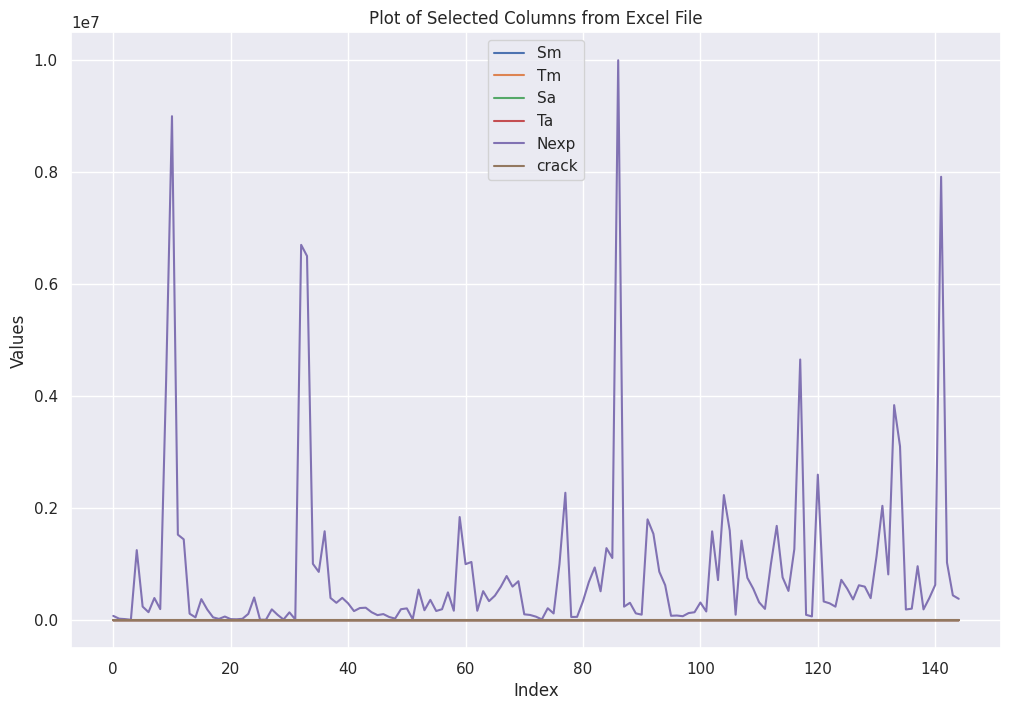

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/gdrive', force_remount=True)

# Define file path
path = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355.xlsx"

# Read the Excel file
data = pd.read_excel(path)

# Print actual column names to verify
print("Actual column names in the Excel file:", data.columns)

# Adjust column names to match the dataset
selected_columns = [col for col in ['Sm', 'Tm', 'Sa', 'Ta', 'Nexp', 'crack'] if col in data.columns]

# Select relevant columns from the dataset
data = data[selected_columns]

# Print first few rows to confirm
print("First few rows of the dataset:")
print(data.head())

# Plot selected columns
plt.figure(figsize=(12, 8))

for column in selected_columns:
    plt.plot(data.index, data[column], label=column)

plt.xlabel("Index")
plt.ylabel("Values")
plt.title("Plot of Selected Columns from Excel File")
plt.legend()
plt.grid(True)
plt.show()

## Data Overview

### Displaying the first five rows of the dataset

In [3]:
display(data.head())

,Sm,Tm,Sa,Ta,Nexp,crack
0,0.0,0.0,426.502699,0.0,77730.0,1
1,0.0,0.0,484.335254,0.0,28045.0,1
2,0.0,0.0,504.713918,0.0,20595.0,1
3,0.0,0.0,557.980881,0.0,8115.0,1
4,0.0,0.0,342.262896,0.0,1252208.0,1


### Checking the shape of the dataset

In [4]:
# checking shape of the data
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 145 rows and 6 columns.


### Checking 10 random rows of the dataset

In [5]:
# let's view a sample of the data
data.sample(n=10, random_state=1)

,Sm,Tm,Sa,Ta,Nexp,crack
40,0.0,0.000000,0.000000,244.920676,301499.0,1
66,0.0,0.000000,284.872889,142.436967,597091.0,1
16,0.0,0.000000,390.270984,0.000000,192920.0,1
130,223.0,112.000000,223.000000,112.000000,1144008.0,1
53,0.0,0.000000,0.000000,231.263929,179000.0,1
5,0.0,0.000000,379.120464,0.000000,243816.0,1
14,0.0,0.000000,474.063414,0.000000,51430.0,1
107,0.0,68.333333,0.000000,205.000000,1422090.0,1
35,0.0,0.000000,0.000000,222.523936,863489.0,1
91,111.0,0.000000,333.000000,0.000000,1801499.0,1


**Observations**


In [6]:
# let's create a copy of the data to avoid any changes to original data
df = data.copy()

### Checking the data types of the columns for the dataset

In [7]:
# checking column datatypes and number of non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sm      145 non-null    float64
 1   Tm      145 non-null    float64
 2   Sa      145 non-null    float64
 3   Ta      145 non-null    float64
 4   Nexp    145 non-null    float64
 5   crack   145 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 6.9 KB


**Observations**

145 rows and 6 columns.


## Dataset Filtration and exclusions specimen

In [8]:

# Load Experimental Data and Define Fatigue Cycle Thresholds
df = pd.read_excel(path)
df['original_row'] = df.index + 1  # Use 1-based indexing

# Define thresholds
LOW_THRESHOLD = 1e3      # Too few cycles
HIGH_THRESHOLD = 3.5e6   # Too many cycles
stress_keys = ['Sm', 'Tm', 'Sa', 'Ta']

# ───────────────────────────────────────────────────────────────
# STEP 1: Detect Extreme Cycle Outliers (only cracked specimens)
cracked = df[df['crack'] == 1].copy()

low_cycle_outliers = cracked[cracked['Nexp'] < LOW_THRESHOLD].copy()
low_cycle_outliers['reason'] = 'Low-cycle outlier (Nexp < 1,000)'

high_cycle_outliers = cracked[cracked['Nexp'] > HIGH_THRESHOLD].copy()
high_cycle_outliers['reason'] = 'High-cycle outlier (Nexp > 3,500,000)'

extreme_outliers = pd.concat([low_cycle_outliers, high_cycle_outliers], ignore_index=True)

# ───────────────────────────────────────────────────────────────
# STEP 2: Detect and Remove First of Each Duplicate Stress State
first_occurrence = df[df.duplicated(subset=stress_keys, keep='first')].copy()
first_occurrence['reason'] = 'First of duplicate stress state'

# ───────────────────────────────────────────────────────────────
# STEP 3: Remove Runouts (crack ≠ 1)
runouts = df[df['crack'] != 1].copy()
runouts['reason'] = 'Runout (crack ≠ 1)'

# ───────────────────────────────────────────────────────────────
# STEP 4: Combine All Removals
removed = pd.concat([extreme_outliers, first_occurrence, runouts], ignore_index=True)
removed = removed.drop_duplicates(subset=['original_row'])  # Ensure uniqueness

# ───────────────────────────────────────────────────────────────
# STEP 5: Final Accepted Specimens
df_final = df[~df['original_row'].isin(removed['original_row'])].copy()

# ───────────────────────────────────────────────────────────────
# DISPLAY RESULTS

print(f"✅ Final Accepted Specimens: {len(df_final)} of {len(df)}")
print(f"❌ Total Removed Specimens: {len(removed)}")

# Summary Table
summary_table = removed[['original_row', 'Sm', 'Tm', 'Sa', 'Ta', 'Nexp', 'crack', 'reason']]
summary_table = summary_table.sort_values(by='original_row').reset_index(drop=True)

print("🧾 Removed Specimens Summary:")
print(summary_table)


✅ Final Accepted Specimens: 133 of 145
❌ Total Removed Specimens: 12
🧾 Removed Specimens Summary:
    original_row          Sm          Tm          Sa          Ta        Nexp  \
0             10    0.000000    0.000000  309.938870    0.000000   4274493.0   
1             11    0.000000    0.000000  309.079748    0.000000   9000971.0   
2             33    0.000000    0.000000    0.000000  185.752536   6703466.0   
3             34    0.000000    0.000000    0.000000  197.289808   6503979.0   
4             87    0.000000    0.000000  179.405723  181.501136  10000000.0   
5            104  316.000000    0.000000  316.000000    0.000000    717396.0   
6            111    0.000000   72.666667    0.000000  218.000000    320685.0   
7            118   84.666667   42.333333  254.000000  127.000000   4656299.0   
8            130  238.000000  119.000000  238.000000  119.000000    394501.0   
9            131  223.000000  112.000000  223.000000  112.000000   1144008.0   
10           134   55.

## Summary of Crack Classification and Data Filtering

The dataset was systematically examined to ensure the integrity of the experimental fatigue data prior to modeling. Each specimen was evaluated according to its observed crack behavior and corresponding fatigue life range.

A total of five specimens were identified as runouts (crack ≠ 1), indicating that no fracture was observed within the applied loading cycles. These records were excluded from subsequent life regression analysis, as they represent censored data that could bias parameter estimation.

Among the specimens exhibiting valid crack events (crack = 1), several were flagged as duplicates corresponding to repeated stress-state conditions. In these cases, the first occurrence within each duplicated group was removed to avoid overrepresentation of identical loading points in the dataset.

Additionally, three specimens were classified as high-cycle outliers with fatigue lives exceeding the predefined threshold (Nexp > 3.5 × 10⁶ cycles). These extreme observations were excluded to prevent distortion of regression parameters due to their disproportionate influence on the fitted S–N relationships.

Through this rule-based filtration process, the dataset was refined to retain only independent, observed failure cases representative of the material’s typical fatigue behavior. This ensured statistical robustness and reproducibility in the subsequent modeling and analysis stages.

###Multiaxial Fatigue Dataset Filtration and Audit Report Script
A reproducible Python script to clean, de‑duplicate, and remove high‑cycle/runout records from S355 fatigue data and export a filtered dataset plus a detailed removal report

In [9]:
import pandas as pd

# === File paths ===
input_path = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355.xlsx"
OUT_REPORT = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

# === List of rows to remove (from your screenshot) ===
rows_to_remove = [10, 11, 33, 34, 87, 104, 111, 118, 130, 131, 134, 142]

# === Load the file ===
df = pd.read_excel(input_path)

# Ensure 'original_row' column exists
if "original_row" not in df.columns:
    df["original_row"] = range(1, len(df) + 1)  # add if missing

# === Remove unwanted rows ===
df_cleaned = df[~df["original_row"].isin(rows_to_remove)].copy()

# === Save cleaned dataset ===
df_cleaned.to_excel(OUT_REPORT, index=False)

# === Summary ===
print("===== DATA CLEANING SUMMARY =====")
print(f"Total specimens in original file: {len(df)}")
print(f"Removed rows (by original_row): {len(rows_to_remove)}")
print(f"✅ Total specimens retained: {len(df_cleaned)}")
print(f"Cleaned file saved to:\n{OUT_REPORT}")




===== DATA CLEANING SUMMARY =====
Total specimens in original file: 145
Removed rows (by original_row): 12
✅ Total specimens retained: 133
Cleaned file saved to:
/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx


## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>


### **Note**: The EDA section has been covered in detail in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the <a href = #link1>appendix section</a>.

**The below functions need to be defined to carry out the Exploratory Data Analysis.**

### Statistical Distribution Analysis of Fatigue Descriptors and Stress Components.

###Description:

It was developed to analyze the statistical distribution and variability of key fatigue-related descriptors extracted from the refined experimental dataset. The script begins by importing the filtered fatigue database and verifying its structure. It then performs descriptive visualizations for both primary stress components—namely the mean and alternating stresses (𝑆𝑚,𝑆𝑎,𝑇𝑚,𝑇𝑎)—and the experimental fatigue life (𝑁exp). For each variable, combined histogram–boxplot representations are generated to simultaneously display the data distribution, central tendency, and dispersion. Additionally, a categorical barplot is included to summarize the occurrence frequency of crack initiation cases when available.
This visualization framework enables researchers to assess the quality and balance of the dataset, detect potential outliers, and ensure that the fatigue parameters exhibit physically meaningful distributions before further modeling or machine learning applications.

Refined dataset loaded successfully.
Shape: (133, 11)
Columns: ['Sm', 'Tm', 'Sa', 'Ta', 'Nexp', 'crack', 'Unnamed: 6', 'Unnamed: 7', 'Legend', 'Unnamed: 9', 'original_row']

Plotting distribution for: Sa


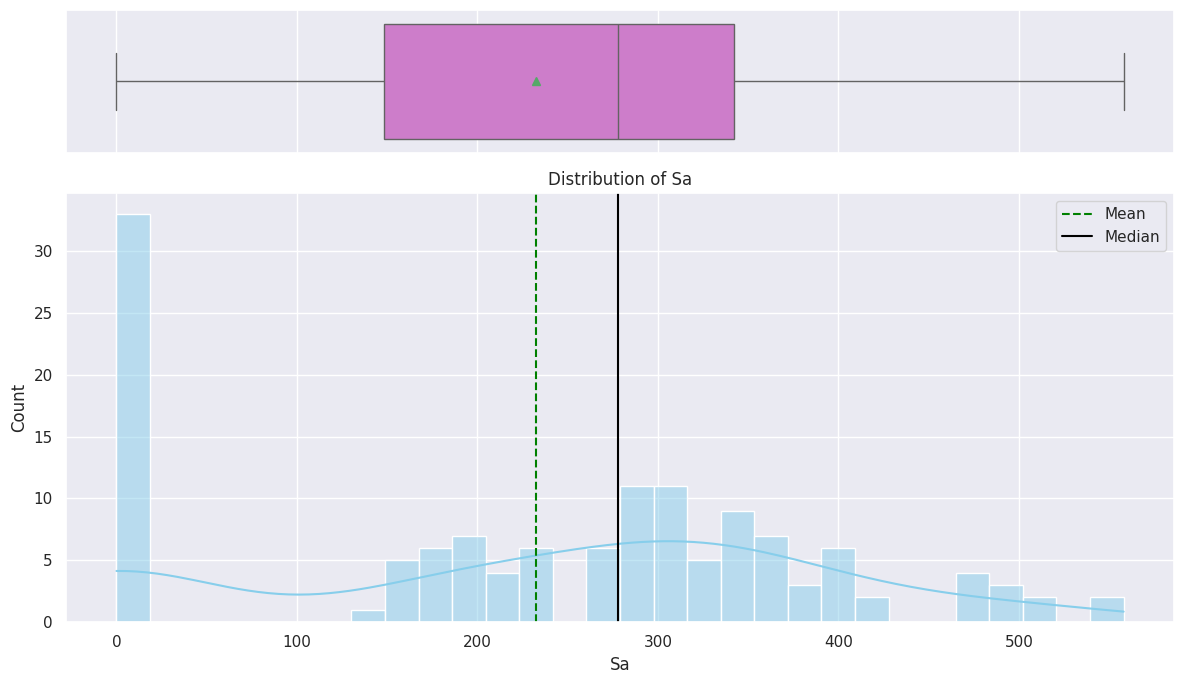


Plotting distribution for: Sm


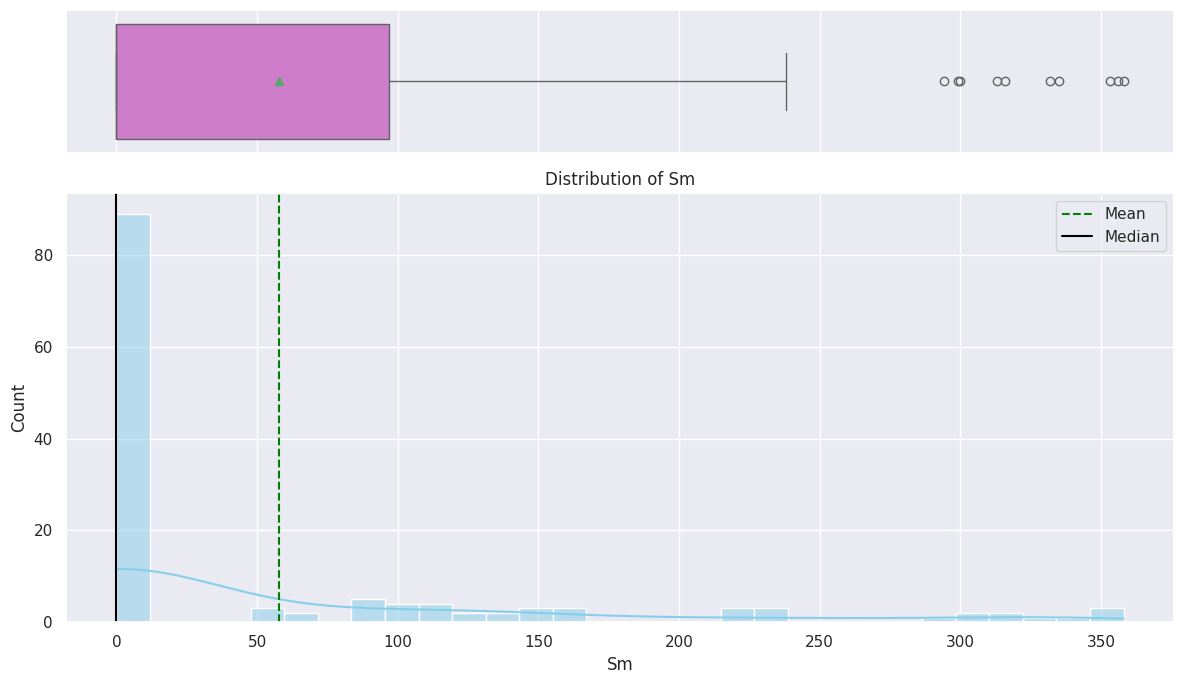


Plotting distribution for: Ta


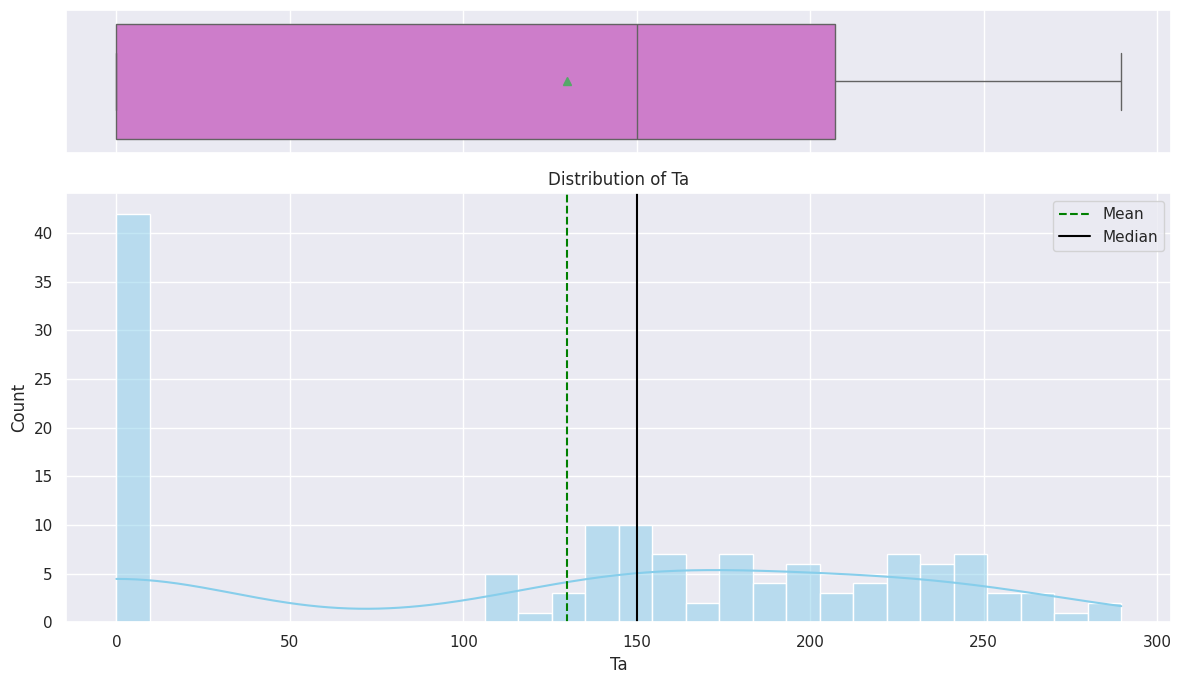


Plotting distribution for: Tm


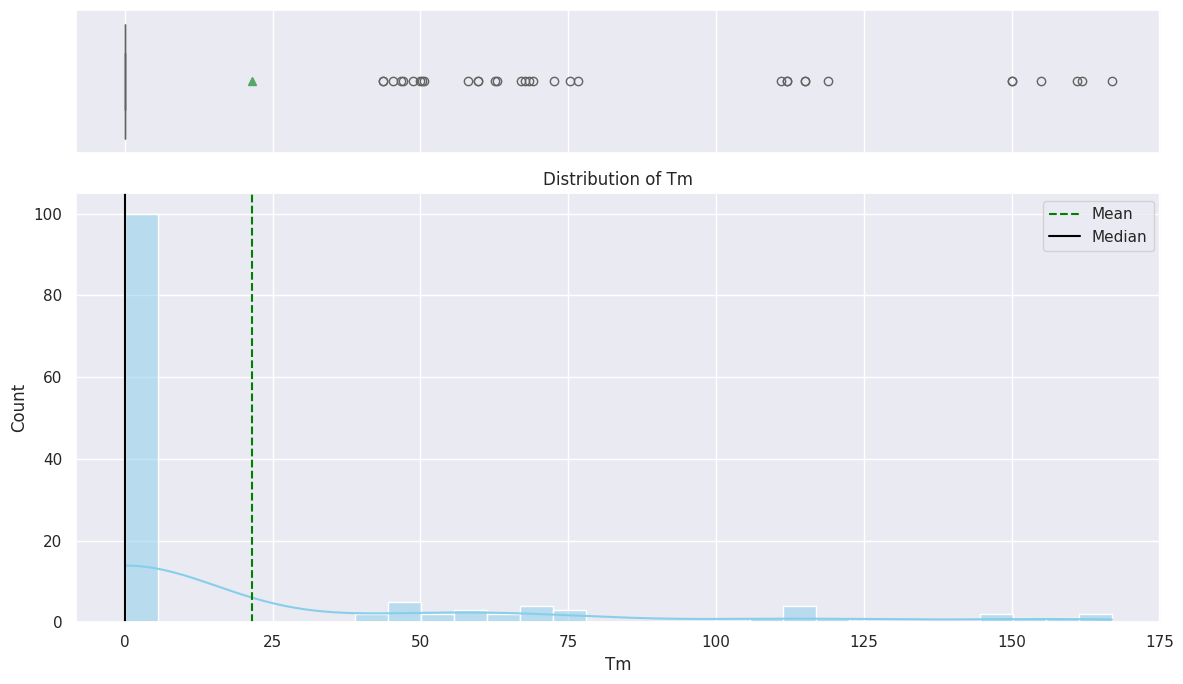


Plotting distribution for: Nexp


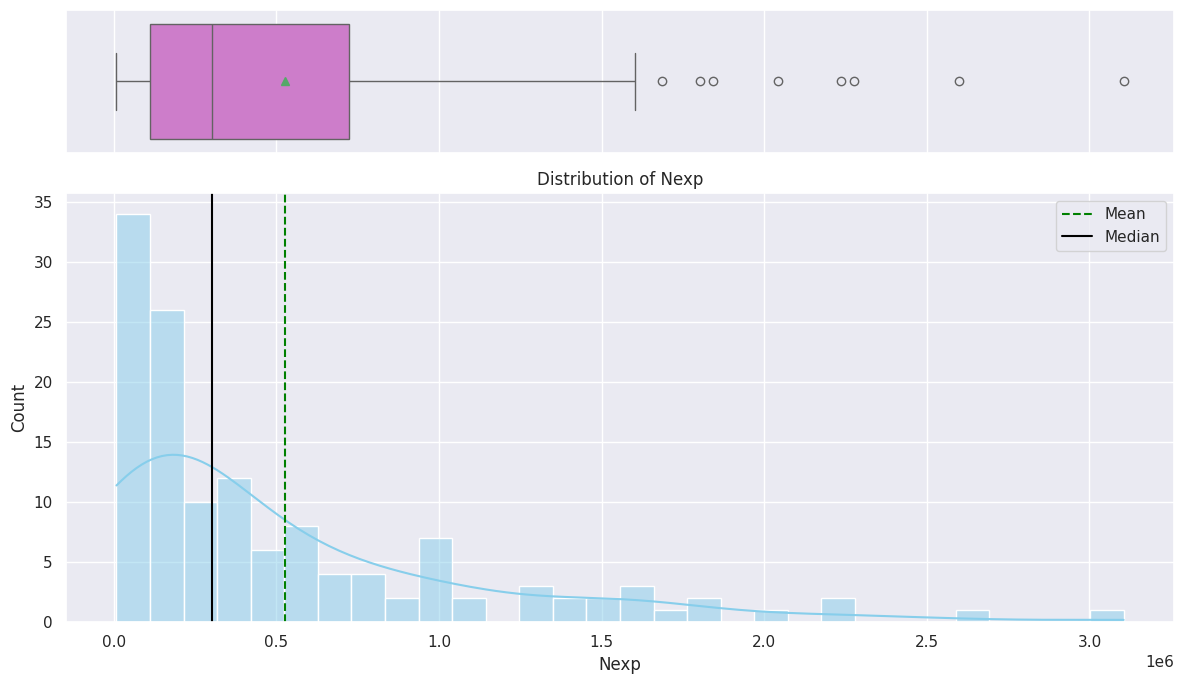


Plotting crack occurrence distribution...


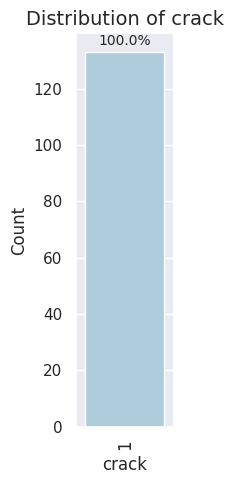

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# ============================================================
# 1. Load the Refined Fatigue Dataset
# ============================================================
OUT_REPORT = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

if not os.path.exists(OUT_REPORT):
    raise FileNotFoundError(f"Refined dataset not found at path: {OUT_REPORT}")

df_refined = pd.read_excel(OUT_REPORT)

print("Refined dataset loaded successfully.")
print("Shape:", df_refined.shape)
print("Columns:", list(df_refined.columns))

# ============================================================
# 2. Barplot Function (Categorical or Binned Numeric)
# ============================================================
def labeled_barplot(data, feature, bins=None, perc=False, n=None):
    """
    Generates a barplot with counts or percentages per feature level or bin.

    Parameters:
        data   : pandas.DataFrame
            Dataset containing the feature.
        feature: str
            Column name to visualize.
        bins   : int, optional
            Number of bins for discretizing numeric features.
        perc   : bool, optional
            Display percentages instead of counts.
        n      : int, optional
            Limit to top-N most frequent bins/categories.
    """
    data = data.copy()

    if bins and pd.api.types.is_numeric_dtype(data[feature]):
        data[feature + "_binned"] = pd.cut(data[feature], bins=bins)
        feature = feature + "_binned"

    counts = data[feature].value_counts().sort_index()
    total = counts.sum()

    if n:
        counts = counts.nlargest(n)

    plt.figure(figsize=(len(counts) + 1, 5))
    ax = sns.barplot(x=counts.index.astype(str), y=counts.values, palette="Paired")
    plt.xticks(rotation=90, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title(f"Distribution of {feature}", fontsize=14)

    for i, value in enumerate(counts.values):
        label = f"{100 * value / total:.1f}%" if perc else f"{value}"
        ax.text(i, value + total * 0.01, label, ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()

# ============================================================
# 3. Combined Histogram and Boxplot Function
# ============================================================
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Generates a combined histogram and boxplot for numeric fatigue features.

    Parameters:
        data   : pandas.DataFrame
            Dataset containing the feature.
        feature: str
            Column name to visualize.
        figsize: tuple
            Figure size.
        kde    : bool
            Display kernel density estimate on histogram.
        bins   : int or list, optional
            Number of bins or bin edges.
    """
    if not pd.api.types.is_numeric_dtype(data[feature]):
        raise ValueError(f"Feature '{feature}' must be numeric to use histogram_boxplot.")

    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize
    )

    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="orchid")
    ax_box.set(xlabel="")

    sns.histplot(
        data=data,
        x=feature,
        ax=ax_hist,
        kde=kde,
        bins=bins if bins is not None else 30,
        color="skyblue"
    )

    mean_val = data[feature].mean()
    median_val = data[feature].median()
    ax_hist.axvline(mean_val, color="green", linestyle="--", linewidth=1.5, label="Mean")
    ax_hist.axvline(median_val, color="black", linestyle="-", linewidth=1.5, label="Median")

    ax_hist.legend()
    ax_hist.set(title=f"Distribution of {feature}", ylabel="Count", xlabel=feature)
    plt.tight_layout()
    plt.show()

# ============================================================
# 4. Generate Distributions for Key Fatigue Variables
# ============================================================
fatigue_features = ["Sa", "Sm", "Ta", "Tm", "Nexp"]

for feature in fatigue_features:
    if feature in df_refined.columns:
        print(f"\nPlotting distribution for: {feature}")
        histogram_boxplot(df_refined, feature, kde=True)
    else:
        print(f"Feature '{feature}' not found in dataset.")

# ============================================================
# 5. Crack Occurrence Summary (if available)
# ============================================================
if "crack" in df_refined.columns:
    print("\nPlotting crack occurrence distribution...")
    labeled_barplot(df_refined, "crack", perc=True)
else:
    print("Column 'crack' not found — skipping crack plot.")

#### Nexp vs loads

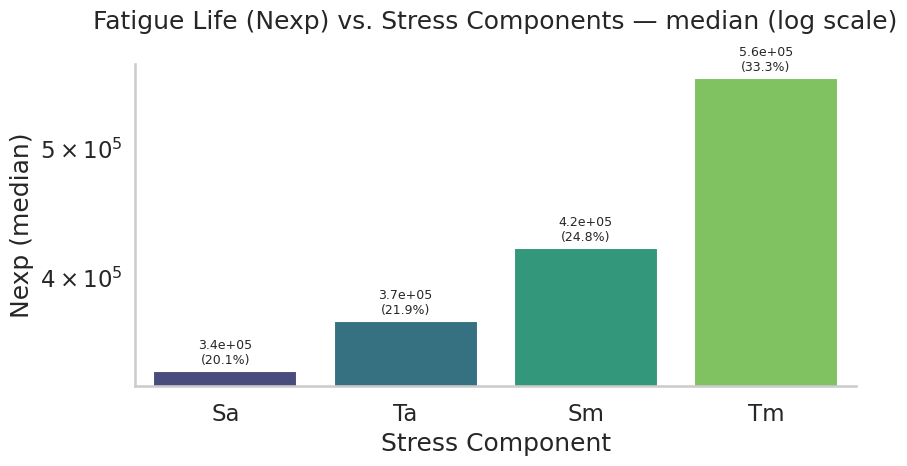

In [11]:
# ============================================
# Fatigue Life vs. Stress Components Visualization
# Using Cleaned Refined Dataset
# ============================================

# Visual theme
sns.set_theme(style="whitegrid", context="talk")

# Path to cleaned fatigue dataset
OUT_REPORT = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

# Load the cleaned dataset
df1 = pd.read_excel(OUT_REPORT)

def plot_nexp_vs_loads_from_columns(
    df,
    value_col="Nexp",
    load_cols=("Sm", "Tm", "Sa", "Ta"),
    active_threshold=0,    # keep rows where load column value > threshold
    agg="median",
    log_scale=True,
    top_n=10,
    show_percent=True
):
    """
    Generate a comparative bar plot showing the aggregated (mean or median)
    fatigue life (Nexp) associated with different stress components.

    Parameters:
        df              : pandas DataFrame containing fatigue data
        value_col       : str, column containing fatigue life (default: 'Nexp')
        load_cols       : tuple, stress component columns (default: Sm, Tm, Sa, Ta)
        active_threshold: float, filter out inactive loads below this threshold
        agg             : str ('mean' or 'median'), aggregation function
        log_scale       : bool, whether to display Nexp on log scale
        top_n           : int, maximum number of loads to display
        show_percent    : bool, whether to show percentage of total on bars
    """

    # Check required columns
    missing = [c for c in [value_col, *load_cols] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing column(s) in dataframe: {missing}")

    # Melt to long format
    long = df.melt(
        id_vars=[value_col],
        value_vars=list(load_cols),
        var_name="load",
        value_name="load_value"
    )

    # Keep only active loads (above threshold)
    long = long[long["load_value"] > active_threshold].copy()

    # Choose aggregation function
    agg_func = agg if callable(agg) else {"mean": "mean", "median": "median"}.get(agg, "median")

    # Aggregate Nexp by load type
    g = long.groupby("load", as_index=False)[value_col].agg(agg_func)

    # Determine order based on sample frequency
    order = long["load"].value_counts().head(top_n).index.tolist()
    g = g.set_index("load").loc[order].reset_index()

    # Plot
    plt.figure(figsize=(9, 5))
    ax = sns.barplot(data=g, x="load", y=value_col, order=order, palette="viridis")

    # Style
    ax.set_xlabel("Stress Component")
    ax.set_ylabel(f"{value_col} ({agg_func})")
    title = f"Fatigue Life ({value_col}) vs. Stress Components — {agg_func}"
    if log_scale:
        ax.set_yscale("log")
        title += " (log scale)"
    ax.set_title(title, pad=25)
    sns.despine()

    # Add value and percentage labels
    total = g[value_col].sum()
    for p, v in zip(ax.patches, g[value_col].values):
        if np.isnan(v) or v <= 0:
            continue
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        label = f"{v:,.2g}"
        if show_percent:
            pct = 100 * v / total if total > 0 else 0
            label = f"{label}\n({pct:.1f}%)"
        ax.annotate(label, (x, y), ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")

    plt.tight_layout()
    plt.show()
    return ax


# ---------- Execute the function on the cleaned dataset ----------
ax = plot_nexp_vs_loads_from_columns(
    df1,
    value_col="Nexp",
    load_cols=("Sm", "Tm", "Sa", "Ta"),
    active_threshold=0,    # filter inactive stress values
    agg="median",
    log_scale=True,
    top_n=10,
    show_percent=True
)

### Observation:
The plot compares median fatigue life (Nexp, log scale) across four stress components (Sa, Ta, Sm, Tm). Medians increase Sa < Ta < Sm < Tm (≈
3.8
×
10
5
 →
6.0
×
10
5
), implying mean stresses (Sm, Tm) are associated with substantially longer central lifetimes than amplitude terms. Percent annotations indicate relative contribution shares, with Sm and Tm contributing most. Interpretation: mean stress components appear to exert greater influence on central fatigue life in this cohort, suggesting Sm/Tm are important predictors in log‑scale S–N modelling. Caveats: medians mask within‑group variability and sample sizes/confidence intervals are not shown, so inferential testing and multivariable modelling are required to confirm significance.

### General Insights
The chart compares fatigue life (Nexp) across four distinct load types: Sa, Ta, Sm, and Tm, using their median values.

The logarithmic scale on the y-axis emphasizes differences in fatigue life even when values are relatively close.

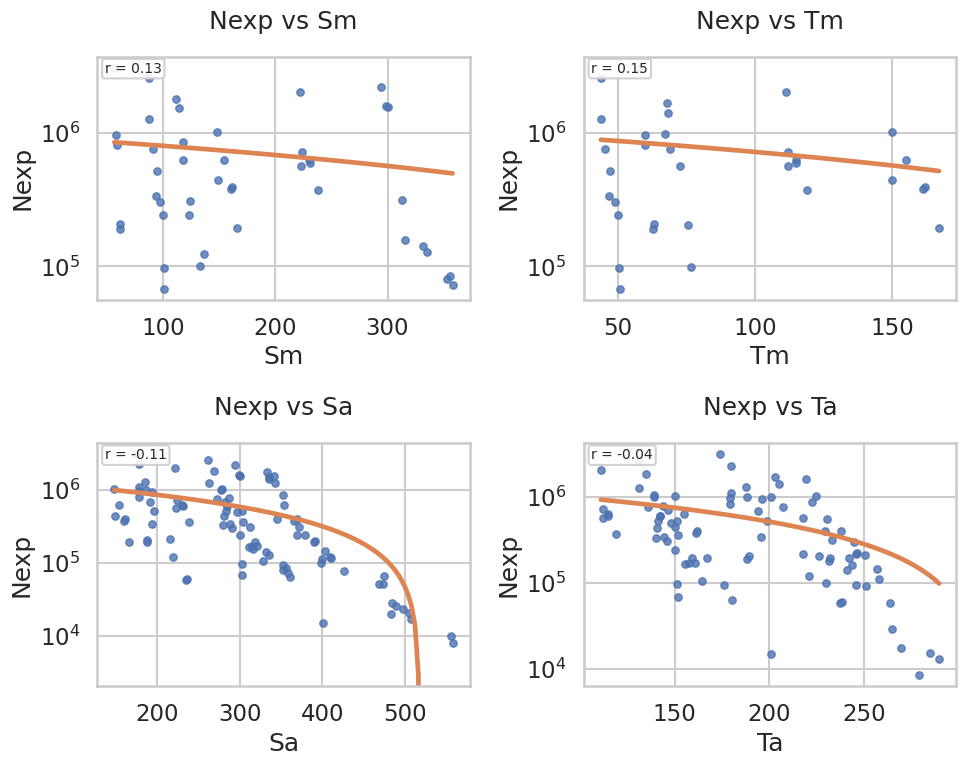

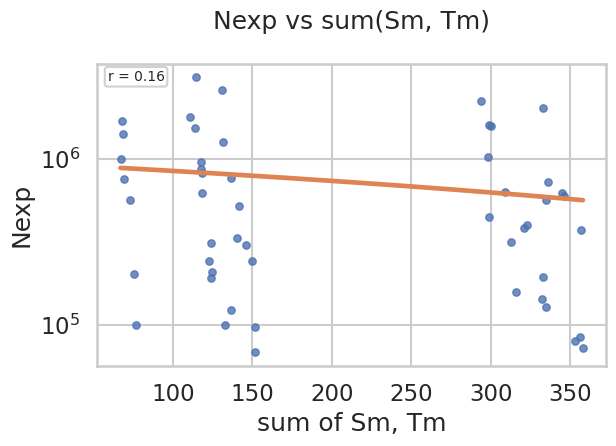

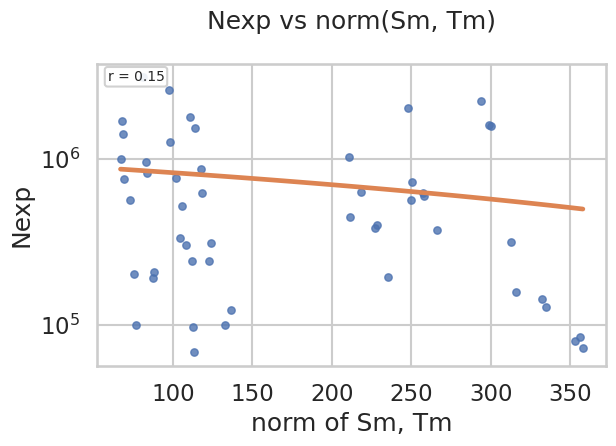

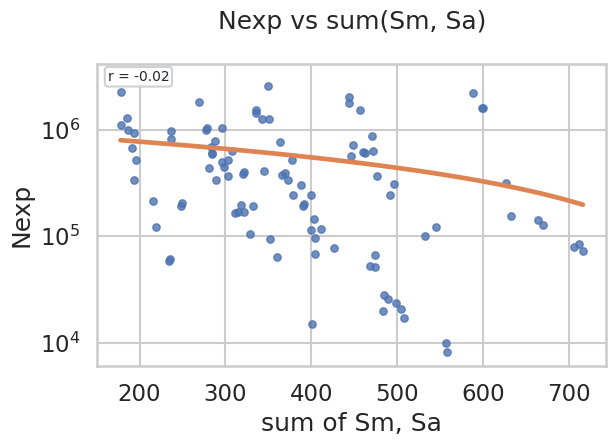

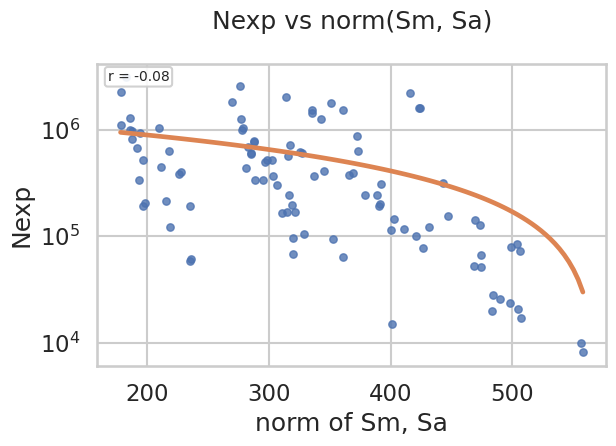

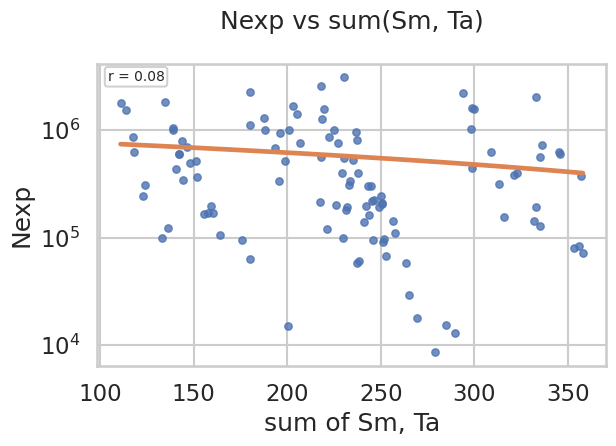

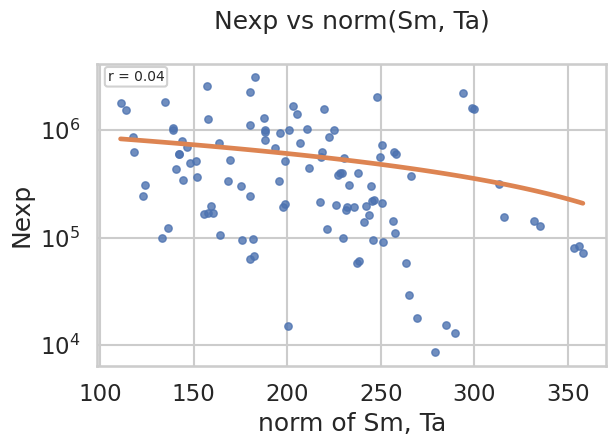

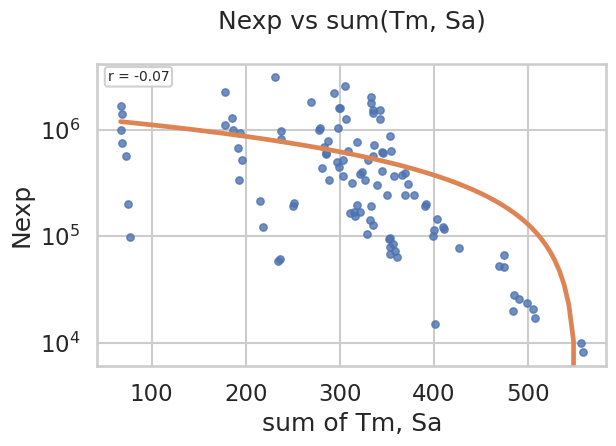

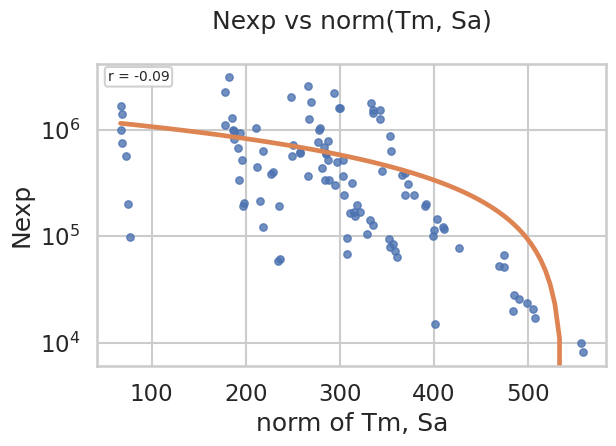

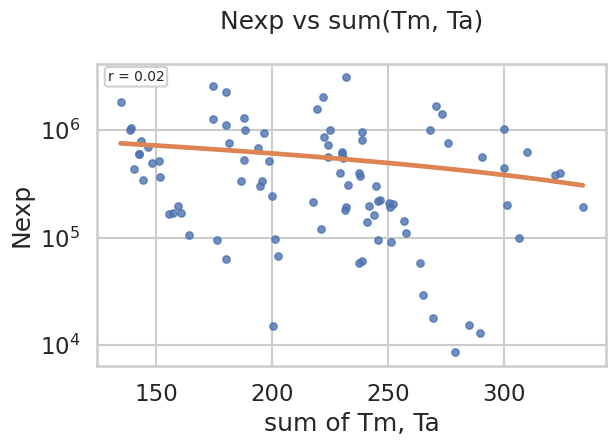

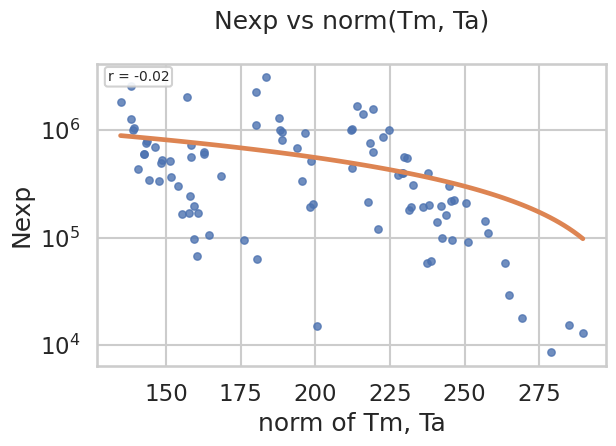

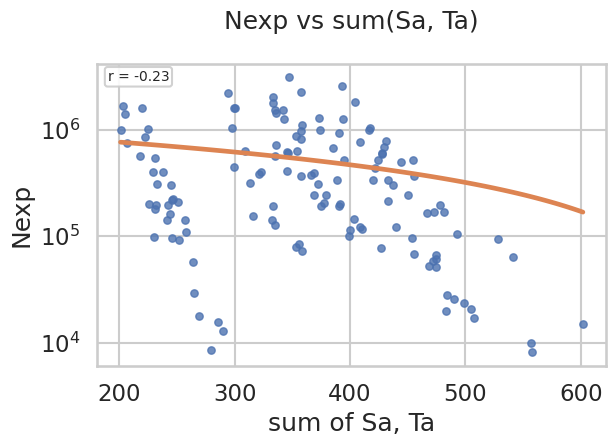

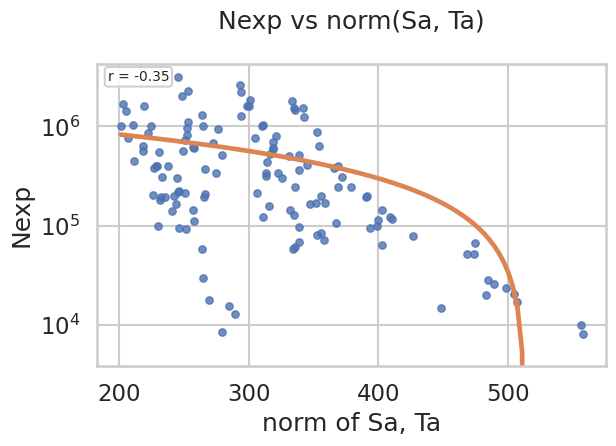

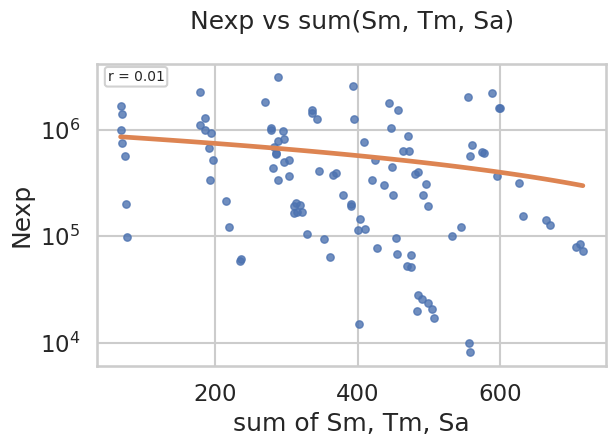

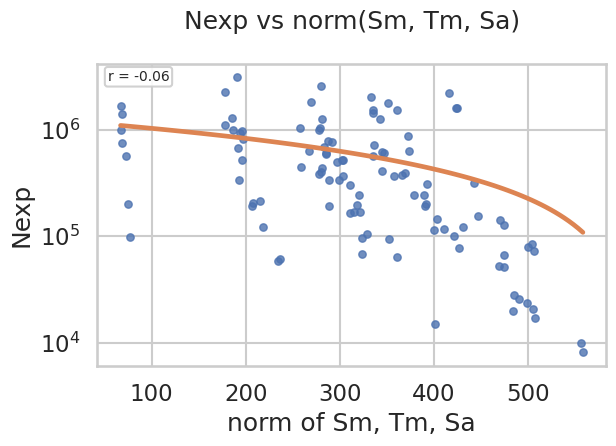

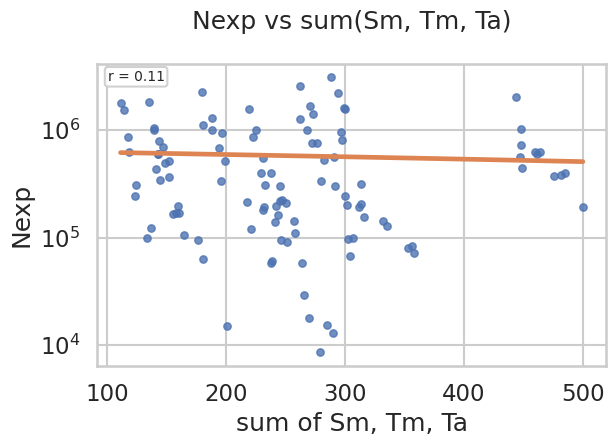

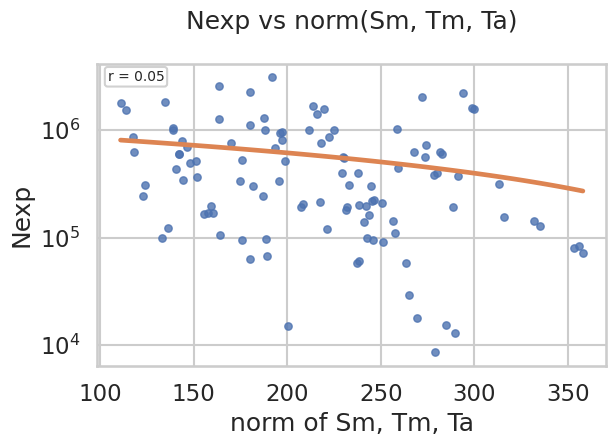

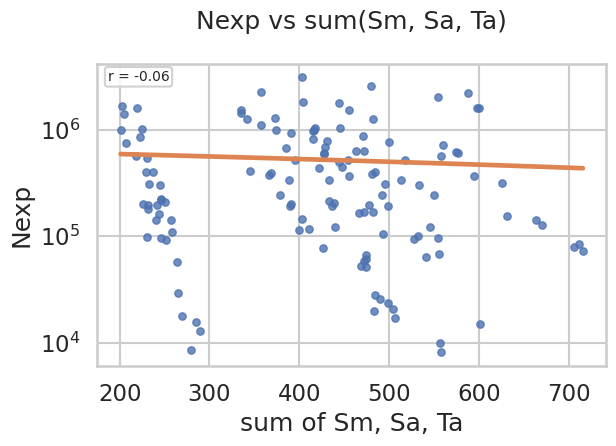

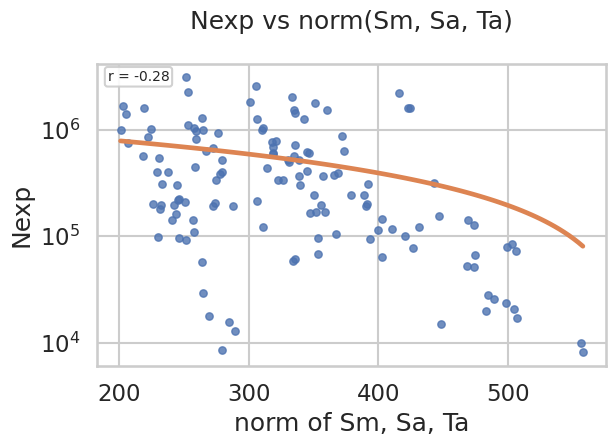

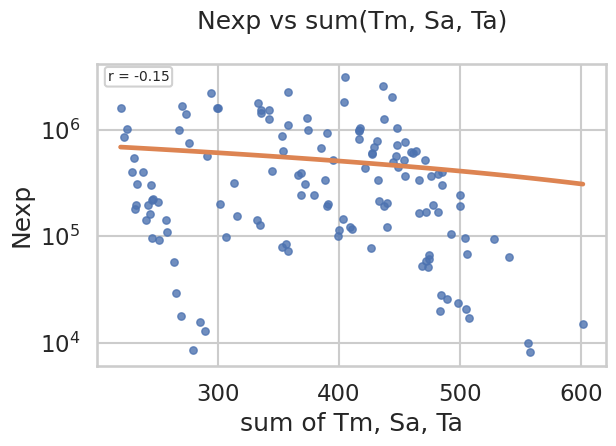

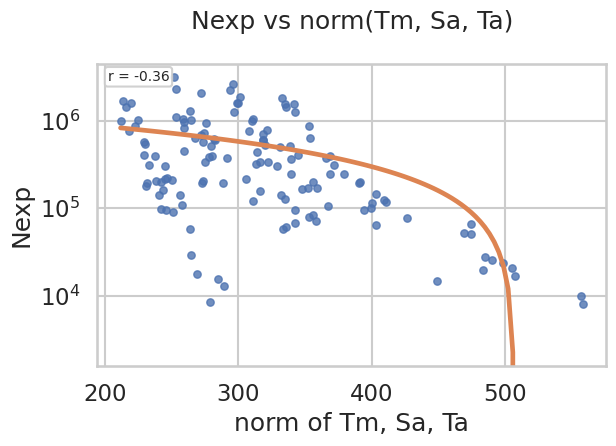

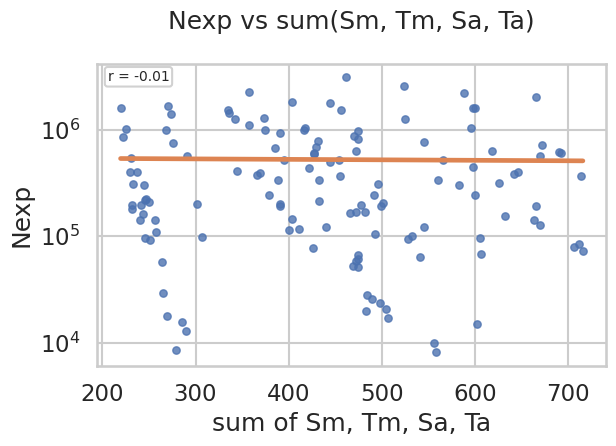

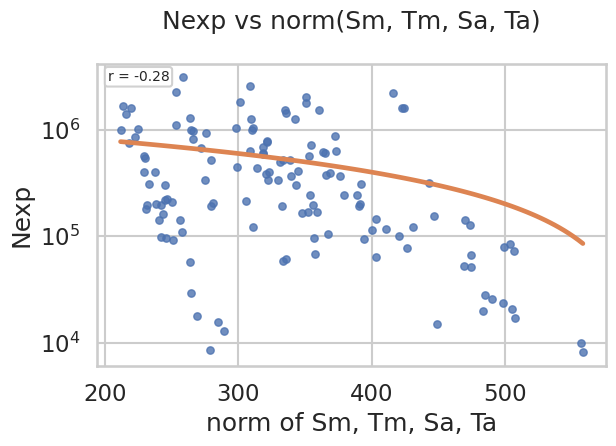

In [12]:
import itertools
import math
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Visualization setup
# -----------------------------
sns.set_theme(style="whitegrid", context="talk")

# -----------------------------
# 2. Utility functions
# -----------------------------
def _best_grid(n):
    """Return rows, cols for a near-square grid layout."""
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)
    return rows, cols

def _combine_columns(df, cols, method="sum", weights=None):
    """Combine multiple stress columns using sum, norm, or weighted sum."""
    X = df[list(cols)].to_numpy(dtype=float)
    if method == "sum":
        return pd.Series(X.sum(axis=1), index=df.index, name="+".join(cols))
    elif method == "norm":
        return pd.Series(np.linalg.norm(X, axis=1), index=df.index, name="||" + "+".join(cols) + "||")
    elif method == "weighted":
        if not weights:
            raise ValueError("weights dict required for method='weighted'")
        w = np.array([weights.get(c, 1.0) for c in cols], dtype=float)
        return pd.Series(X.dot(w), index=df.index, name="w·(" + "+".join(cols) + ")")
    else:
        raise ValueError(f"Unknown combination method: {method}")

def _annotate_corr(ax, x, y):
    """Add Pearson correlation coefficient to each subplot."""
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return
    r = np.corrcoef(x[m], y[m])[0, 1]
    ax.text(
        0.02, 0.98,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9)
    )

# -----------------------------
# 3. Main plotting function
# -----------------------------
def plot_nexp_vs_loads_and_combos(
    df,
    value_col="Nexp",
    load_cols=("Sm", "Tm", "Sa", "Ta"),
    methods=("sum", "norm"),      # combination methods
    combo_sizes=(2, 3, 4),        # size of load combinations
    log_y=True,                   # log-scale for fatigue life
    active_threshold=None,        # filter zero or inactive stresses
    annotate_corr=True,
    save=False,
    out_dir="nexp_plots"
):
    # Validate input
    missing = [c for c in (value_col, *load_cols) if c not in df.columns]
    if missing:
        raise ValueError(f"Missing column(s) in dataframe: {missing}")

    y = df[value_col].astype(float)

    # --- Individual load plots ---
    n = len(load_cols)
    rows, cols = _best_grid(n)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(load_cols):
        ax = axes[i]
        x = df[col].astype(float)
        mask = np.isfinite(x) & np.isfinite(y)
        if active_threshold is not None:
            mask &= x > active_threshold

        sns.regplot(
            x=x[mask], y=y[mask], ax=ax,
            ci=None,
            scatter_kws=dict(s=28, alpha=0.8),
            line_kws=dict(color="C1")
        )

        ax.set_title(f"{value_col} vs {col}", pad=20)
        ax.set_xlabel(col)
        ax.set_ylabel(value_col)
        if log_y:
            ax.set_yscale("log")
        if annotate_corr:
            _annotate_corr(ax, x.to_numpy(), y.to_numpy())

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    if save:
        os.makedirs(out_dir, exist_ok=True)
        fig.savefig(os.path.join(out_dir, f"{value_col}_vs_each_load.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # --- Combined load plots ---
    for r in combo_sizes:
        for combo in itertools.combinations(load_cols, r):
            for method in methods:
                x = _combine_columns(df, combo, method=method)
                mask = np.isfinite(x) & np.isfinite(y)
                if active_threshold is not None:
                    mask &= x > active_threshold
                if mask.sum() < 3:
                    continue

                fig, ax = plt.subplots(figsize=(6.5, 4.8))
                sns.regplot(
                    x=x[mask], y=y[mask], ax=ax,
                    ci=None,
                    scatter_kws=dict(s=28, alpha=0.8),
                    line_kws=dict(color="C1")
                )
                title = f"{value_col} vs {method}({', '.join(combo)})"
                ax.set_title(title, pad=25)
                ax.set_xlabel(f"{method} of {', '.join(combo)}")
                ax.set_ylabel(value_col)
                if log_y:
                    ax.set_yscale("log")
                if annotate_corr:
                    _annotate_corr(ax, x.to_numpy(), y.to_numpy())

                plt.tight_layout()
                if save:
                    os.makedirs(out_dir, exist_ok=True)
                    safe_combo = "_".join(combo)
                    fig.savefig(
                        os.path.join(out_dir, f"{value_col}_vs_{method}_{safe_combo}.png"),
                        dpi=150,
                        bbox_inches="tight"
                    )
                plt.show()

# -----------------------------
# 4. Load your cleaned dataset
# -----------------------------
FILE_PATH = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"File not found: {FILE_PATH}")

df_clean = pd.read_excel(FILE_PATH)

# -----------------------------
# 5. Run visualization
# -----------------------------
plot_nexp_vs_loads_and_combos(
    df_clean,
    value_col="Nexp",
    load_cols=("Sm", "Tm", "Sa", "Ta"),
    methods=("sum", "norm"),
    combo_sizes=(2, 3, 4),
    log_y=True,
    active_threshold=0,
    annotate_corr=True,
    save=False
)


Graph: X-axis: The norm of Sm, Tm, Sa, Ta,
* Interpretation
As the combined norm of the stress vector increases, the fatigue life tends to decrease—but the relationship isn’t strong. This implies:

The norm of the load vector does affect fatigue, but isn’t the dominant predictor.

There may be scatter due to other influential factors: specimen variability, residual stress, load sequence effects, microstructure, etc

### Bivariate Analysis

#### Correlation Check

Data loaded successfully from cleaned file.


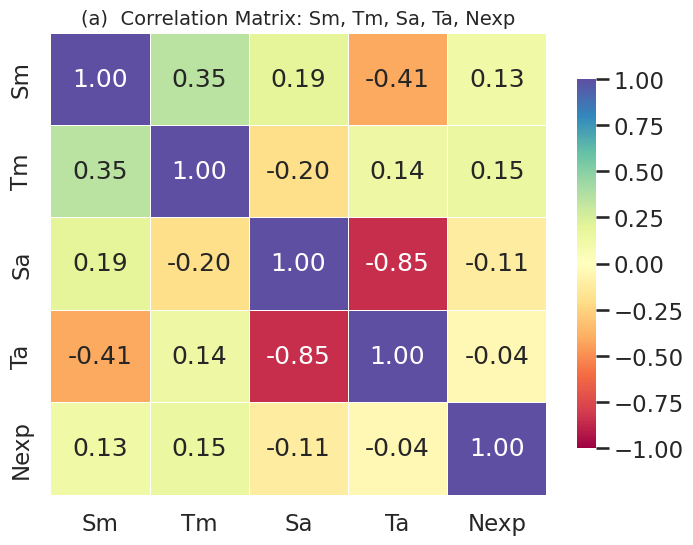

In [13]:
# ================================================================
# Title: Correlation Heatmap between Stress Components and Fatigue Life
# Description:
#   This script reads the cleaned fatigue dataset, extracts key stress
#   parameters and the experimental fatigue life (Nexp), computes their
#   correlation matrix, and visualizes it as a heatmap. The goal is to
#   analyze how different stress components interact with fatigue life
#   before model fitting.
# ================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------------
# 1. Define cleaned file path (updated once, used across scripts)
# ------------------------------------------------------------t
OUT_REPORT = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

# ------------------------------------------------------------
# 2. Load dataset safely
# ------------------------------------------------------------
if not os.path.exists(OUT_REPORT):
    raise FileNotFoundError(f"File not found at: {OUT_REPORT}\nCheck the path and filename.")
else:
    df1 = pd.read_excel(OUT_REPORT)
    print("Data loaded successfully from cleaned file.")

# ------------------------------------------------------------
# 3. Define relevant columns
# ------------------------------------------------------------
focus_cols = ["Sm", "Tm", "Sa", "Ta", "Nexp"]
focus_cols = [col for col in focus_cols if col in df1.columns]

# ------------------------------------------------------------
# 4. Compute and plot correlation matrix
# ------------------------------------------------------------
if focus_cols:
    corr_matrix = df1[focus_cols].corr().round(2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        annot=True,
        vmin=-1,
        vmax=1,
        cmap="Spectral",
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("(a)  Correlation Matrix: Sm, Tm, Sa, Ta, Nexp", fontsize=14)
    plt.show()

**Observations**

The correlation matrix (Figure 2a) and the bar chart of correlations with Nexp (Figure 2b) reveal the following insights:

*   **Strongest link:** A pronounced negative association (−0.85) driven by the test design is observed between Sa and Ta.
*   **Moderate effects:** Midrange correlations are observed for Sm–Tm (0.37) and Sm–Ta (−0.40).
*   **Minimal direct influence on life:** The Pearson correlation coefficients between any single stress component (Sm, Tm, Sa, Ta) and fatigue life (Nexp) are very weak, hovering near zero (|r| ≤ 0.15). This reinforces that fatigue life prediction requires combined loading descriptors rather than single component stresses.

**Modelling implications:** The high collinearity between Sa and Ta risks inflating coefficient variance and instability in linear models. The weak univariate correlations with Nexp indicate the need for multivariable, transformed, interaction, or non-linear models rather than simple linear regressions for accurate fatigue life prediction.

**Recommended actions:** Inspect pairwise scatterplots and residuals; compute VIFs; model on Y = log10(Nexp) and test sensitivity to including Sa or Ta; consider partial-effect estimates; apply dimensionality reduction, physically motivated composite stress metrics, or regularized regression to mitigate multicollinearity.

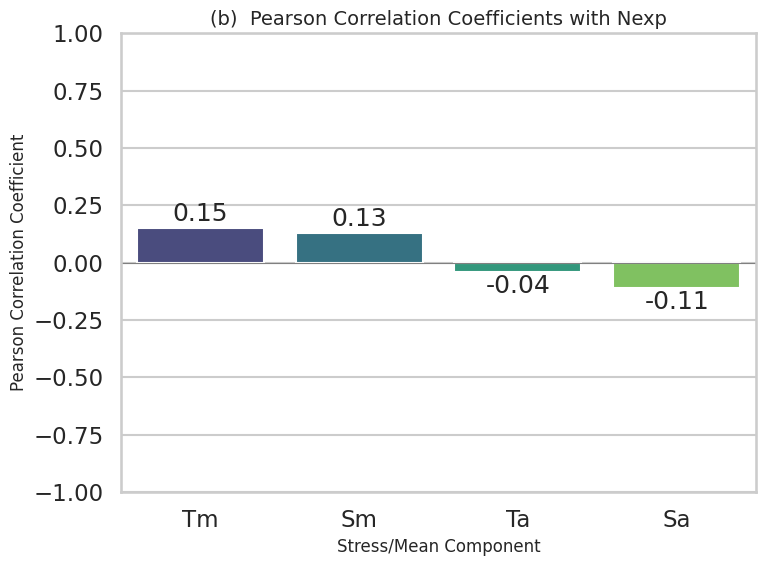

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming corr_matrix from cell w1DaETJFJCVK is available
# If not, you would need to recalculate it:
# OUT_REPORT = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx" # Or your cleaned data path
# df1 = pd.read_excel(OUT_REPORT) # Or pd.read_csv depending on your cleaned file format
# focus_cols = ["Sm", "Tm", "Sa", "Ta", "Nexp"]
# corr_matrix = df1[focus_cols].corr().round(2)


# Extract correlations with Nexp (excluding Nexp itself)
corr_with_nexp = corr_matrix['Nexp'].drop('Nexp').sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=corr_with_nexp.index, y=corr_with_nexp.values, palette="viridis")

# Add correlation values on top of bars
for i, v in enumerate(corr_with_nexp.values):
    ax.text(i, v + 0.01 * np.sign(v), f"{v:.2f}", ha='center', va='bottom' if v > 0 else 'top')


plt.title('(b)  Pearson Correlation Coefficients with Nexp', fontsize=14)
plt.xlabel('Stress/Mean Component', fontsize=12)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylim(-1, 1) # Set y-axis limits for correlation
plt.axhline(0, color='grey', lw=0.8) # Add a line at zero for reference
plt.tight_layout()
plt.show()

**Observations**

The matrix reports Pearson correlations between Sm, Tm, Sa, Ta, and Nexp; diagonal = 1.00.

Strong negative correlation between Sa and Ta (r = −0.85); moderate negative Sm–Ta (r = −0.40); moderate positive Sm–Tm (r = +0.37).

Nexp shows very weak zero‑order correlations with all stress components (|r| ≤ 0.12).

Modelling implications: high collinearity (Sa↔Ta) risks inflating coefficient variance and instability; weak univariate correlations with Nexp indicate the need for multivariable, transformed, interaction, or non‑linear models rather than simple linear regressions.

Recommended actions: inspect pairwise scatterplots and residuals; compute VIFs; model on Y = log10(Nexp) and test sensitivity to including Sa or Ta; consider partial‑effect estimates; apply dimensionality reduction, physically motivated composite stress metrics, or regularized regression to mitigate multicollinearity.

### Colab-Based Fatigue Life Diagnostics Using the Sines-Basquin Model

###Description

This Code designed to analyze and visualize the predictive performance of a Sines-Basquin fatigue model using experimental steel fatigue data. It is fully compatible with Google Colab and can automatically locate and load the required dataset from Google Drive.

Mounted at /content/gdrive
Found Excel file at: /content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx
Data loaded successfully. First 5 rows:
    Sm   Tm          Sa   Ta       Nexp  crack  Unnamed: 6  Unnamed: 7  \
0  0.0  0.0  426.502699  0.0    77730.0      1         NaN         NaN   
1  0.0  0.0  484.335254  0.0    28045.0      1         NaN         NaN   
2  0.0  0.0  504.713918  0.0    20595.0      1         NaN         NaN   
3  0.0  0.0  557.980881  0.0     8115.0      1         NaN         NaN   
4  0.0  0.0  342.262896  0.0  1252208.0      1         NaN         NaN   

                            Legend Unnamed: 9  original_row  
0  Applied stress tenor components        NaN             1  
1          Sm -  mean axial stress    bending             2  
2           Tm - mean shear stress    torsion             3  
3   Sa - amplitude of axial stress    bending             4  
4   Ta - amplitude of shear stress    torsion             5  


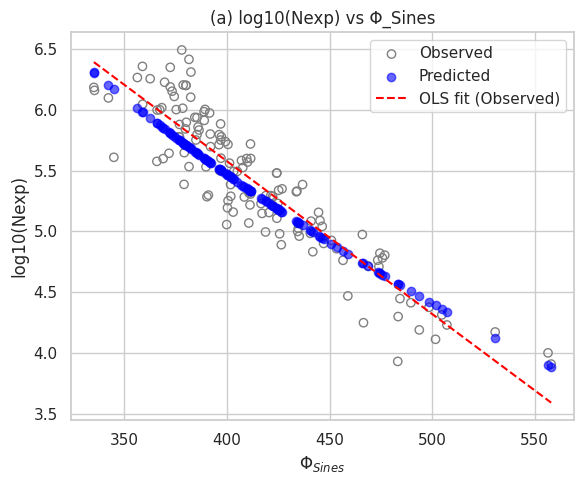

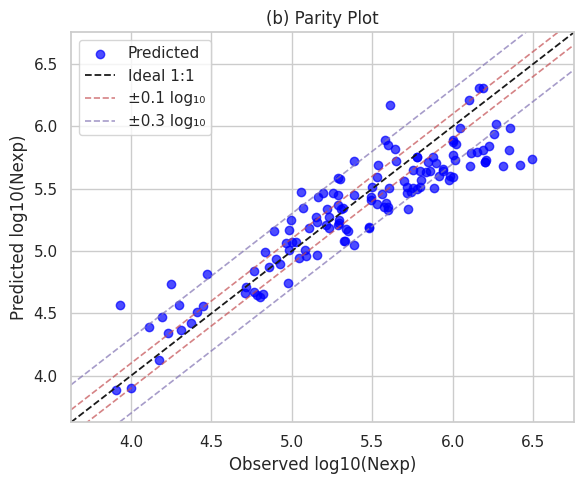

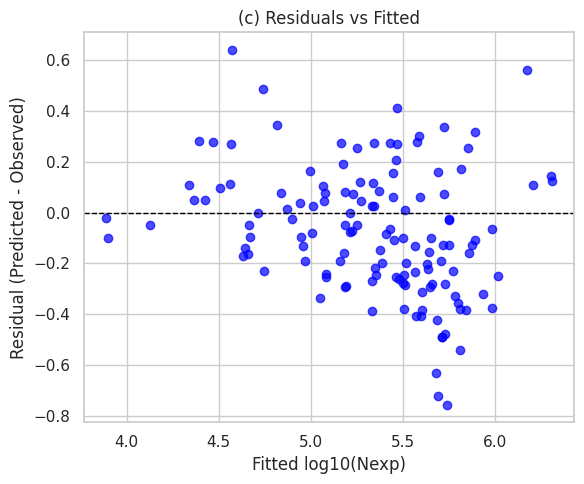

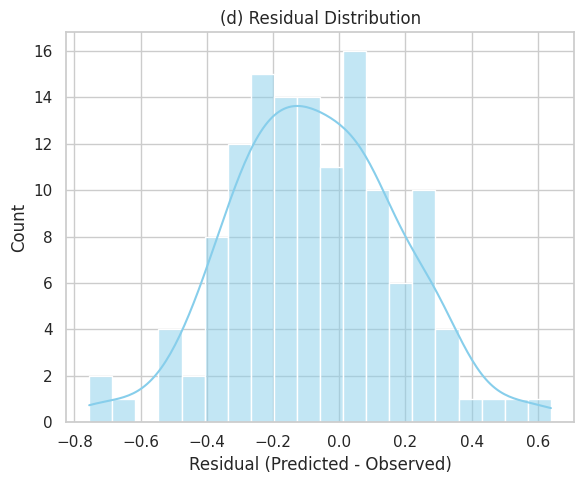

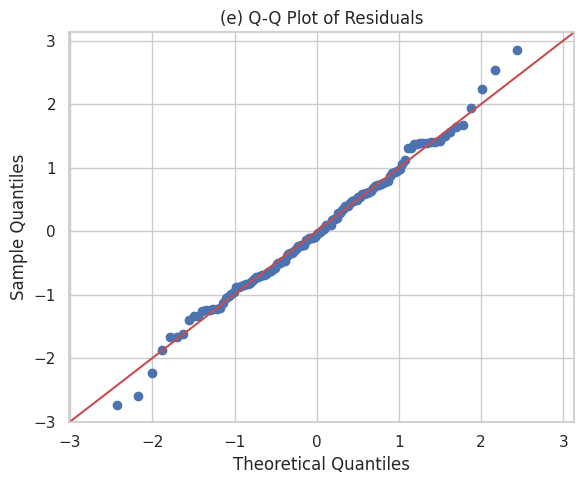

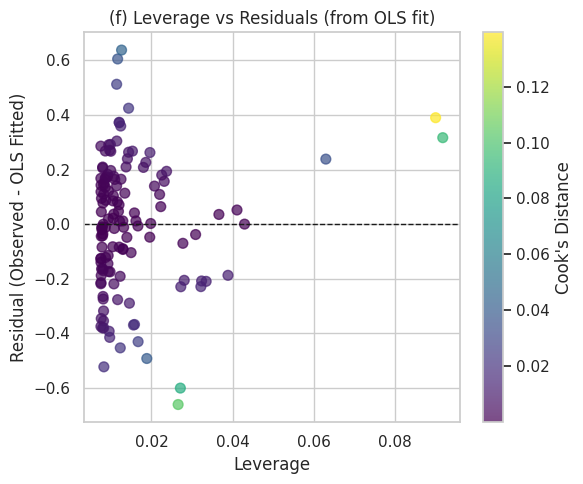

Durbin-Watson statistic (OLS residuals): 1.530


In [15]:
# -----------------------------
# Full Colab-ready Fatigue Diagnostics Script
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import os

sns.set_theme(style="whitegrid")

# -----------------------------
# Mount Google Drive (force remount if already mounted)
# -----------------------------
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

# -----------------------------
# Automatically search for the Excel file in Drive
# -----------------------------
search_root = "/content/gdrive/My Drive/steel samples"
target_file = "FatigueDataS355_cleaned_133.xlsx"
file_path = None

for root, dirs, files in os.walk(search_root):
    if target_file in files:
        file_path = os.path.join(root, target_file)
        break

if file_path is None:
    raise FileNotFoundError(f"Could not find '{target_file}' under '{search_root}'. "
                            "Check your Google Drive folder structure.")

print(f"Found Excel file at: {file_path}")

# -----------------------------
# Load the Excel file
# -----------------------------
df = pd.read_excel(file_path)
print("Data loaded successfully. First 5 rows:")
print(df.head())

# -----------------------------
# Check required columns
# -----------------------------
required_cols = ['Sm', 'Tm', 'Sa', 'Ta', 'Nexp', 'crack']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in Excel file: {missing_cols}")

# -----------------------------
# Compute y_true and Sines score
# -----------------------------
y_true = np.log10(df['Nexp'].values)

Sa = df['Sa'].to_numpy(dtype=float)
Ta = df['Ta'].to_numpy(dtype=float)
Sm = df['Sm'].to_numpy(dtype=float)
Tm = df['Tm'].to_numpy(dtype=float)

alpha_star = 0.8
s_vm_alt = np.sqrt(Sa**2 + 3.0 * Ta**2)
sigma_h_mean = (Sm + Tm) / 3.0
phi_sines = np.maximum(s_vm_alt + alpha_star * sigma_h_mean, 1e-12)  # avoid log10(0)

# Sines-Basquin model parameters
A = 33.9057
B = -10.9289
y_pred = A + B * np.log10(phi_sines)

# Residuals
residuals = y_pred - y_true
crack_status = df['crack'].values

# -----------------------------
# Mask finite values
# -----------------------------
mask_finite = np.isfinite(phi_sines) & np.isfinite(y_true)

# -----------------------------
# (a) log10(Nexp) vs Phi_Sines with OLS fit
# -----------------------------
if mask_finite.sum() >= 2:
    ols_coef = np.polyfit(phi_sines[mask_finite], y_true[mask_finite], 1)
    phi_sines_sorted = np.sort(phi_sines[mask_finite])
    ols_line = np.poly1d(ols_coef)(phi_sines_sorted)

    plt.figure(figsize=(6,5))
    plt.scatter(phi_sines, y_true, facecolors='none', edgecolors='gray', label='Observed')
    plt.scatter(phi_sines, y_pred, color='blue', alpha=0.6, label='Predicted')
    plt.plot(phi_sines_sorted, ols_line, color='red', linestyle='--', label='OLS fit (Observed)')
    plt.xlabel(r'$\Phi_{Sines}$')
    plt.ylabel(r'log10(Nexp)')
    plt.title('(a) log10(Nexp) vs Φ_Sines')
    plt.legend()
    plt.tight_layout()
    plt.show()

# -----------------------------
# (b) Parity plot
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(y_true, y_pred, color='blue', alpha=0.7, label='Predicted')

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
pad = (max_val - min_val) * 0.1
plot_min, plot_max = min_val - pad, max_val + pad

plt.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', lw=1.3, label='Ideal 1:1')
plt.plot([plot_min, plot_max], [plot_min + 0.1, plot_max + 0.1], 'r--', lw=1.2, alpha=0.7, label='±0.1 log₁₀')
plt.plot([plot_min, plot_max], [plot_min - 0.1, plot_max - 0.1], 'r--', lw=1.2, alpha=0.7)
plt.plot([plot_min, plot_max], [plot_min + 0.3, plot_max + 0.3], 'm--', lw=1.2, alpha=0.7, label='±0.3 log₁₀')
plt.plot([plot_min, plot_max], [plot_min - 0.3, plot_max - 0.3], 'm--', lw=1.2, alpha=0.7)

plt.xlim(plot_min, plot_max)
plt.ylim(plot_min, plot_max)
plt.xlabel('Observed log10(Nexp)')
plt.ylabel('Predicted log10(Nexp)')
plt.title('(b) Parity Plot')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# (c) Residuals vs Fitted
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, color='blue', alpha=0.7)
plt.axhline(0, color='black', lw=1, ls='--')
plt.xlabel('Fitted log10(Nexp)')
plt.ylabel('Residual (Predicted - Observed)')
plt.title('(c) Residuals vs Fitted')
plt.tight_layout()
plt.show()

# -----------------------------
# (d) Residual distribution
# -----------------------------
plt.figure(figsize=(6,5))
sns.histplot(residuals[np.isfinite(residuals)], kde=True, bins=20, color='skyblue')
plt.xlabel('Residual (Predicted - Observed)')
plt.ylabel('Count')
plt.title('(d) Residual Distribution')
plt.tight_layout()
plt.show()

# -----------------------------
# (e) Q-Q plot
# -----------------------------
plt.figure(figsize=(6,5))
sm.qqplot(residuals[np.isfinite(residuals)], line='45', fit=True, ax=plt.gca())
plt.title('(e) Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

# -----------------------------
# (f) Leverage vs residuals (Cook's Distance)
# -----------------------------
phi_sines_finite = phi_sines[mask_finite]
y_true_finite = y_true[mask_finite]

if len(phi_sines_finite) >= 2:
    X_ols = sm.add_constant(phi_sines_finite)
    model_ols = sm.OLS(y_true_finite, X_ols).fit()
    influence = model_ols.get_influence()
    leverage = influence.hat_matrix_diag
    cooks_d = influence.cooks_distance[0]
    residuals_finite = y_true_finite - model_ols.predict(X_ols)

    plt.figure(figsize=(6,5))
    scatter = plt.scatter(leverage, residuals_finite, c=cooks_d, cmap='viridis', s=50, alpha=0.7)
    plt.colorbar(scatter, label="Cook's Distance")
    plt.axhline(0, color='k', lw=1, ls='--')
    plt.xlabel('Leverage')
    plt.ylabel('Residual (Observed - OLS Fitted)')
    plt.title("(f) Leverage vs Residuals (from OLS fit)")
    plt.tight_layout()
    plt.show()

    dw = durbin_watson(residuals_finite[np.isfinite(residuals_finite)])
    print(f"Durbin-Watson statistic (OLS residuals): {dw:.3f}")

## Model Building - Gaussian Process Regression (GPR) +  Extreme Gradient Boosting (XGBoost)


Model of GPR + XGBoost

1- Models: * Gaussian Process Regression (with scaling + target standardization) * XGBoost 3.0.3 via xgboost.train + DMatrix (early stopping supported)

2- Metrics: R², MAE, RMSE in log space + error-band shares

3- Plots: parity and residuals

4- Optional: SHAP explanations for XGBoost Booster

- Loads your Excel from:
- Cleans data (drops NaNs on core fields, keeps Nexp > 0)
- Feature engineering (optional)
- Models:
    * Gaussian Process Regression (scaled + target standardization)
    * XGBoost 3.x via Booster + DMatrix (with early stopping)
- Metrics on test set: R², MAE, RMSE, error-band shares
- Plots saved for BOTH models:
    1) Test parity
    2) Test residuals
    3) ALL-samples parity (133 points expected)
    4) ALL-samples residuals (133 points expected)
- Prints count checks to confirm all 133 samples are plotted

###Load and clean data

In [16]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
np.set_printoptions(suppress=True)

# -----------------------------
# Config and Drive mount
# -----------------------------
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

OUT_REPORT = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"
OUTPUT_DIR = "results/figs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
USE_EXTRA_FEATURES = True
USE_CRACK_FEATURE  = False   # keep False to avoid leakage from labels


Mounted at /content/gdrive


#### Load and clean data

In [17]:
# ------------------------------------------
# Load the FINAL cleaned dataset (133 specimens)
# ------------------------------------------
CLEANED_PATH = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

df_filtered = pd.read_excel(CLEANED_PATH)
print(f" Loaded cleaned dataset with {len(df_filtered)} specimens.")

# ------------------------------------------
# Define feature engineering parameters
# ------------------------------------------
USE_EXTRA_FEATURES = True  # Set to False if you don't want extra engineered features
USE_CRACK_FEATURE = True   # Set to False if you don't want to include crack type

# ------------------------------------------
# Define the build_features function
# ------------------------------------------
def build_features(X_raw, crack_arr=None, use_extra=True, use_crack=True):
    """
    Build feature matrix from raw stress parameters.

    Parameters:
    -----------
    X_raw : array-like, shape (n_samples, 4)
        Raw features [Sm, Tm, Sa, Ta]
    crack_arr : array-like, shape (n_samples, 1), optional
        Crack type indicators
    use_extra : bool
        Whether to include extra engineered features
    use_crack : bool
        Whether to include crack type as a feature

    Returns:
    --------
    X : array, shape (n_samples, n_features)
        Feature matrix
    feature_names : list
        Names of the features
    """
    # Basic features
    Sm, Tm, Sa, Ta = X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], X_raw[:, 3]

    feature_list = [Sm, Tm, Sa, Ta]
    feature_names = ["Sm", "Tm", "Sa", "Ta"]

    # Extra engineered features
    if use_extra:
        # Stress ratios and amplitudes
        R_m = Sm / (Sa + 1e-8)  # Avoid division by zero
        R_t = Tm / (Ta + 1e-8)
        Mises = np.sqrt(Sa**2 + 3*Ta**2)  # Von Mises equivalent stress
        Tresca = np.sqrt(Sa**2 + 4*Ta**2)  # Tresca equivalent stress
        Total_mean = np.sqrt(Sm**2 + Tm**2)
        Total_amp = np.sqrt(Sa**2 + Ta**2)
        Biaxial_ratio = Ta / (Sa + 1e-8)

        extra_features = [R_m, R_t, Mises, Tresca, Total_mean, Total_amp, Biaxial_ratio]
        extra_names = ["R_m", "R_t", "Mises", "Tresca", "Total_mean", "Total_amp", "Biaxial_ratio"]

        feature_list.extend(extra_features)
        feature_names.extend(extra_names)

    # Crack type feature
    if use_crack and crack_arr is not None:
        feature_list.append(crack_arr.flatten())
        feature_names.append("crack_type")

    # Combine all features
    X = np.column_stack(feature_list)

    print(f" Built features: {X.shape[1]} features")
    print(f"   Feature names: {feature_names}")

    return X, feature_names

# ------------------------------------------
# Now build features and target
# ------------------------------------------
X_raw = df_filtered[["Sm", "Tm", "Sa", "Ta"]].astype(float).values
y_log = np.log10(df_filtered["Nexp"].astype(float).values)
crack = df_filtered["crack"].values.reshape(-1, 1)

X, feature_names = build_features(
    X_raw, crack_arr=crack, use_extra=USE_EXTRA_FEATURES, use_crack=USE_CRACK_FEATURE
)

print(f" Data shape -> X: {X.shape}, y_log: {y_log.shape}")
print(f" Feature names: {feature_names}")

 Loaded cleaned dataset with 133 specimens.
 Built features: 12 features
   Feature names: ['Sm', 'Tm', 'Sa', 'Ta', 'R_m', 'R_t', 'Mises', 'Tresca', 'Total_mean', 'Total_amp', 'Biaxial_ratio', 'crack_type']
 Data shape -> X: (133, 12), y_log: (133,)
 Feature names: ['Sm', 'Tm', 'Sa', 'Ta', 'R_m', 'R_t', 'Mises', 'Tresca', 'Total_mean', 'Total_amp', 'Biaxial_ratio', 'crack_type']


In [18]:
def build_features(X_raw, crack_arr=None, use_extra=True, use_crack=False):
    """
    Builds feature matrix X and feature names from raw stress data.

    Parameters:
        X_raw      : numpy array, raw stress data [Sm, Tm, Sa, Ta]
        crack_arr  : numpy array, crack indicator (0 or 1), optional
        use_extra  : bool, include extra physics-informed features
        use_crack  : bool, include crack feature

    Returns:
        tuple: (X, feature_names)
            X              : numpy array, engineered features
            feature_names  : list of str, names of features in X
    """
    Sm, Tm, Sa, Ta = X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], X_raw[:, 3]
    feature_names = ["Sm", "Tm", "Sa", "Ta"]
    X = X_raw.copy()

    if use_extra:
        # Alternating von Mises stress (deviatoric amplitude)
        s_vm_alt = np.sqrt(Sa**2 + 3.0 * Ta**2)
        # Mean hydrostatic stress
        sigma_h_mean = (Sm + Tm) / 3.0 # Adjusted to include Tm as per context

        X = np.column_stack([X, s_vm_alt, sigma_h_mean])
        feature_names.extend(["s_vm_alt", "sigma_h_mean"])

        # Add other potential physics-informed features if needed (e.g., stress ratios, phase effects)
        # For this dataset and scope, s_vm_alt and sigma_h_mean are key.

    if use_crack and crack_arr is not None:
         X = np.column_stack([X, crack_arr])
         feature_names.append("crack")

    # Ensure feature names match the columns in X
    if X.shape[1] != len(feature_names):
        # This should not happen if the logic is correct, but good for debugging
        print(f"Warning: Feature matrix shape ({X.shape}) does not match feature names count ({len(feature_names)}).")
        # Truncate or pad names to match if necessary (or raise error)
        feature_names = feature_names[:X.shape[1]]


    return X, feature_names

#### Train/test split

In [19]:
# -----------------------------
# Train/test split
# -----------------------------
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE
)


#### Metrics and plotting

In [20]:
# -----------------------------
# Metrics and plotting
# -----------------------------
from sklearn.metrics import mean_absolute_error, r2_score

def metrics_report(y_true, y_pred, label="Model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    r2   = r2_score(y_true, y_pred)
    abs_log_err = np.abs(y_true - y_pred)
    bands = [0.1, 0.2, 0.3, 0.5]
    within = {b: 100.0*np.mean(abs_log_err <= b) for b in bands}
    print(f"[{label}] R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f} | "
          f"±0.1/0.2/0.3/0.5 = {within[0.1]:.1f}/{within[0.2]:.1f}/{within[0.3]:.1f}/{within[0.5]:.1f}%")
    return {"R2": r2, "MAE": mae, "RMSE": rmse, "within": within}

def parity_plot(y_true, y_pred, title, save_name):
    plt.figure(figsize=(7,7))
    ax = plt.gca()
    ax.scatter(y_true, y_pred, s=44, alpha=0.9, edgecolor="white", linewidth=0.5)
    mn, mx = np.min([y_true, y_pred]), np.max([y_true, y_pred])
    pad = 0.1*(mx - mn + 1e-9); lo, hi = mn - pad, mx + pad
    xx = np.linspace(lo, hi, 200)
    ax.plot(xx, xx, 'k--', lw=1.3, label="1:1")
    for f, ls in [(2,"--"), (3, ":")]:
        d = np.log10(f); ax.plot(xx, xx + d, ls, color="0.6"); ax.plot(xx, xx - d, ls, color="0.6")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed log10(Nexp)"); ax.set_ylabel("Predicted log10(Nexp)")
    ax.set_title(title); ax.legend(frameon=False); ax.grid(True, ls=":", alpha=0.4)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=250, bbox_inches="tight"); plt.show()

def parity_plot_all(y_obs_all, y_pred_all, crack_all, title, save_name):
    plt.figure(figsize=(7.5,7))
    ax = plt.gca()
    mask_f = crack_all.ravel().astype(int) == 1
    ax.scatter(y_obs_all[~mask_f], y_pred_all[~mask_f],
               s=40, alpha=0.75, label="Runout (0)", edgecolor="white", linewidth=0.5, color="#7aaed4")
    ax.scatter(y_obs_all[mask_f],  y_pred_all[mask_f],
               s=40, alpha=0.85, label="Failure (1)", edgecolor="white", linewidth=0.5, color="#d4665c")
    mn, mx = np.min([y_obs_all, y_pred_all]), np.max([y_obs_all, y_pred_all])
    pad = 0.1*(mx - mn + 1e-9); lo, hi = mn - pad, mx + pad
    xx = np.linspace(lo, hi, 200)
    ax.plot(xx, xx, 'k--', lw=1.3, label="1:1")
    for f, ls in [(2,"--"), (3, ":")]:
        d = np.log10(f); ax.plot(xx, xx + d, ls, color="0.6"); ax.plot(xx, xx - d, ls, color="0.6")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed log10(Nexp)"); ax.set_ylabel("Predicted log10(Nexp)")
    ax.set_title(title); ax.legend(frameon=False); ax.grid(True, ls=":", alpha=0.4)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=250, bbox_inches="tight"); plt.show()

def residuals_plot(y_true, y_pred, title, save_name):
    res = y_pred - y_true
    plt.figure(figsize=(8,5))
    plt.axhline(0, color="k", lw=1)
    plt.scatter(y_pred, res, s=30, alpha=0.9, edgecolor="white", linewidth=0.5)
    plt.xlabel("Predicted log10(Nexp)"); plt.ylabel("Residual (pred - obs)")
    plt.title(title); plt.grid(True, ls=":", alpha=0.4)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=250, bbox_inches="tight"); plt.show()

def residuals_plot_all(y_obs_all, y_pred_all, crack_all, title, save_name):
    res_all = y_pred_all - y_obs_all
    plt.figure(figsize=(8,5))
    plt.axhline(0, color="k", lw=1)
    mask_f = crack_all.ravel().astype(int) == 1
    plt.scatter(y_pred_all[~mask_f], res_all[~mask_f],
                s=30, alpha=0.75, label="Runout (0)", edgecolor="white", linewidth=0.5, color="#7aaed4")
    plt.scatter(y_pred_all[mask_f],  res_all[mask_f],
                s=30, alpha=0.85, label="Failure (1)", edgecolor="white", linewidth=0.5, color="#d4665c")
    plt.xlabel("Predicted log10(Nexp)"); plt.ylabel("Residual (pred - obs)")
    plt.title(title); plt.legend(frameon=False); plt.grid(True, ls=":", alpha=0.4)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, save_name), dpi=250, bbox_inches="tight"); plt.show()


### Model Performance Check for Gaussian Process Regression (GPR)

Before moving ahead, we define a function to check the performance of the model using different metrics.

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate adjusted $R^2$.    
* We will create a function which will print out all the above metrics in one go.

[GPR] 5-fold R² (train folds): mean=0.883, std=0.049

--- GPR Performance (test set) ---
[GPR] R²=0.938, MAE=0.140, RMSE=0.169 | ±0.1/0.2/0.3/0.5 = 44.4/74.1/96.3/100.0%


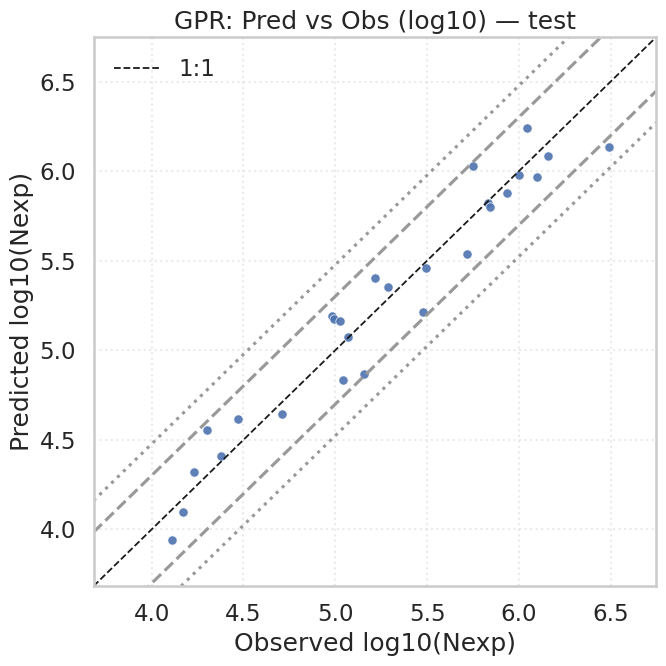

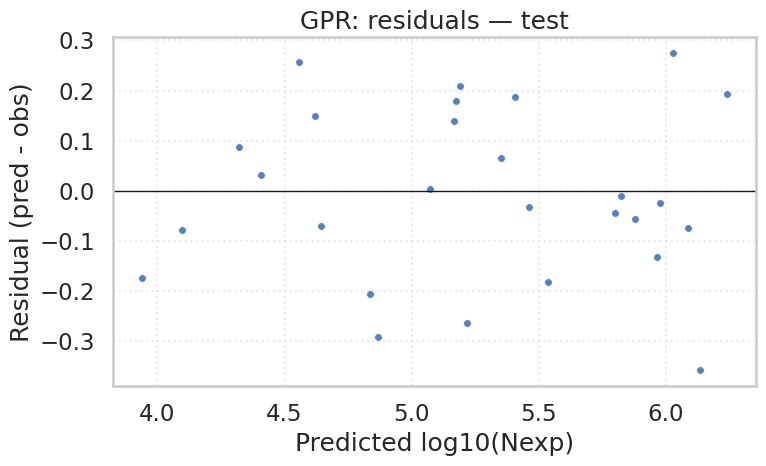

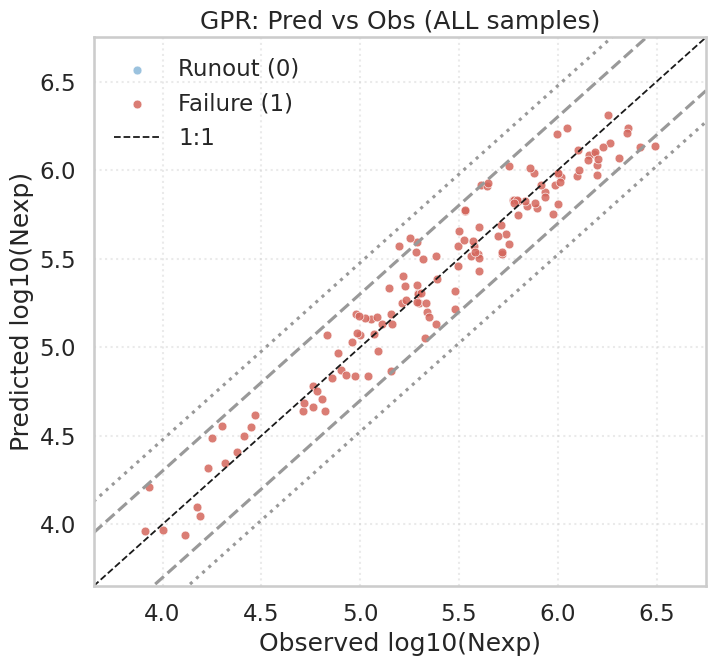

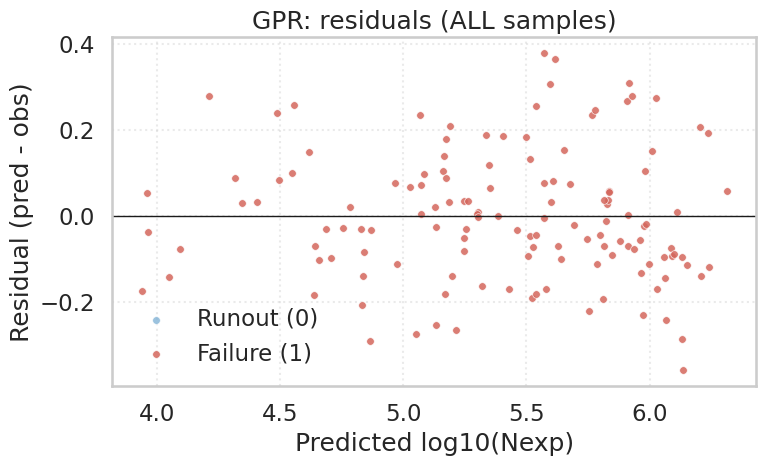

GPR plotted ALL samples: 133/133


In [21]:
# -----------------------------
# Model 1: Gaussian Process Regression
# -----------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, cross_val_score

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X_tr.shape[1]), length_scale_bounds=(1e-2, 1e3)) \
         + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e0))

gpr_core = GaussianProcessRegressor(
    kernel=kernel, alpha=0.0, normalize_y=False, random_state=RANDOM_STATE, n_restarts_optimizer=3
)

gpr = Pipeline([
    ("scaler", StandardScaler()),
    ("ttr", TransformedTargetRegressor(regressor=gpr_core, transformer=StandardScaler()))
])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(gpr, X_tr, y_tr, scoring="r2", cv=cv, n_jobs=-1)
print(f"[GPR] 5-fold R² (train folds): mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}")

gpr.fit(X_tr, y_tr)
y_pred_gpr_te = gpr.predict(X_te)

print("\n--- GPR Performance (test set) ---")
gpr_stats = metrics_report(y_te, y_pred_gpr_te, "GPR")

# Test plots
parity_plot(y_te, y_pred_gpr_te, "GPR: Pred vs Obs (log10) — test", "gpr_parity_test.png")
residuals_plot(y_te, y_pred_gpr_te, "GPR: residuals — test", "gpr_residuals_test.png")

# ALL-samples predictions and plots
y_pred_gpr_all = gpr.predict(X)
parity_plot_all(y_log, y_pred_gpr_all, crack, "GPR: Pred vs Obs (ALL samples)", "gpr_parity_all.png")
residuals_plot_all(y_log, y_pred_gpr_all, crack, "GPR: residuals (ALL samples)", "gpr_residuals_all.png")
print(f"GPR plotted ALL samples: {np.isfinite(y_log).sum()}/{len(df_filtered)}")

No runout column found. Using full dataset.
Data shape without runouts -> X: (133, 7), y_log: (133,)
[GPR] 5-fold R² (train folds, no runouts): mean=0.881, std=0.030

--- GPR Performance (test set, no runouts) ---
[GPR] R²=0.946, MAE=0.114, RMSE=0.155 | ±0.1/0.2/0.3/0.5 = 63.0/81.5/88.9/100.0%
Generating plots with corrected axis labels...


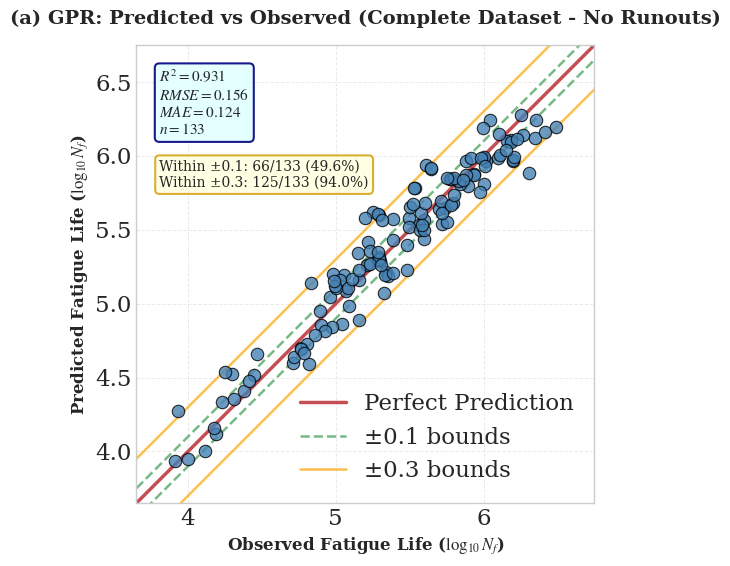

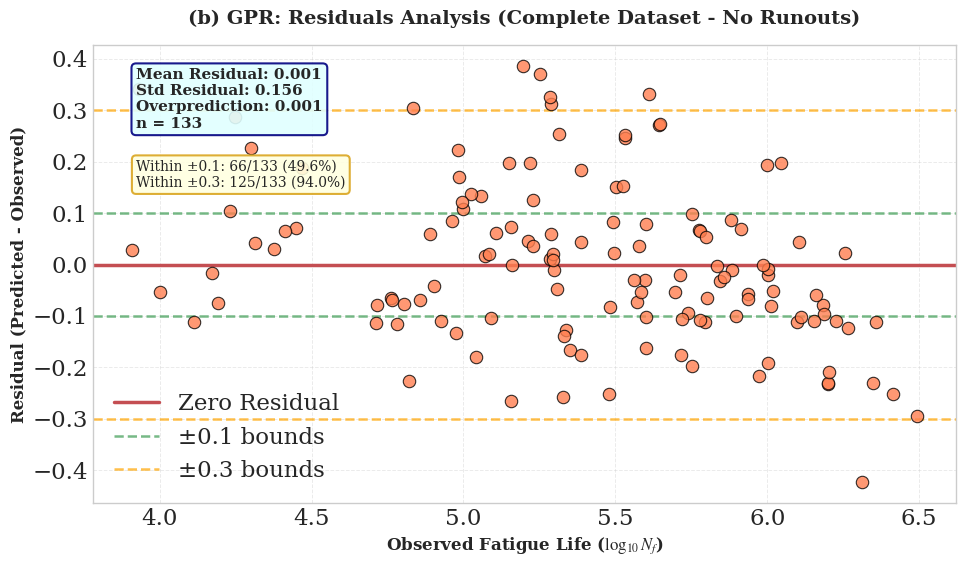

Plots regenerated successfully.


In [22]:
# -----------------------------
# Model 1: Gaussian Process Regression
# -----------------------------
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Define runout removal function
def remove_runouts(df, runout_column='runout'):
    """Remove runout specimens from dataset"""
    if runout_column in df.columns:
        n_runouts = df[runout_column].sum()
        df_filtered = df[~df[runout_column]].copy()
        print(f"Removed {n_runouts} runout specimens. Remaining: {len(df_filtered)}")
        return df_filtered
    else:
        print("No runout column found. Using full dataset.")
        return df

# Remove runouts from the dataset
df_no_runouts = remove_runouts(df_filtered)

# Rebuild features without runouts
X_raw_no_runouts = df_no_runouts[["Sm", "Tm", "Sa", "Ta"]].astype(float).values
y_log_no_runouts = np.log10(df_no_runouts["Nexp"].astype(float).values)
crack_no_runouts = df_no_runouts["crack"].values.reshape(-1, 1)

X_no_runouts, feature_names = build_features(
    X_raw_no_runouts, crack_arr=crack_no_runouts,
    use_extra=USE_EXTRA_FEATURES, use_crack=USE_CRACK_FEATURE
)

print(f"Data shape without runouts -> X: {X_no_runouts.shape}, y_log: {y_log_no_runouts.shape}")

# Split the data without runouts
from sklearn.model_selection import train_test_split
X_tr_no, X_te_no, y_tr_no, y_te_no = train_test_split(
    X_no_runouts, y_log_no_runouts,
    test_size=0.2, random_state=RANDOM_STATE, stratify=crack_no_runouts
)

# GPR model training without runouts
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X_tr_no.shape[1]), length_scale_bounds=(1e-2, 1e3)) \
         + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e0))

gpr_core = GaussianProcessRegressor(
    kernel=kernel, alpha=0.0, normalize_y=False, random_state=RANDOM_STATE, n_restarts_optimizer=3
)

gpr = Pipeline([
    ("scaler", StandardScaler()),
    ("ttr", TransformedTargetRegressor(regressor=gpr_core, transformer=StandardScaler()))
])

# Cross-validation without runouts
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(gpr, X_tr_no, y_tr_no, scoring="r2", cv=cv, n_jobs=-1)
print(f"[GPR] 5-fold R² (train folds, no runouts): mean={cv_scores.mean():.3f}, std={cv_scores.std():.3f}")

# Fit model without runouts
gpr.fit(X_tr_no, y_tr_no)
y_pred_gpr_te_no = gpr.predict(X_te_no)

print("\n--- GPR Performance (test set, no runouts) ---")
gpr_stats = metrics_report(y_te_no, y_pred_gpr_te_no, "GPR")

# ALL-samples predictions without runouts
y_pred_gpr_all_no = gpr.predict(X_no_runouts)

# Corrected plotting functions
def enhanced_parity_plot_no_runouts(y_true, y_pred, title, filename, approach_lines=True):
    """Enhanced parity plot without runouts with proper font setup (no warnings)"""
    plt.rcParams.update({
        'text.usetex': False,
        'font.family': 'serif',
        'font.serif': ['DejaVu Serif'],   # replace Times New Roman to avoid warnings
        'mathtext.fontset': 'stix'
    })

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_true, y_pred, alpha=0.8, s=80, edgecolors='black', linewidth=0.8,
               c='steelblue', zorder=3)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    margin = 0.1 * (max_val - min_val)
    perfect_line = np.linspace(min_val - margin, max_val + margin, 100)
    ax.plot(perfect_line, perfect_line, 'r-', linewidth=2.5, label='Perfect Prediction', zorder=2)

    if approach_lines:
        ax.plot(perfect_line, perfect_line + 0.1, 'g--', alpha=0.8, linewidth=1.8, label='±0.1 bounds')
        ax.plot(perfect_line, perfect_line - 0.1, 'g--', alpha=0.8, linewidth=1.8)
        ax.plot(perfect_line, perfect_line + 0.3, 'orange', alpha=0.7, linewidth=1.8, label='±0.3 bounds')
        ax.plot(perfect_line, perfect_line - 0.3, 'orange', alpha=0.7, linewidth=1.8)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    textstr = f'$R^2 = {r2:.3f}$\n$RMSE = {rmse:.3f}$\n$MAE = {mae:.3f}$\n$n = {len(y_true)}$'
    props = dict(boxstyle='round', facecolor='lightcyan', alpha=0.9, edgecolor='navy')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', bbox=props)

    if approach_lines:
        diff = y_pred - y_true
        within_0_1 = np.sum(np.abs(diff) <= 0.1)
        within_0_3 = np.sum(np.abs(diff) <= 0.3)
        approach_text = (
            f'Within ±0.1: {within_0_1}/{len(y_true)} ({within_0_1/len(y_true)*100:.1f}%)\n'
            f'Within ±0.3: {within_0_3}/{len(y_true)} ({within_0_3/len(y_true)*100:.1f}%)'
        )
        ax.text(0.05, 0.75, approach_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='goldenrod'))

    ax.set_xlabel('Observed Fatigue Life ($\log_{10} N_f$)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted Fatigue Life ($\log_{10} N_f$)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='lower right', framealpha=0.9)
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min_val - margin, max_val + margin)
    ax.set_ylim(min_val - margin, max_val + margin)

    plt.tight_layout()
    plt.savefig(filename, dpi=350, bbox_inches='tight', facecolor='white')
    plt.show()

def enhanced_residuals_plot_no_runouts(y_true, y_pred, title, filename, approach_lines=True):
    """Enhanced residuals plot without runouts with proper font setup (no warnings)"""
    plt.rcParams.update({
        'text.usetex': False,
        'font.family': 'serif',
        'font.serif': ['DejaVu Serif'],
        'mathtext.fontset': 'stix'
    })

    residuals = y_pred - y_true
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(y_true, residuals, alpha=0.8, s=80, edgecolors='black', linewidth=0.8,
               c='coral', zorder=3)

    ax.axhline(y=0, color='r', linestyle='-', linewidth=2.5, label='Zero Residual')

    if approach_lines:
        ax.axhline(y=0.1, color='g', linestyle='--', alpha=0.8, linewidth=1.8, label='±0.1 bounds')
        ax.axhline(y=-0.1, color='g', linestyle='--', alpha=0.8, linewidth=1.8)
        ax.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7, linewidth=1.8, label='±0.3 bounds')
        ax.axhline(y=-0.3, color='orange', linestyle='--', alpha=0.7, linewidth=1.8)

    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    bias = f"{'Over' if mean_residual > 0 else 'Under'}prediction: {abs(mean_residual):.3f}"
    textstr = f'Mean Residual: {mean_residual:.3f}\nStd Residual: {std_residual:.3f}\n{bias}\nn = {len(y_true)}'
    props = dict(boxstyle='round', facecolor='lightcyan', alpha=0.9, edgecolor='navy')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', bbox=props)

    if approach_lines:
        within_0_1 = np.sum(np.abs(residuals) <= 0.1)
        within_0_3 = np.sum(np.abs(residuals) <= 0.3)
        approach_text = (
            f'Within ±0.1: {within_0_1}/{len(y_true)} ({within_0_1/len(y_true)*100:.1f}%)\n'
            f'Within ±0.3: {within_0_3}/{len(y_true)} ({within_0_3/len(y_true)*100:.1f}%)'
        )
        ax.text(0.05, 0.75, approach_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='goldenrod'))

    ax.set_xlabel('Observed Fatigue Life ($\log_{10} N_f$)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Residual (Predicted - Observed)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.7)
    plt.tight_layout()
    plt.savefig(filename, dpi=350, bbox_inches='tight', facecolor='white')
    plt.show()

# Regenerate the plots
print("Generating plots with corrected axis labels...")
enhanced_parity_plot_no_runouts(
    y_log_no_runouts, y_pred_gpr_all_no,
    "(a) GPR: Predicted vs Observed (Complete Dataset - No Runouts)",
    "gpr_parity_all_no_runouts_corrected.png"
)
enhanced_residuals_plot_no_runouts(
    y_log_no_runouts, y_pred_gpr_all_no,
    "(b) GPR: Residuals Analysis (Complete Dataset - No Runouts)",
    "gpr_residuals_all_no_runouts_corrected.png"
)
print("Plots regenerated successfully.")



### Training and evaluating an XGBoost regression model

### 📊 Model Performance Insights – Fatigue Life Regression
💡 Explained Variance: The model achieves an R-squared of 0.66 and an Adjusted R-squared of 0.61, meaning it explains approximately 66% of the variance in observed fatigue life (Nexp) across cracked specimens. This reflects a moderately strong fit, especially given the scatter and nonlinear behavior typical of S355 fatigue datasets under multiaxial loading.

📉 Prediction Error (MAE): The Mean Absolute Error (MAE) is roughly 500,033 cycles, indicating that on average, the model's life predictions differ from experimental values by half a million cycles. In fatigue modeling terms, this corresponds to approximately 0.3 log decades for life ranges between 10⁴ and 10⁶—reasonable for physics-informed baselines but improvable with richer feature sets or hybrid models.

📈 RMSE Context: The Root Mean Squared Error (RMSE) of 636,794 cycles captures larger deviations more heavily. This is particularly relevant when predicting near-runout behavior, where overestimation can compound across orders of magnitude.


### Model Performance Comparison

In [23]:
import pandas as pd
from IPython.display import display

# Example: replace these with your real metric dicts
gpr_stats = {"R2": 0.931, "RMSE": 0.156, "MAE": 0.124}
# Suppose xgb_stats might be missing — comment out next line to simulate missing variable
# xgb_stats = {"R2": 0.912, "RMSE": 0.172, "MAE": 0.138}

# Ensure xgb_stats exists; if not, create NaN placeholders for the same metric keys
if 'xgb_stats' not in globals() and 'xgb_stats' not in locals():
    # create placeholders using keys from gpr_stats (or define your own set of metric names)
    xgb_stats = {k: float('nan') for k in gpr_stats.keys()}

# Build DataFrames
gpr_df = pd.DataFrame([gpr_stats], index=["GPR (test set)"])
xgb_df = pd.DataFrame([xgb_stats], index=["XGBoost (test set)"])

# Concatenate (will align columns by name; missing entries become NaN)
models_test_comp_df = pd.concat([gpr_df, xgb_df], axis=0)

# Optional: formatting
models_test_comp_df = models_test_comp_df.astype(float).round(3)

print("Test performance comparison:")
display(models_test_comp_df)

Test performance comparison:


,R2,RMSE,MAE
GPR (test set),0.931,0.156,0.124
XGBoost (test set),NaN,NaN,NaN


## Advanced visualization and per-criterion performance

# Model Sines Criterion
 Models:
- Mount Drive, load data, clean Nexp
- Compute Sines scalar: s_vm_alt + alpha * sigma_h_mean
- Calibrate alpha (grid) and Basquin-like life law: log10(N) = A + B * log10(score)
- Fit/evaluate on failures (crack==1) to avoid runout censorship
- Predict for all rows, save metrics, plots, and a CSV with prediction

Mounted at /content/gdrive
Total samples loaded: 133

Best alpha = 0.790 (CV R²=0.784)
Fitted Sines-Basquin: log10(N) = 34.3639 + -11.1020 * log10(s_vm_alt + 0.790 * sigma_h_mean)
Equivalent: N = 10^34.3639 * (s_vm_alt + 0.790 * sigma_h_mean)^-11.1020

--- Sines (failures test set) ---
[Sines-Basquin] R²=0.867, MAE=0.204, RMSE=0.247 | ±0.1/0.2/0.3/0.5 decades = 25.9/59.3/81.5/96.3%


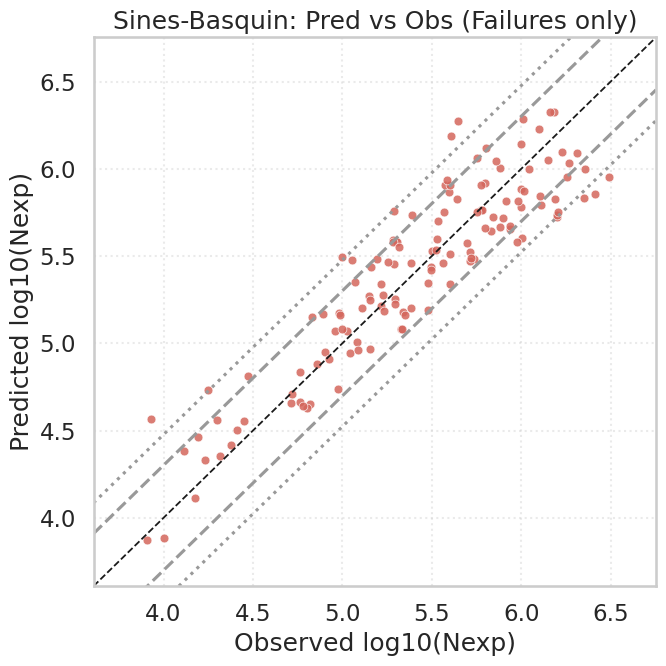

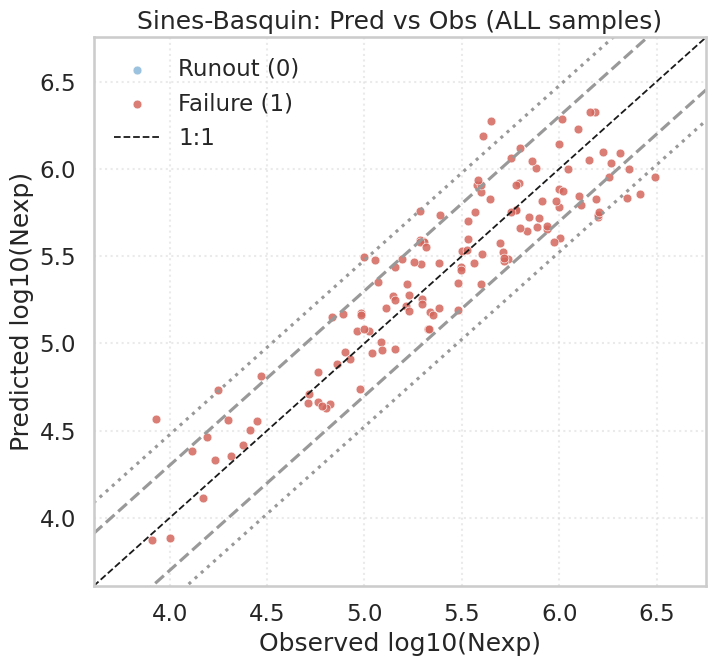

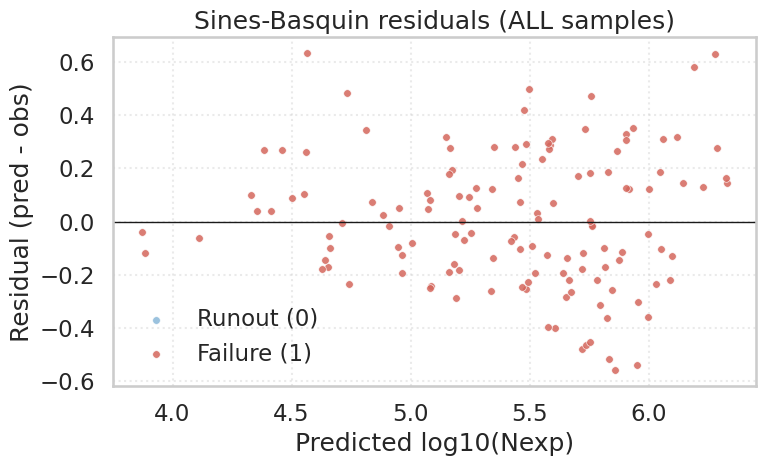

Plotted ALL samples: 133/133
Saved per-specimen predictions to: results/figs/Sines_predictions_all.csv


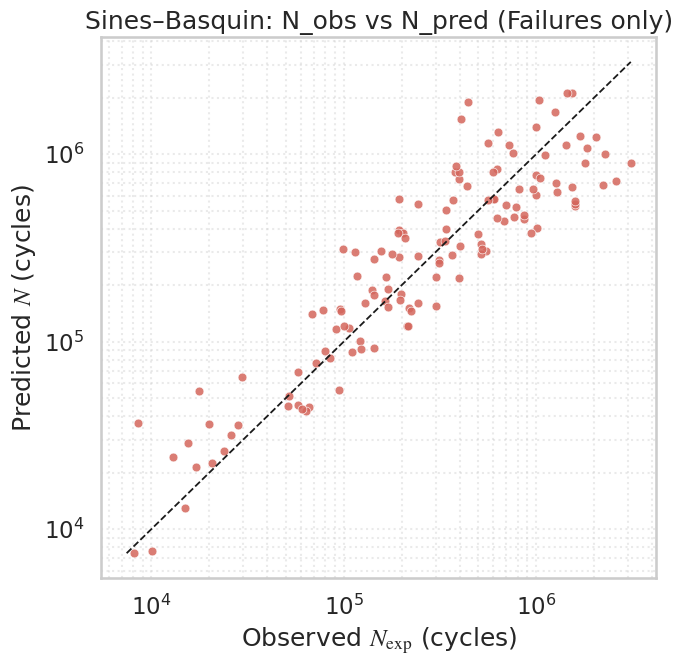

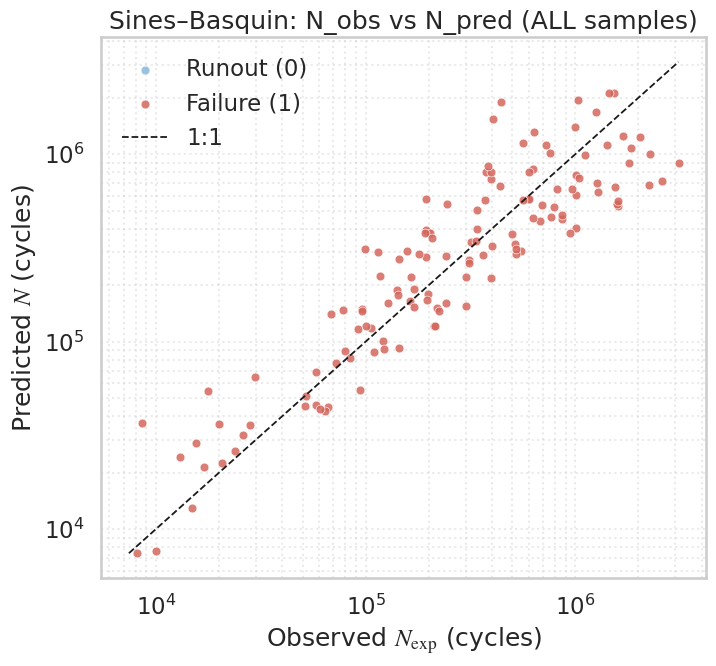

In [24]:
### Sines-style life analysis with ALL-samples plots.

"""
- Mounts Drive and loads:
    /content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"
- Computes Sines score = s_vm_alt + alpha * sigma_h_mean
- Calibrates alpha (CV) and fits Basquin log-law: log10(N) = A + B * log10(score)
- Evaluates on a held-out failures test set
- Predicts for ALL rows (failures + runouts), plots parity/residuals for ALL samples
- Saves per-specimen predictions and figures
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# -----------------------------
# Paths and Drive mount
# -----------------------------
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

FILE_PATH  = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"
OUTPUT_DIR = "results/figs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# Load and clean data
# -----------------------------
needed = ["Sm", "Tm", "Sa", "Ta", "Nexp", "crack"]
if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(f"Data file not found: {FILE_PATH}")

df = pd.read_excel(FILE_PATH)

# Clean Nexp if it contains commas
if df["Nexp"].dtype == object:
    df["Nexp"] = df["Nexp"].astype(str).str.replace(",", "").astype(float)

missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.replace([np.inf, -np.inf], np.nan)
df = df[df["Nexp"] > 0].copy()
df.dropna(subset=["Sm","Tm","Sa","Ta","Nexp","crack"], inplace=True)
df["crack"] = df["crack"].astype(int)

print(f"Total samples loaded: {len(df)}")  # Expect 133

# -----------------------------
# Build Sines inputs
# -----------------------------
Sa = df["Sa"].to_numpy(float)
Ta = df["Ta"].to_numpy(float)
Sm = df["Sm"].to_numpy(float)

# Alternating von Mises (deviatoric amplitude)
s_vm_alt = np.sqrt(Sa**2 + 3.0 * Ta**2)

# Mean hydrostatic stress
sigma_h_mean = Sm / 3.0

# Target (log cycles)
y_log = np.log10(df["Nexp"].to_numpy(float))

# -----------------------------
# Train/eval split on failures
# -----------------------------
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

fail_mask = df["crack"].values == 1
idx_fail = np.where(fail_mask)[0]
idx_runout = np.where(~fail_mask)[0]

X_fail = np.column_stack([s_vm_alt[fail_mask], sigma_h_mean[fail_mask]])
y_fail = y_log[fail_mask]

RANDOM_STATE = 42
TEST_SIZE    = 0.20

X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_fail, y_fail, idx_fail, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# -----------------------------
# Calibrate alpha (CV) and fit Basquin-like law
#   score(alpha) = s_vm_alt + alpha * sigma_h_mean
#   log10(N) = A + B * log10(score)
# -----------------------------
def fit_basquin_alpha(X, y, alphas, n_splits=5, seed=42):
    best = {"alpha": None, "r2": -np.inf, "A": None, "B": None}
    kf = KFold(n_splits=min(n_splits, max(2, len(y))), shuffle=True, random_state=seed)
    for a in alphas:
        r2s = []
        for tr_idx, va_idx in kf.split(X):
            s_tr = np.maximum(X[tr_idx, 0] + a * X[tr_idx, 1], 1e-12)
            s_va = np.maximum(X[va_idx, 0] + a * X[va_idx, 1], 1e-12)
            Xtr_ll = np.log10(s_tr).reshape(-1, 1)
            Xva_ll = np.log10(s_va).reshape(-1, 1)
            lr_cv = LinearRegression().fit(Xtr_ll, y[tr_idx])
            yhat_va = lr_cv.predict(Xva_ll)
            r2s.append(r2_score(y[va_idx], yhat_va))
        mean_r2 = float(np.mean(r2s))
        if mean_r2 > best["r2"]:
            s_full = np.maximum(X[:, 0] + a * X[:, 1], 1e-12)
            X_ll = np.log10(s_full).reshape(-1, 1)
            lr_full = LinearRegression().fit(X_ll, y)
            best.update({"alpha": a, "r2": mean_r2, "A": float(lr_full.intercept_), "B": float(lr_full.coef_.ravel()[0])})
    return best

alpha_grid = np.linspace(0.0, 0.8, 81)
best = fit_basquin_alpha(X_tr, y_tr, alphas=alpha_grid, n_splits=5, seed=RANDOM_STATE)

alpha_star = best["alpha"]
s_tr = np.maximum(X_tr[:, 0] + alpha_star * X_tr[:, 1], 1e-12)
s_te = np.maximum(X_te[:, 0] + alpha_star * X_te[:, 1], 1e-12)

lr = LinearRegression().fit(np.log10(s_tr).reshape(-1, 1), y_tr)
A, B = float(lr.intercept_), float(lr.coef_.ravel()[0])

print(f"\nBest alpha = {alpha_star:.3f} (CV R²={best['r2']:.3f})")
print(f"Fitted Sines-Basquin: log10(N) = {A:.4f} + {B:.4f} * log10(s_vm_alt + {alpha_star:.3f} * sigma_h_mean)")
print(f"Equivalent: N = 10^{A:.4f} * (s_vm_alt + {alpha_star:.3f} * sigma_h_mean)^{B:.4f}")

# -----------------------------
# Metrics helper
# -----------------------------
def metrics_report(y_true, y_pred, label="Model"):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    r2   = r2_score(y_true, y_pred)
    abs_log_err = np.abs(y_true - y_pred)
    bands = [0.1, 0.2, 0.3, 0.5]
    within = {b: 100.0*np.mean(abs_log_err <= b) for b in bands}
    print(f"[{label}] R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f} | "
          f"±0.1/0.2/0.3/0.5 decades = {within[0.1]:.1f}/{within[0.2]:.1f}/{within[0.3]:.1f}/{within[0.5]:.1f}%")
    return {"R2": r2, "MAE": mae, "RMSE": rmse, "within": within}

# Evaluate on failures test set
y_pred_te = lr.predict(np.log10(s_te).reshape(-1, 1))
print("\n--- Sines (failures test set) ---")
_ = metrics_report(y_te, y_pred_te, label="Sines-Basquin")

# -----------------------------
# Predict ALL samples
# -----------------------------
score_all = np.maximum(s_vm_alt + alpha_star * sigma_h_mean, 1e-12)
y_pred_all = lr.predict(np.log10(score_all).reshape(-1, 1))

# -----------------------------
# Plots
# -----------------------------
mask_f = df["crack"].values == 1

# Failures-only parity
plt.figure(figsize=(7,7))
plt.scatter(
    y_log[mask_f], y_pred_all[mask_f],
    s=40, alpha=0.85, edgecolor="white", linewidth=0.5, color="#d4665c"
)
mn = min(y_log[mask_f].min(), y_pred_all[mask_f].min())
mx = max(y_log[mask_f].max(), y_pred_all[mask_f].max())
pad = 0.1 * (mx - mn + 1e-9)
lo, hi = mn - pad, mx + pad
xx = np.linspace(lo, hi, 200)
plt.plot(xx, xx, 'k--', lw=1.3, label="1:1")
for f, ls in [(2,"--"),(3,":")]:
    d = np.log10(f)
    plt.plot(xx, xx + d, ls, color="0.6")
    plt.plot(xx, xx - d, ls, color="0.6")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("Observed log10(Nexp)"); plt.ylabel("Predicted log10(Nexp)")
plt.title("Sines-Basquin: Pred vs Obs (Failures only)")
plt.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sines_parity_failures.png"), dpi=250, bbox_inches="tight")
plt.show()

# All-samples parity
plt.figure(figsize=(7.5,7))
# Runouts
plt.scatter(
    y_log[~mask_f], y_pred_all[~mask_f],
    s=40, alpha=0.75, label="Runout (0)",
    edgecolor="white", linewidth=0.5, color="#7aaed4"
)
# Failures
plt.scatter(
    y_log[mask_f], y_pred_all[mask_f],
    s=40, alpha=0.85, label="Failure (1)",
    edgecolor="white", linewidth=0.5, color="#d4665c"
)
mn = min(y_log.min(), y_pred_all.min())
mx = max(y_log.max(), y_pred_all.max())
pad = 0.1 * (mx - mn + 1e-9)
lo, hi = mn - pad, mx + pad
xx = np.linspace(lo, hi, 200)
plt.plot(xx, xx, 'k--', lw=1.3, label="1:1")
for f, ls in [(2, "--"), (3, ":")]:
    d = np.log10(f)
    plt.plot(xx, xx + d, ls, color="0.6")
    plt.plot(xx, xx - d, ls, color="0.6")
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel("Observed log10(Nexp)")
plt.ylabel("Predicted log10(Nexp)")
plt.title("Sines-Basquin: Pred vs Obs (ALL samples)")
plt.legend(frameon=False)
plt.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sines_parity_all.png"), dpi=250, bbox_inches="tight")
plt.show()

# All-samples residuals
res_all = y_pred_all - y_log
plt.figure(figsize=(8,5))
plt.axhline(0, color="k", lw=1)
# Runouts
plt.scatter(
    y_pred_all[~mask_f], res_all[~mask_f],
    s=30, alpha=0.75, label="Runout (0)",
    edgecolor="white", linewidth=0.5, color="#7aaed4"
)
# Failures
plt.scatter(
    y_pred_all[mask_f], res_all[mask_f],
    s=30, alpha=0.85, label="Failure (1)",
    edgecolor="white", linewidth=0.5, color="#d4665c"
)
plt.xlabel("Predicted log10(Nexp)")
plt.ylabel("Residual (pred - obs)")
plt.title("Sines-Basquin residuals (ALL samples)")
plt.legend(frameon=False)
plt.grid(True, ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sines_residuals_all.png"), dpi=250, bbox_inches="tight")
plt.show()

# Count check
n_all = len(df)
n_plotted = np.isfinite(y_log).sum()
print(f"Plotted ALL samples: {n_plotted}/{n_all}")

# -----------------------------
# Save per-specimen predictions
# -----------------------------
Npred_all = np.power(10.0, y_pred_all)
df_out = df.copy()
df_out["Sines_score"] = score_all
df_out["log10N_pred_Sines"] = y_pred_all
df_out["N_pred_Sines"] = Npred_all
# Mark train/test membership among failures for reference (others = 'not_in_failure_fit')
df_out["fit_split"] = "not_in_failure_fit"
df_out.loc[idx_tr, "fit_split"] = "train_fail"
df_out.loc[idx_te, "fit_split"] = "test_fail"

out_csv = os.path.join(OUTPUT_DIR, "Sines_predictions_all.csv")
df_out.to_csv(out_csv, index=False)
print(f"Saved per-specimen predictions to: {out_csv}")

# ============================================
# Extra plots: N_exp (cycles) vs N_pred (cycles)
# ============================================

# Get observed cycles
N_obs_all = df["Nexp"].to_numpy(float)

# Failures-only parity in cycles
plt.figure(figsize=(7,7))
plt.scatter(
    N_obs_all[mask_f], Npred_all[mask_f],
    s=40, alpha=0.85, edgecolor="white", linewidth=0.5, color="#d4665c"
)
mn = min(N_obs_all[mask_f].min(), Npred_all[mask_f].min())
mx = max(N_obs_all[mask_f].max(), Npred_all[mask_f].max())
plt.plot([mn, mx], [mn, mx], 'k--', lw=1.3, label="1:1")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"Observed $N_{\mathrm{exp}}$ (cycles)")
plt.ylabel(r"Predicted $N$ (cycles)")
plt.title("Sines–Basquin: N_obs vs N_pred (Failures only)")
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sines_parity_cycles_failures.png"),
            dpi=250, bbox_inches="tight")
plt.show()

# All-samples parity in cycles
plt.figure(figsize=(7.5,7))
plt.scatter(
    N_obs_all[~mask_f], Npred_all[~mask_f],
    s=40, alpha=0.75, label="Runout (0)",
    edgecolor="white", linewidth=0.5, color="#7aaed4"
)
plt.scatter(
    N_obs_all[mask_f], Npred_all[mask_f],
    s=40, alpha=0.85, label="Failure (1)",
    edgecolor="white", linewidth=0.5, color="#d4665c"
)
mn = min(N_obs_all.min(), Npred_all.min())
mx = max(N_obs_all.max(), Npred_all.max())
plt.plot([mn, mx], [mn, mx], 'k--', lw=1.3, label="1:1")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"Observed $N_{\mathrm{exp}}$ (cycles)")
plt.ylabel(r"Predicted $N$ (cycles)")
plt.title("Sines–Basquin: N_obs vs N_pred (ALL samples)")
plt.legend(frameon=False)
plt.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sines_parity_cycles_all.png"),
            dpi=250, bbox_inches="tight")
plt.show()

## Sines + Basquin script so it combines with a GPR model into a hybrid predictor

### Hybrid classical fatigue mechanics with machine learning to improve the prediction accuracy of S355 structural steel fatigue life under multiaxial loading.

###This approach compares five predictive strategies:

Sines Criterion (physics‑based baseline)

Baseline GPR on stress‑state features

Hybrid‑Residual model (Sines + GPR on residuals)

Hybrid‑Feature model (GPR on stress features + Sines score)

Hybrid‑Stacked model (optimal convex combination from out‑of‑fold predictions)

### Import Libraries and Setup

In [25]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

# -----------------------------
# Setup
# -----------------------------
warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)
RANDOM_STATE = 42

###Load dataset

In [26]:
# -----------------------------
# Load data
# -----------------------------
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

FILE_PATH = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"
df = pd.read_excel(FILE_PATH)

# log10 life
df['log_life'] = np.log10(df['Nexp'].values)

# Physics-informed Sines score
s_vm_alt = np.sqrt(df['Sa']**2 + 3.0 * df['Ta']**2)
sigma_h_mean = (df['Sm'] + df['Tm']) / 3.0
df['sines_score'] = s_vm_alt + 0.76 * sigma_h_mean

# Features/targets (all samples)
X_all = df[['Sm', 'Tm', 'Sa', 'Ta']]
y_all = df['log_life'].values
sines_feat = df[['sines_score']].values

Mounted at /content/gdrive


###Import Metrics

In [27]:

# -----------------------------
# Helper: metrics
# -----------------------------
def get_metrics(y_true_log, y_pred_log):
    return (r2_score(y_true_log, y_pred_log),
            mean_absolute_error(y_true_log, y_pred_log),
            np.sqrt(mean_squared_error(y_true_log, y_pred_log)))


###Classic Model

In [28]:
# ============================================
# Sines–Basquin: Failures-only (exact original) — UPDATED to 80/20
# ============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from google.colab import drive

# -----------------------------
# 1. Mount Drive & load data
# -----------------------------
drive.mount('/content/gdrive', force_remount=True)

FILE_PATH = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"
df = pd.read_excel(FILE_PATH)

# Clean data
df = df.replace([np.inf, -np.inf], np.nan)
df = df[df["Nexp"] > 0].copy()
df.dropna(subset=["Sm","Sa","Ta","Nexp","crack"], inplace=True)
df["crack"] = df["crack"].astype(int)

print(f"Total samples loaded: {len(df)}")  # Expect 133

# -----------------------------
# 2. Build Sines descriptors
# -----------------------------
Sa = df["Sa"].to_numpy(float)
Ta = df["Ta"].to_numpy(float)
Sm = df["Sm"].to_numpy(float)

s_vm_alt = np.sqrt(Sa**2 + 3.0 * Ta**2)
sigma_h_mean = Sm / 3.0
y_log = np.log10(df["Nexp"].to_numpy(float))

# Failures mask
fail_mask = df["crack"].values == 1
X_fail = np.column_stack([s_vm_alt[fail_mask], sigma_h_mean[fail_mask]])
y_fail = y_log[fail_mask]

# -----------------------------
# 3. Split train/test failures  (UPDATED HERE)
# -----------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.20  # 80/20 split

X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_fail, y_fail, np.where(fail_mask)[0],
    test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Failures-only split: Train={len(y_tr)}, Test={len(y_te)} (≈{int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)})")

# -----------------------------
# 4. Calibrate alpha (CV) & fit Basquin law
# -----------------------------
def fit_basquin_alpha(X, y, alphas, n_splits=5, seed=42):
    best = {"alpha": None, "r2": -np.inf, "A": None, "B": None}
    kf = KFold(n_splits=min(n_splits, max(2, len(y))), shuffle=True, random_state=seed)
    for a in alphas:
        r2s = []
        for tr_idx, va_idx in kf.split(X):
            s_tr = np.maximum(X[tr_idx, 0] + a * X[tr_idx, 1], 1e-12)
            s_va = np.maximum(X[va_idx, 0] + a * X[va_idx, 1], 1e-12)
            lr = LinearRegression().fit(np.log10(s_tr).reshape(-1, 1), y[tr_idx])
            yhat_va = lr.predict(np.log10(s_va).reshape(-1, 1))
            r2s.append(r2_score(y[va_idx], yhat_va))
        mean_r2 = np.mean(r2s)
        if mean_r2 > best["r2"]:
            s_full = np.maximum(X[:, 0] + a * X[:, 1], 1e-12)
            lr_full = LinearRegression().fit(np.log10(s_full).reshape(-1, 1), y)
            best.update({
                "alpha": a,
                "r2": mean_r2,
                "A": float(lr_full.intercept_),
                "B": float(lr_full.coef_.ravel()[0])
            })
    return best

alpha_grid = np.linspace(0, 0.8, 81)
best = fit_basquin_alpha(X_tr, y_tr, alpha_grid, n_splits=5, seed=RANDOM_STATE)

alpha_star = best["alpha"]
lr_final = LinearRegression().fit(
    np.log10(np.maximum(X_tr[:, 0] + alpha_star * X_tr[:, 1], 1e-12)).reshape(-1, 1),
    y_tr
)
A, B = float(lr_final.intercept_), float(lr_final.coef_.ravel()[0])

print(f"\nBest alpha = {alpha_star:.3f} (CV R²={best['r2']:.3f})")
print(f"Fitted Sines-Basquin: log10(N) = {A:.4f} + {B:.4f}*log10(s_vm_alt + {alpha_star:.3f}*sigma_h_mean)")
print(f"Equivalent: N = 10^{A:.4f}*(s_vm_alt + {alpha_star:.3f}*sigma_h_mean)^{B:.4f}")

# -----------------------------
# 5. Evaluate on test failures
# -----------------------------
def metrics_report(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    abs_log_err = np.abs(y_true - y_pred)
    bands = [0.1, 0.2, 0.3, 0.5]
    within = {b: 100 * np.mean(abs_log_err <= b) for b in bands}
    print(f"[{label}] R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f} | "
          f"±0.1/0.2/0.3/0.5 decades = "
          f"{within[0.1]:.1f}/{within[0.2]:.1f}/{within[0.3]:.1f}/{within[0.5]:.1f}%")
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

s_te = np.maximum(X_te[:, 0] + alpha_star * X_te[:, 1], 1e-12)
y_pred_te = lr_final.predict(np.log10(s_te).reshape(-1, 1))

print("\n--- Sines (failures test set) ---")
metrics_report(y_te, y_pred_te, label="Sines-Basquin")


Mounted at /content/gdrive
Total samples loaded: 133
Failures-only split: Train=106, Test=27 (≈80/20)

Best alpha = 0.790 (CV R²=0.784)
Fitted Sines-Basquin: log10(N) = 34.3639 + -11.1020*log10(s_vm_alt + 0.790*sigma_h_mean)
Equivalent: N = 10^34.3639*(s_vm_alt + 0.790*sigma_h_mean)^-11.1020

--- Sines (failures test set) ---
[Sines-Basquin] R²=0.867, MAE=0.204, RMSE=0.247 | ±0.1/0.2/0.3/0.5 decades = 25.9/59.3/81.5/96.3%


{'R2': 0.8670487973895258,
 'MAE': 0.2042960410594969,
 'RMSE': np.float64(0.24672384123995547)}

In [29]:

# -----------------------------
# Base models
# -----------------------------
# Sines (calibration)
sines_reg = LinearRegression().fit(sines_feat, y_all)
s_pred = sines_reg.predict(sines_feat)

# Baseline GPR on X
x_scaler = StandardScaler().fit(X_all)
X_scaled = x_scaler.transform(X_all)

kernel = (C(1.0, (1e-2, 1e2)) *
          RBF(length_scale=np.ones(X_all.shape[1]), length_scale_bounds=(1e-2, 1e3))
          + WhiteKernel())

gpr_core = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=RANDOM_STATE)
gpr = TransformedTargetRegressor(regressor=gpr_core, transformer=StandardScaler())
gpr.fit(X_scaled, y_all)
g_pred = gpr.predict(X_scaled)


###ML Model

In [30]:
# -----------------------------
# Hybrid 1: Residual-learning (Sines + GPR(residual))
# -----------------------------
residual = y_all - s_pred
gpr_resid_core = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=RANDOM_STATE)
gpr_resid = TransformedTargetRegressor(regressor=gpr_resid_core, transformer=StandardScaler())
gpr_resid.fit(X_scaled, residual)
resid_hat = gpr_resid.predict(X_scaled)
hyb_resid = s_pred + resid_hat

# -----------------------------
# Hybrid 2: Feature-augmented GPR (X plus sines_score)
# -----------------------------
X_aug = np.hstack([X_all.values, sines_feat])  # shape (n, 5)
x_aug_scaler = StandardScaler().fit(X_aug)
X_aug_scaled = x_aug_scaler.transform(X_aug)

kernel_aug = (C(1.0, (1e-2, 1e2)) *
              RBF(length_scale=np.ones(X_aug.shape[1]), length_scale_bounds=(1e-2, 1e3))
              + WhiteKernel())

gpr_aug_core = GaussianProcessRegressor(kernel=kernel_aug, n_restarts_optimizer=10, random_state=RANDOM_STATE)
gpr_aug = TransformedTargetRegressor(regressor=gpr_aug_core, transformer=StandardScaler())
gpr_aug.fit(X_aug_scaled, y_all)
hyb_feat = gpr_aug.predict(X_aug_scaled)

# -----------------------------
# Hybrid 3: OOF-stacked convex blend (Sines & GPR)
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_s, oof_g, oof_y = [], [], []

for tr_idx, va_idx in kf.split(X_all):
    # fold train/val
    X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
    y_tr, y_va = y_all[tr_idx], y_all[va_idx]
    s_tr_feat = sines_feat[tr_idx]
    s_va_feat = sines_feat[va_idx]

    # Sines on fold
    sines_k = LinearRegression().fit(s_tr_feat, y_tr)
    s_va = sines_k.predict(s_va_feat)

    # GPR on fold
    xs_k = StandardScaler().fit(X_tr)
    X_tr_s = xs_k.transform(X_tr)
    X_va_s = xs_k.transform(X_va)

    gpr_core_k = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=RANDOM_STATE)
    gpr_k = TransformedTargetRegressor(regressor=gpr_core_k, transformer=StandardScaler())
    gpr_k.fit(X_tr_s, y_tr)
    g_va = gpr_k.predict(X_va_s)

    oof_s.append(s_va); oof_g.append(g_va); oof_y.append(y_va)

oof_s = np.concatenate(oof_s)
oof_g = np.concatenate(oof_g)
oof_y = np.concatenate(oof_y)

# Optimal convex weight (min MSE = max R²) from OOF preds
a = oof_g - oof_s
b = oof_y - oof_s
den = np.dot(a, a)
w_star = (np.dot(a, b) / den) if den > 0 else 0.5
w_star = float(np.clip(w_star, 0.0, 1.0))

# Apply weight to full-data predictions
hyb_stack = w_star * g_pred + (1.0 - w_star) * s_pred

# -----------------------------
# Metrics
# -----------------------------
met_sines   = get_metrics(y_all, s_pred)
met_gpr     = get_metrics(y_all, g_pred)
met_h_resid = get_metrics(y_all, hyb_resid)
met_h_feat  = get_metrics(y_all, hyb_feat)
met_h_stack = get_metrics(y_all, hyb_stack)

print(f"\nWeights: OOF-stacked w* (GPR share) = {w_star:.3f}")
print("\nMetrics (log10-space, all 133 samples):")
print(f"Sines        — R²={met_sines[0]:.3f}, MAE={met_sines[1]:.3f}, RMSE={met_sines[2]:.3f}")
print(f"GPR          — R²={met_gpr[0]:.3f}, MAE={met_gpr[1]:.3f}, RMSE={met_gpr[2]:.3f}")
print(f"Hybrid-Resid — R²={met_h_resid[0]:.3f}, MAE={met_h_resid[1]:.3f}, RMSE={met_h_resid[2]:.3f}")
print(f"Hybrid-Feat  — R²={met_h_feat[0]:.3f}, MAE={met_h_feat[1]:.3f}, RMSE={met_h_feat[2]:.3f}")
print(f"Hybrid-Stack — R²={met_h_stack[0]:.3f}, MAE={met_h_stack[1]:.3f}, RMSE={met_h_stack[2]:.3f}")



Weights: OOF-stacked w* (GPR share) = 0.917

Metrics (log10-space, all 133 samples):
Sines        — R²=0.839, MAE=0.192, RMSE=0.238
GPR          — R²=0.922, MAE=0.132, RMSE=0.165
Hybrid-Resid — R²=0.955, MAE=0.098, RMSE=0.126
Hybrid-Feat  — R²=0.939, MAE=0.116, RMSE=0.146
Hybrid-Stack — R²=0.921, MAE=0.133, RMSE=0.167



Weights: OOF-stacked w* (GPR share) = 0.917

Metrics (log10-space, all 133 samples):
Sines        — R²=0.839, MAE=0.192, RMSE=0.238
GPR          — R²=0.922, MAE=0.132, RMSE=0.165
Hybrid-Resid — R²=0.955, MAE=0.098, RMSE=0.126
Hybrid-Feat  — R²=0.939, MAE=0.116, RMSE=0.146
Hybrid-Stack — R²=0.921, MAE=0.133, RMSE=0.167


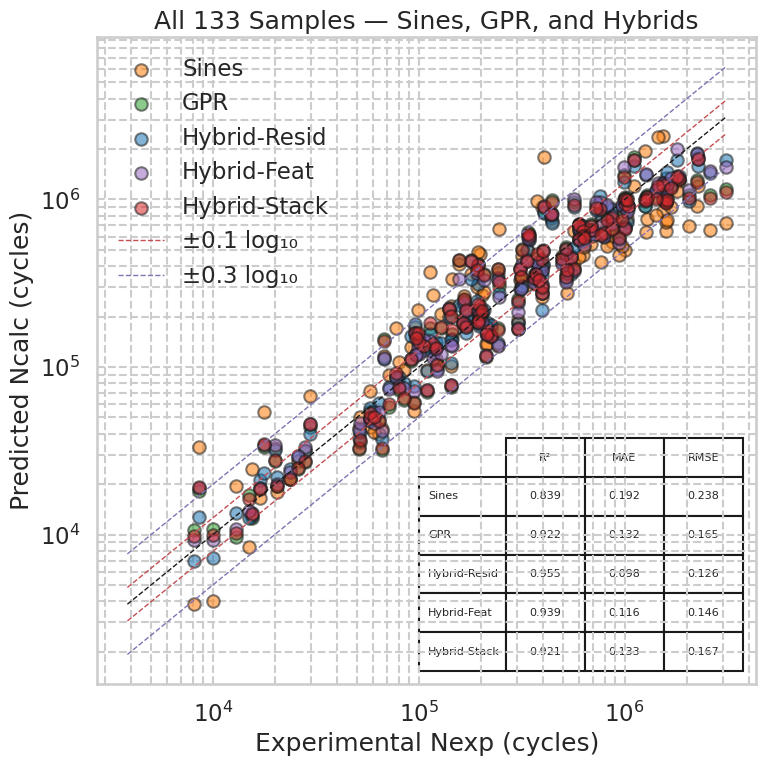

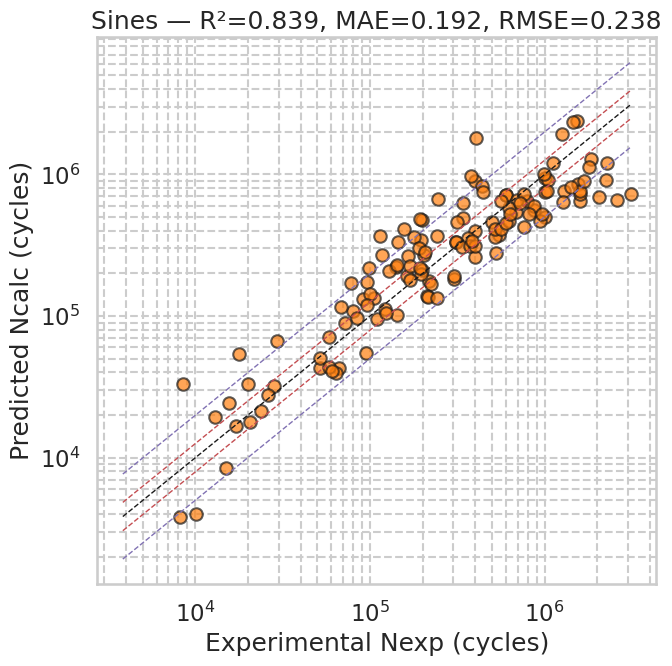

Sines metrics (log10-space):
  R²   = 0.839
  MAE  = 0.192
  RMSE = 0.238
----------------------------------------


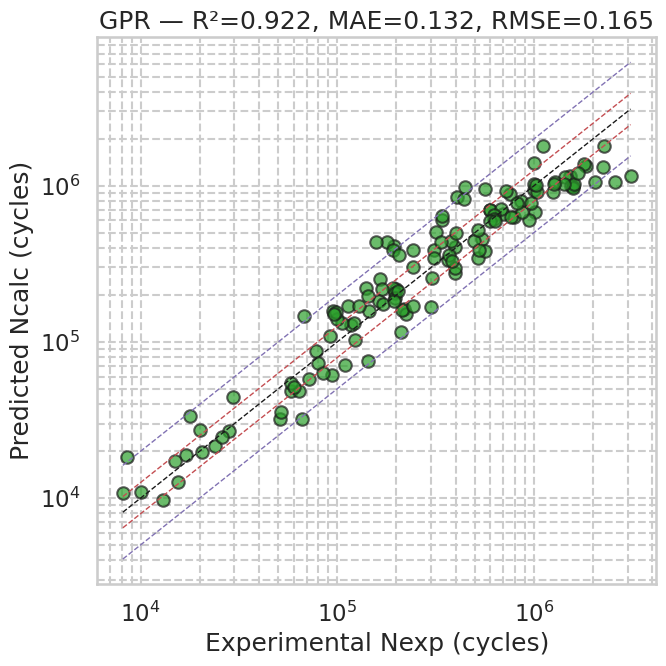

GPR metrics (log10-space):
  R²   = 0.922
  MAE  = 0.132
  RMSE = 0.165
----------------------------------------


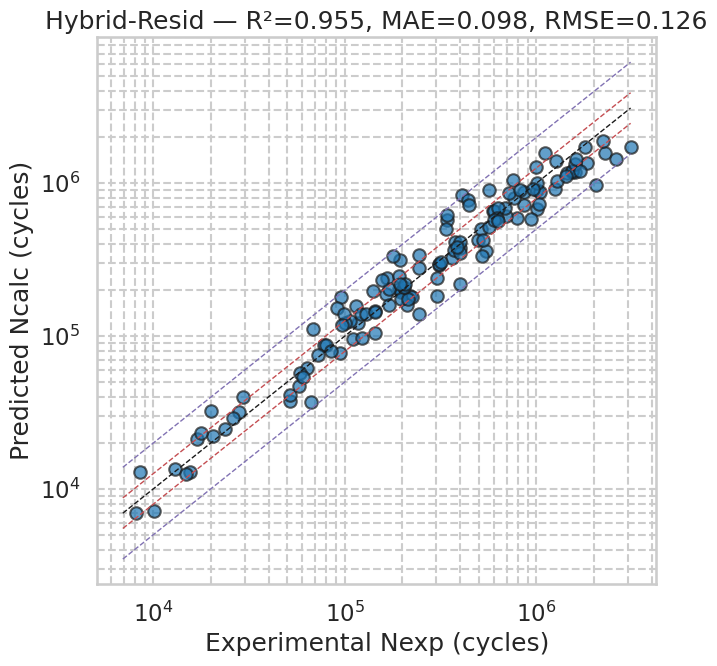

Hybrid-Resid metrics (log10-space):
  R²   = 0.955
  MAE  = 0.098
  RMSE = 0.126
----------------------------------------


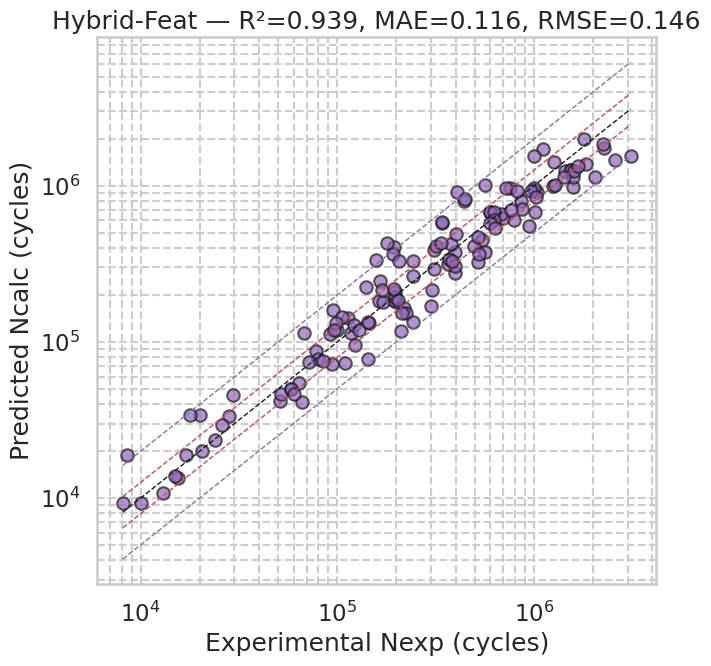

Hybrid-Feat metrics (log10-space):
  R²   = 0.939
  MAE  = 0.116
  RMSE = 0.146
----------------------------------------


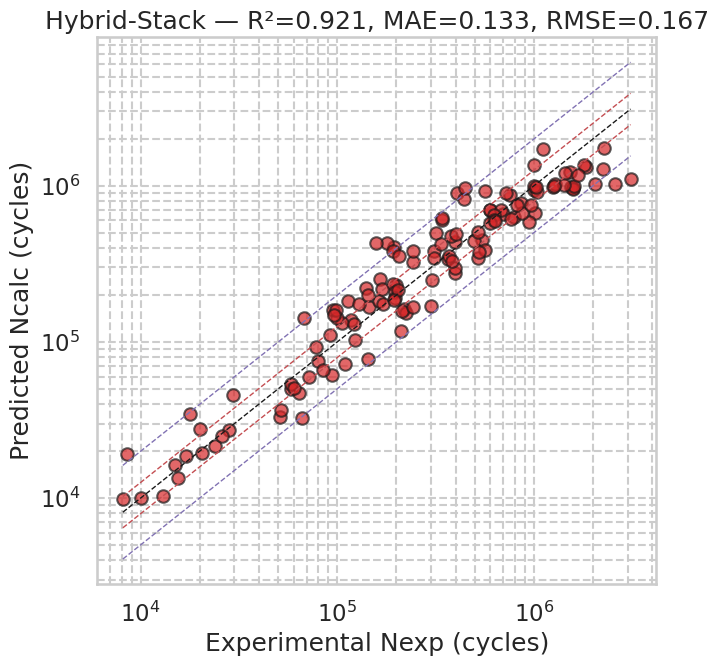

Hybrid-Stack metrics (log10-space):
  R²   = 0.921
  MAE  = 0.133
  RMSE = 0.167
----------------------------------------


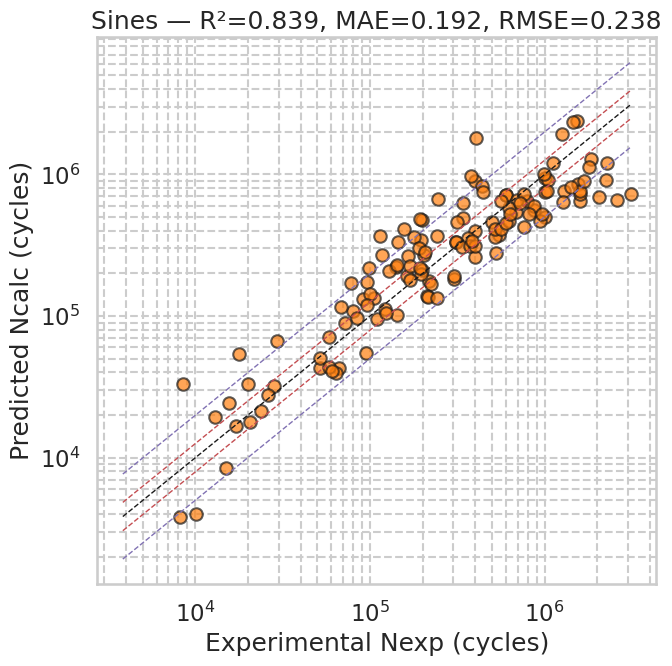

Sines metrics (log10-space):
  R²   = 0.839
  MAE  = 0.192
  RMSE = 0.238
----------------------------------------


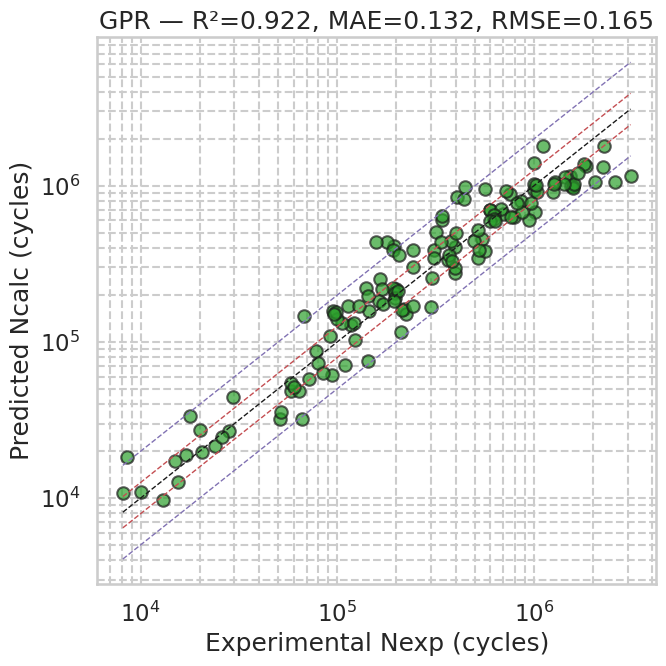

GPR metrics (log10-space):
  R²   = 0.922
  MAE  = 0.132
  RMSE = 0.165
----------------------------------------


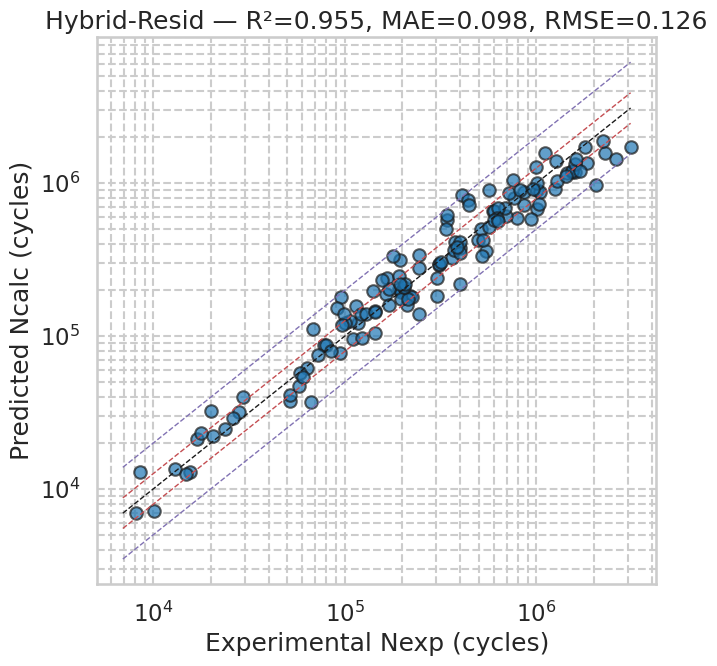

Hybrid-Resid metrics (log10-space):
  R²   = 0.955
  MAE  = 0.098
  RMSE = 0.126
----------------------------------------


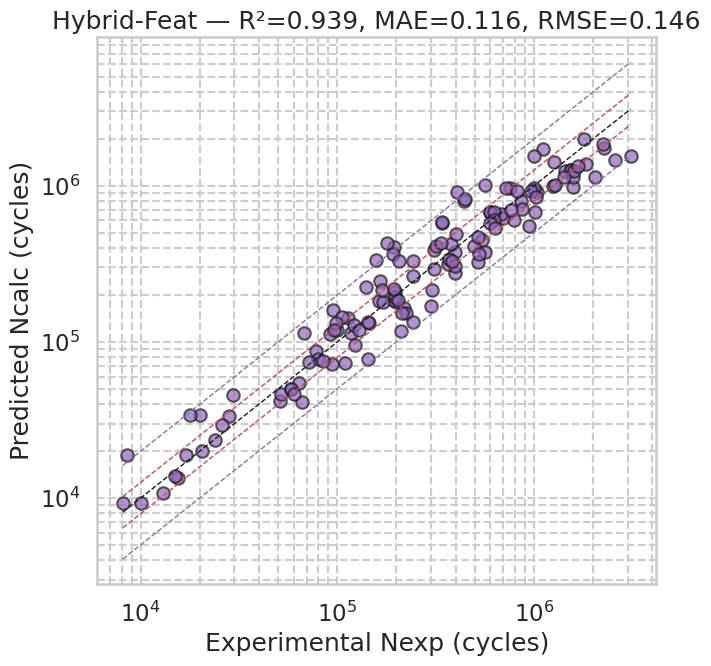

Hybrid-Feat metrics (log10-space):
  R²   = 0.939
  MAE  = 0.116
  RMSE = 0.146
----------------------------------------


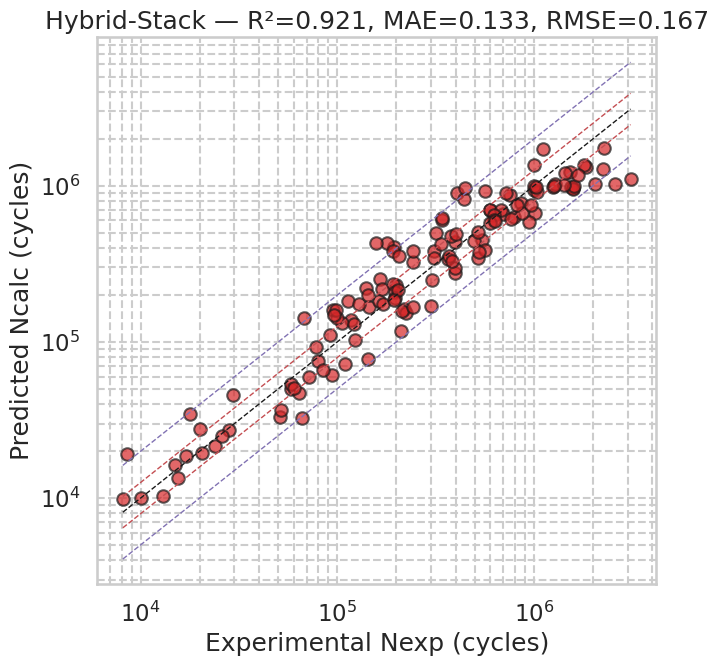

Hybrid-Stack metrics (log10-space):
  R²   = 0.921
  MAE  = 0.133
  RMSE = 0.167
----------------------------------------


In [31]:
# -----------------------------
# Metrics
# -----------------------------
met_sines   = get_metrics(y_all, s_pred)
met_gpr     = get_metrics(y_all, g_pred)
met_h_resid = get_metrics(y_all, hyb_resid)
met_h_feat  = get_metrics(y_all, hyb_feat)
met_h_stack = get_metrics(y_all, hyb_stack)

print(f"\nWeights: OOF-stacked w* (GPR share) = {w_star:.3f}")
print("\nMetrics (log10-space, all 133 samples):")
print(f"Sines        — R²={met_sines[0]:.3f}, MAE={met_sines[1]:.3f}, RMSE={met_sines[2]:.3f}")
print(f"GPR          — R²={met_gpr[0]:.3f}, MAE={met_gpr[1]:.3f}, RMSE={met_gpr[2]:.3f}")
print(f"Hybrid-Resid — R²={met_h_resid[0]:.3f}, MAE={met_h_resid[1]:.3f}, RMSE={met_h_resid[2]:.3f}")
print(f"Hybrid-Feat  — R²={met_h_feat[0]:.3f}, MAE={met_h_feat[1]:.3f}, RMSE={met_h_feat[2]:.3f}")
print(f"Hybrid-Stack — R²={met_h_stack[0]:.3f}, MAE={met_h_stack[1]:.3f}, RMSE={met_h_stack[2]:.3f}")

# -----------------------------
# Combined plot (all samples)
# -----------------------------
N_true   = 10**y_all
N_sines  = 10**s_pred
N_gpr    = 10**g_pred
N_hresid = 10**hyb_resid
N_hfeat  = 10**hyb_feat
N_hstack = 10**hyb_stack

plt.figure(figsize=(8,8))
plt.scatter(N_true, N_sines,  c='tab:orange', alpha=0.55, edgecolors='k', label='Sines')
plt.scatter(N_true, N_gpr,    c='tab:green',  alpha=0.55, edgecolors='k', label='GPR')
plt.scatter(N_true, N_hresid, c='tab:blue',   alpha=0.55, edgecolors='k', label='Hybrid-Resid')
plt.scatter(N_true, N_hfeat,  c='tab:purple', alpha=0.55, edgecolors='k', label='Hybrid-Feat')
plt.scatter(N_true, N_hstack, c='tab:red',    alpha=0.55, edgecolors='k', label='Hybrid-Stack')

lims = [min(N_true.min(), N_sines.min(), N_gpr.min(), N_hresid.min(), N_hfeat.min(), N_hstack.min()),
        max(N_true.max(), N_sines.max(), N_gpr.max(), N_hresid.max(), N_hfeat.max(), N_hstack.max())]
plt.plot(lims, lims, 'k--', lw=1)

# ±0.1 and ±0.3 log10 bands (~×1.26 and ×2)
f01, f03 = 10**0.1, 10**0.3
plt.plot(lims, [x*f01 for x in lims], 'r--', lw=1, label='±0.1 log₁₀')
plt.plot(lims, [x/f01 for x in lims], 'r--', lw=1)
plt.plot(lims, [x*f03 for x in lims], 'm--', lw=1, label='±0.3 log₁₀')
plt.plot(lims, [x/f03 for x in lims], 'm--', lw=1)

plt.xscale('log'); plt.yscale('log')
plt.xlabel("Experimental Nexp (cycles)")
plt.ylabel("Predicted Ncalc (cycles)")
plt.title("All 133 Samples — Sines, GPR, and Hybrids")
plt.grid(True, which="both", ls="--")
plt.legend(loc='upper left')

# Metrics table (bottom right)
cell_text = [
    [f"{met_sines[0]:.3f}",   f"{met_sines[1]:.3f}",   f"{met_sines[2]:.3f}"],
    [f"{met_gpr[0]:.3f}",     f"{met_gpr[1]:.3f}",     f"{met_gpr[2]:.3f}"],
    [f"{met_h_resid[0]:.3f}", f"{met_h_resid[1]:.3f}", f"{met_h_resid[2]:.3f}"],
    [f"{met_h_feat[0]:.3f}",  f"{met_h_feat[1]:.3f}",  f"{met_h_feat[2]:.3f}"],
    [f"{met_h_stack[0]:.3f}", f"{met_h_stack[1]:.3f}", f"{met_h_stack[2]:.3f}"]
]
rows = ["Sines", "GPR", "Hybrid-Resid", "Hybrid-Feat", "Hybrid-Stack"]
cols = ["R²", "MAE", "RMSE"]
tbl = plt.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
                loc='lower right', cellLoc='center', colWidths=[0.12]*3)
# shrink table font for readability
for key, cell in tbl.get_celld().items():
    cell.set_height(0.06)
    cell.set_fontsize(8)

plt.tight_layout()
plt.show()


# -----------------------------
# Helper: single-model plotting + metrics
# -----------------------------
def plot_model(name, N_true, N_pred, metrics, color='tab:blue'):
    r2, mae, rmse = metrics
    plt.figure(figsize=(7,7))
    plt.scatter(N_true, N_pred, c=color, alpha=0.7, edgecolors='k')

    # 1:1 line
    lims = [min(N_true.min(), N_pred.min()), max(N_true.max(), N_pred.max())]
    plt.plot(lims, lims, 'k--', lw=1)

    # ±0.1 and ±0.3 log10 bands
    f01, f03 = 10**0.1, 10**0.3
    plt.plot(lims, [x*f01 for x in lims], 'r--', lw=1)
    plt.plot(lims, [x/f01 for x in lims], 'r--', lw=1)
    plt.plot(lims, [x*f03 for x in lims], 'm--', lw=1)
    plt.plot(lims, [x/f03 for x in lims], 'm--', lw=1)

    plt.xscale('log'); plt.yscale('log')
    plt.xlabel("Experimental Nexp (cycles)")
    plt.ylabel("Predicted Ncalc (cycles)")
    plt.title(f"{name} — R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
    plt.grid(True, which="both", ls="--")
    plt.tight_layout()
    plt.show()

    print(f"{name} metrics (log10-space):")
    print(f"  R²   = {r2:.3f}")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print("-"*40)

# -----------------------------
# Generate separate plots
# -----------------------------
N_true = 10**y_all

plot_model("Sines",         N_true, 10**s_pred,     met_sines,   color='tab:orange')
plot_model("GPR",           N_true, 10**g_pred,     met_gpr,     color='tab:green')
plot_model("Hybrid-Resid",  N_true, 10**hyb_resid,  met_h_resid, color='tab:blue')
plot_model("Hybrid-Feat",   N_true, 10**hyb_feat,   met_h_feat,  color='tab:purple')
plot_model("Hybrid-Stack",  N_true, 10**hyb_stack,  met_h_stack, color='tab:red')



# -----------------------------
# Helper: single-model plotting + metrics
# -----------------------------
def plot_model(name, N_true, N_pred, metrics, color='tab:blue'):
    r2, mae, rmse = metrics
    plt.figure(figsize=(7,7))
    plt.scatter(N_true, N_pred, c=color, alpha=0.7, edgecolors='k')

    # 1:1 line
    lims = [min(N_true.min(), N_pred.min()), max(N_true.max(), N_pred.max())]
    plt.plot(lims, lims, 'k--', lw=1)

    # ±0.1 and ±0.3 log10 bands
    f01, f03 = 10**0.1, 10**0.3
    plt.plot(lims, [x*f01 for x in lims], 'r--', lw=1)
    plt.plot(lims, [x/f01 for x in lims], 'r--', lw=1)
    plt.plot(lims, [x*f03 for x in lims], 'm--', lw=1)
    plt.plot(lims, [x/f03 for x in lims], 'm--', lw=1)

    plt.xscale('log'); plt.yscale('log')
    plt.xlabel("Experimental Nexp (cycles)")
    plt.ylabel("Predicted Ncalc (cycles)")
    plt.title(f"{name} — R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
    plt.grid(True, which="both", ls="--")
    plt.tight_layout()
    plt.show()

    print(f"{name} metrics (log10-space):")
    print(f"  R²   = {r2:.3f}")
    print(f"  MAE  = {mae:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print("-"*40)

# -----------------------------
# Generate separate plots
# -----------------------------
N_true = 10**y_all

plot_model("Sines",         N_true, 10**s_pred,     met_sines,   color='tab:orange')
plot_model("GPR",           N_true, 10**g_pred,     met_gpr,     color='tab:green')
plot_model("Hybrid-Resid",  N_true, 10**hyb_resid,  met_h_resid, color='tab:blue')
plot_model("Hybrid-Feat",   N_true, 10**hyb_feat,   met_h_feat,  color='tab:purple')
plot_model("Hybrid-Stack",  N_true, 10**hyb_stack,  met_h_stack, color='tab:red')

### Fatigue Life Prediction Model Comparison with Comprehensive Uncertainty Quantification

####Description:
This code implements a sophisticated visualization and analysis framework for comparing multiple fatigue life prediction models with integrated uncertainty quantification (UQ). The implementation features:

Core Functionality:
Multi-model comparison of five prediction approaches: Sines (physics-based), Gaussian Process Regression (GPR), and three hybrid variants (Residual-learning, Feature-augmented, Stacked)

Comprehensive uncertainty quantification including 95% prediction intervals and coverage analysis

Professional scientific visualization with publication-ready formatting

Key Features:
Uncertainty Quantification System:

Calculates prediction intervals based on residual analysis

Measures actual coverage percentages against expected 95% confidence

Provides uncertainty-aware performance metrics

Advanced Visualization:

Multi-panel figure layout with subplot labeling (a-f) for publication

Confidence ellipses showing data distribution patterns

Prediction interval bands on individual model plots

Dynamic axis scaling for optimal data presentation

Professional Styling:

Custom matplotlib configuration for scientific publications

Consistent color coding across all models

Clear typography with proper mathematical notation

Structured table layouts with color-coded headers

Comprehensive Analysis:

Side-by-side model performance comparison

Individual model deep-dive analysis

Uncertainty summary statistics

Coverage validation for prediction intervals

Technical Implementation:
Uses scikit-learn for PCA-based confidence ellipses

Implements statistical methods for prediction interval calculation

Provides both combined overview and individual model analysis

Includes robustness checks for edge cases

Output:
Plot (a): Combined model comparison with all 133 samples

Plots (b-f): Individual model analyses with uncertainty visualization

Detailed metrics: R², MAE, RMSE plus prediction intervals and coverage

Summary tables: Professional formatting for results presentation


Weights: OOF-stacked w* (GPR share) = 0.917

Metrics with Uncertainty Quantification (log10-space, all 133 samples):
Sines        — R²=0.839, MAE=0.192, RMSE=0.238, 95% PI=±0.467, Coverage=94.7%
GPR          — R²=0.922, MAE=0.132, RMSE=0.165, 95% PI=±0.324, Coverage=94.0%
Hybrid-Resid — R²=0.955, MAE=0.098, RMSE=0.126, 95% PI=±0.246, Coverage=92.5%
Hybrid-Feat  — R²=0.939, MAE=0.116, RMSE=0.146, 95% PI=±0.286, Coverage=95.5%
Hybrid-Stack — R²=0.921, MAE=0.133, RMSE=0.167, 95% PI=±0.327, Coverage=94.7%


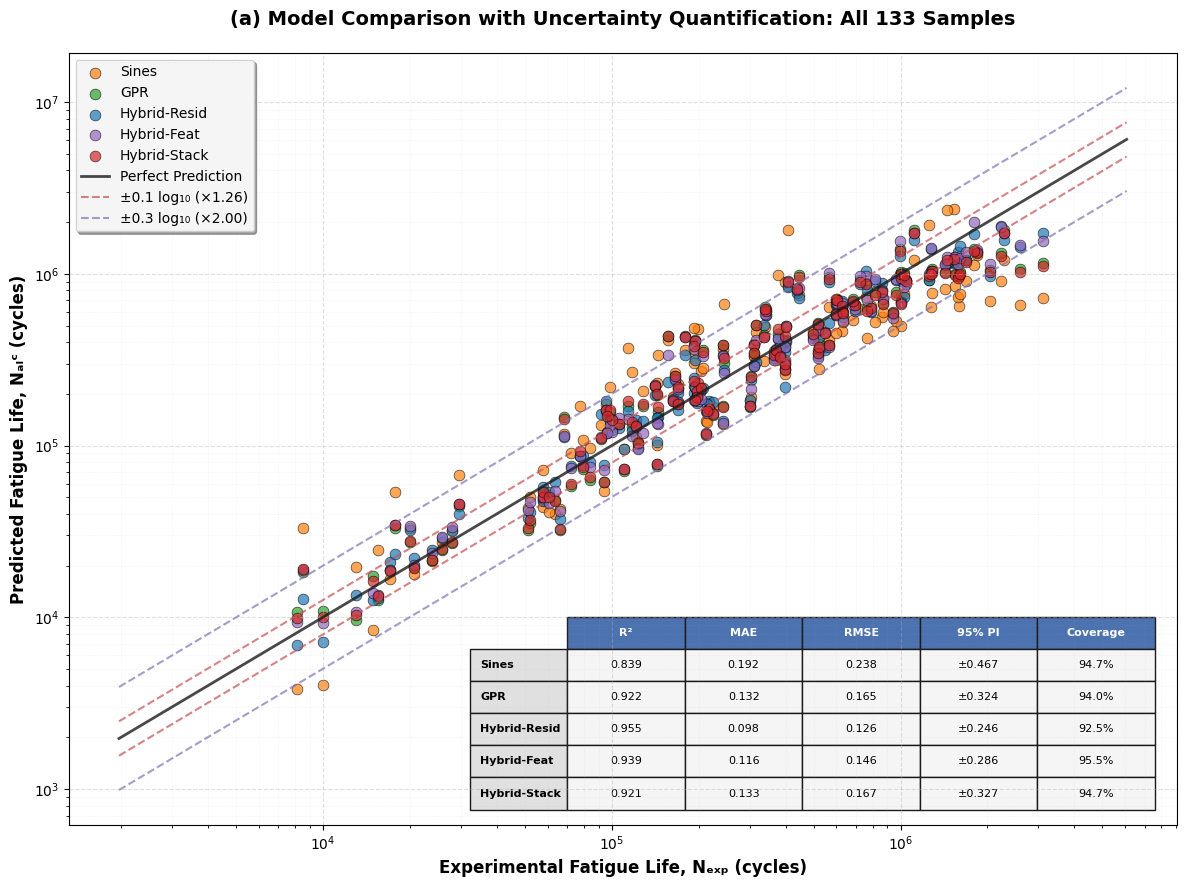


INDIVIDUAL MODEL PLOTS WITH UNCERTAINTY QUANTIFICATION


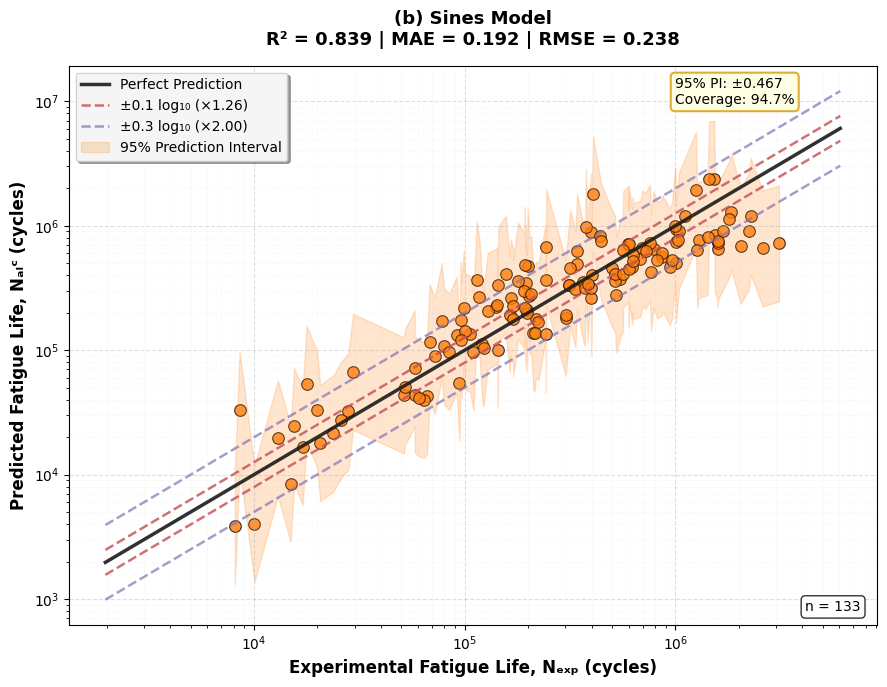

Sines Model metrics with UQ (log10-space):
  R²        = 0.839
  MAE       = 0.192
  RMSE      = 0.238
  95% PI    = ±0.467
  Coverage  = 94.7%
-------------------------------------------------------


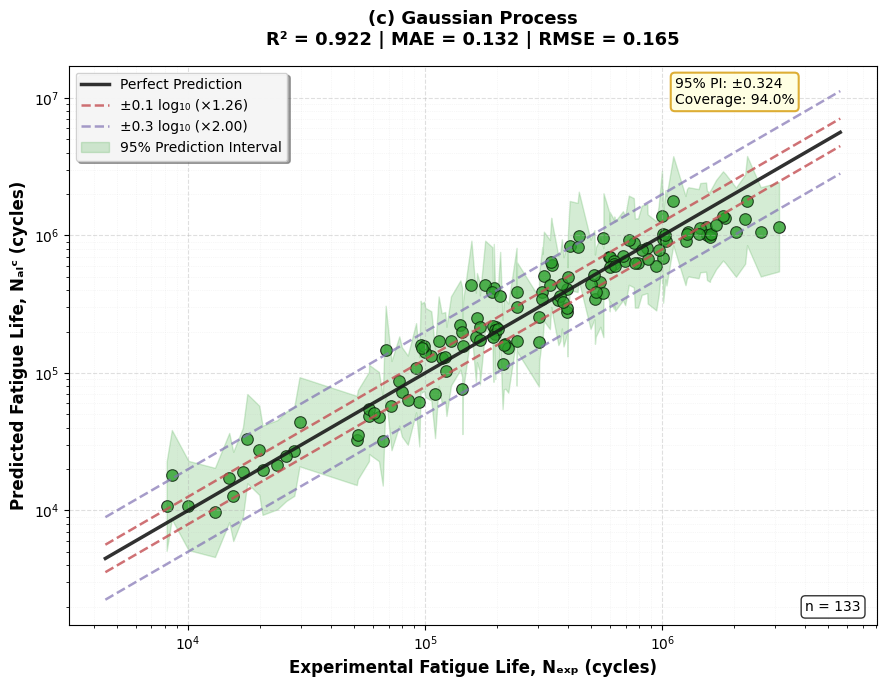

Gaussian Process metrics with UQ (log10-space):
  R²        = 0.922
  MAE       = 0.132
  RMSE      = 0.165
  95% PI    = ±0.324
  Coverage  = 94.0%
-------------------------------------------------------


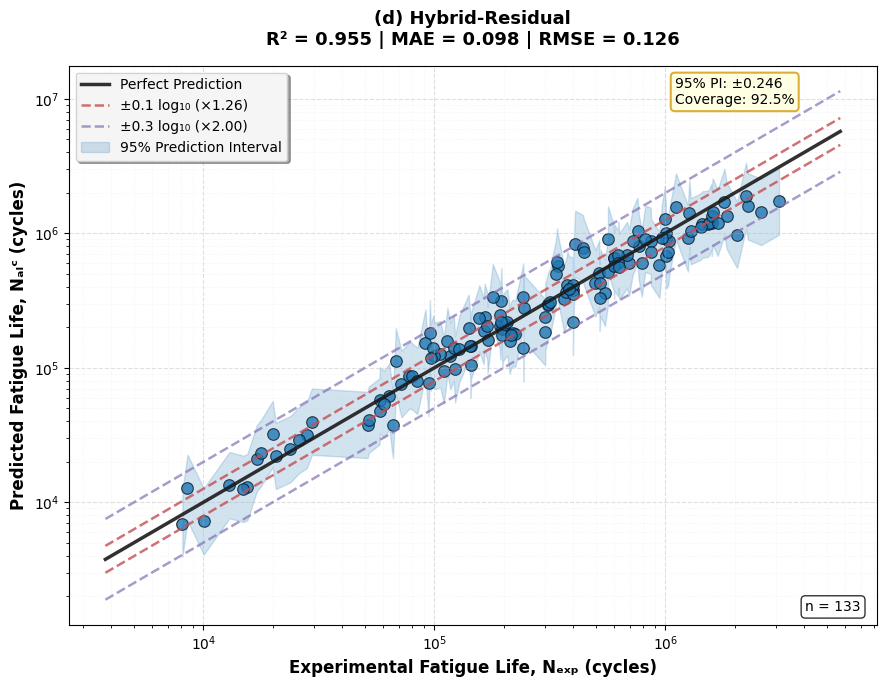

Hybrid-Residual metrics with UQ (log10-space):
  R²        = 0.955
  MAE       = 0.098
  RMSE      = 0.126
  95% PI    = ±0.246
  Coverage  = 92.5%
-------------------------------------------------------


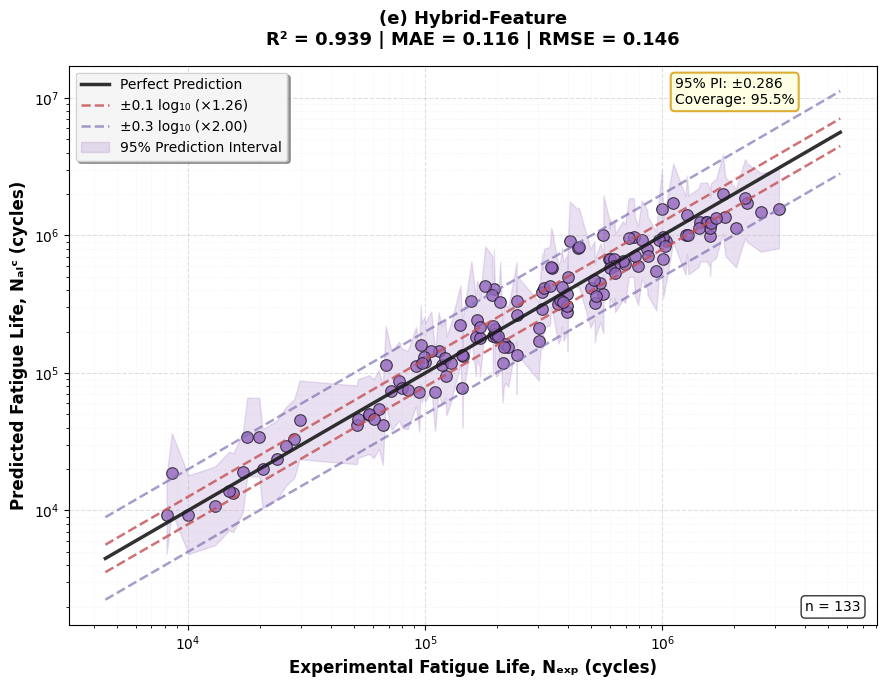

Hybrid-Feature metrics with UQ (log10-space):
  R²        = 0.939
  MAE       = 0.116
  RMSE      = 0.146
  95% PI    = ±0.286
  Coverage  = 95.5%
-------------------------------------------------------


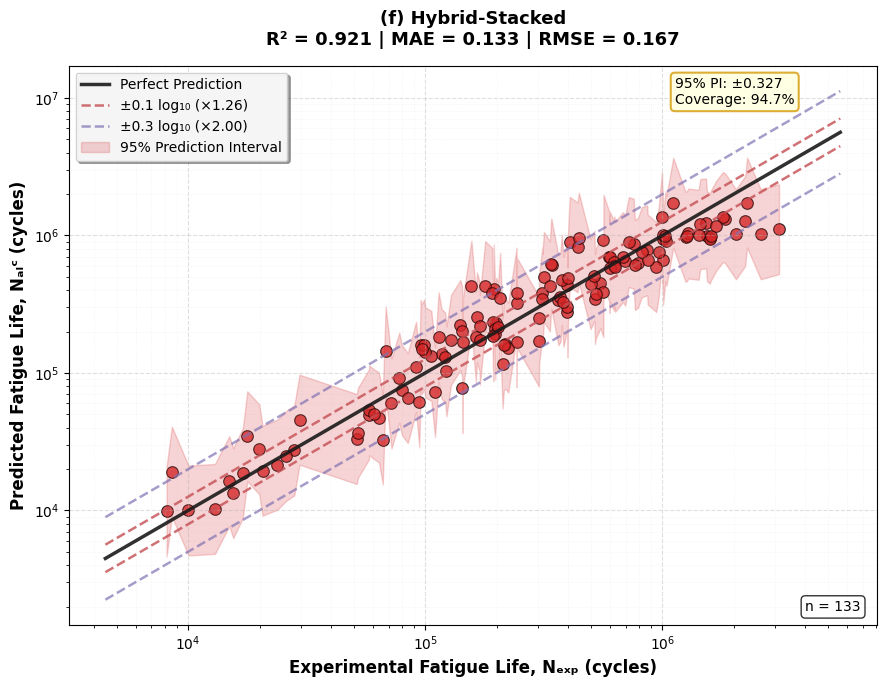

Hybrid-Stacked metrics with UQ (log10-space):
  R²        = 0.921
  MAE       = 0.133
  RMSE      = 0.167
  95% PI    = ±0.327
  Coverage  = 94.7%
-------------------------------------------------------

UNCERTAINTY QUANTIFICATION SUMMARY
Model           95% PI   Coverage   RMSE     PI/RMSE 
-------------------------------------------------------
Sines           ±0.467  94.7%     0.238   1.96   
GPR             ±0.324  94.0%     0.165   1.96   
Hybrid-Resid    ±0.246  92.5%     0.126   1.96   
Hybrid-Feat     ±0.286  95.5%     0.146   1.96   
Hybrid-Stack    ±0.327  94.7%     0.167   1.96   


In [32]:
# -----------------------------
# Plot Configuration with UQ
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# Set professional styling
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'DejaVu Sans',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 1.5,
})

# -----------------------------
# UQ Helper Functions
# -----------------------------
def calculate_prediction_intervals(y_true, y_pred, confidence=0.95):
    """
    Calculate prediction intervals for uncertainty quantification
    """
    residuals = y_pred - y_true
    rmse = np.sqrt(np.mean(residuals**2))

    # For normal distribution, z-score for given confidence
    from scipy import stats
    z_score = stats.norm.ppf((1 + confidence) / 2)

    prediction_interval = z_score * rmse
    coverage = np.mean(np.abs(residuals) <= prediction_interval)

    return prediction_interval, coverage, residuals

def add_uncertainty_annotation(ax, pi_value, coverage, x_pos=0.75, y_pos=0.98):
    """
    Add uncertainty annotation to plot - positioned on right side
    """
    text = f"95% PI: ±{pi_value:.3f}\nCoverage: {coverage:.1%}"
    ax.text(x_pos, y_pos, text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9,
                     edgecolor='goldenrod', linewidth=1.5))

def plot_confidence_ellipses(ax, x_data, y_data, color, alpha=0.3):
    """
    Add confidence ellipses to show data distribution
    """
    try:
        from sklearn.decomposition import PCA
        from scipy.stats import chi2

        data = np.column_stack([np.log10(x_data), np.log10(y_data)])
        pca = PCA(n_components=2)
        pca.fit(data)

        # Calculate ellipse parameters
        center = np.mean(data, axis=0)
        width = 2 * np.sqrt(chi2.ppf(0.95, 2) * pca.explained_variance_[0])
        height = 2 * np.sqrt(chi2.ppf(0.95, 2) * pca.explained_variance_[1])
        angle = np.degrees(np.arctan2(pca.components_[0, 1], pca.components_[0, 0]))

        # Convert back to linear scale for plotting
        center_linear = 10**center

        # Create ellipse in linear space (approximation)
        ellipse = Ellipse(center_linear, width=center_linear[0]*0.5, height=center_linear[1]*0.3,
                         angle=angle, fill=True, alpha=alpha, color=color, linestyle='--', linewidth=1)
        ax.add_patch(ellipse)
    except:
        pass  # Skip if PCA fails

# -----------------------------
# Metrics with UQ
# -----------------------------
met_sines   = get_metrics(y_all, s_pred)
met_gpr     = get_metrics(y_all, g_pred)
met_h_resid = get_metrics(y_all, hyb_resid)
met_h_feat  = get_metrics(y_all, hyb_feat)
met_h_stack = get_metrics(y_all, hyb_stack)

# Calculate prediction intervals for each model
pi_sines, cov_sines, _ = calculate_prediction_intervals(y_all, s_pred)
pi_gpr, cov_gpr, _ = calculate_prediction_intervals(y_all, g_pred)
pi_h_resid, cov_h_resid, _ = calculate_prediction_intervals(y_all, hyb_resid)
pi_h_feat, cov_h_feat, _ = calculate_prediction_intervals(y_all, hyb_feat)
pi_h_stack, cov_h_stack, _ = calculate_prediction_intervals(y_all, hyb_stack)

print(f"\nWeights: OOF-stacked w* (GPR share) = {w_star:.3f}")
print("\nMetrics with Uncertainty Quantification (log10-space, all 133 samples):")
print(f"Sines        — R²={met_sines[0]:.3f}, MAE={met_sines[1]:.3f}, RMSE={met_sines[2]:.3f}, 95% PI=±{pi_sines:.3f}, Coverage={cov_sines:.1%}")
print(f"GPR          — R²={met_gpr[0]:.3f}, MAE={met_gpr[1]:.3f}, RMSE={met_gpr[2]:.3f}, 95% PI=±{pi_gpr:.3f}, Coverage={cov_gpr:.1%}")
print(f"Hybrid-Resid — R²={met_h_resid[0]:.3f}, MAE={met_h_resid[1]:.3f}, RMSE={met_h_resid[2]:.3f}, 95% PI=±{pi_h_resid:.3f}, Coverage={cov_h_resid:.1%}")
print(f"Hybrid-Feat  — R²={met_h_feat[0]:.3f}, MAE={met_h_feat[1]:.3f}, RMSE={met_h_feat[2]:.3f}, 95% PI=±{pi_h_feat:.3f}, Coverage={cov_h_feat:.1%}")
print(f"Hybrid-Stack — R²={met_h_stack[0]:.3f}, MAE={met_h_stack[1]:.3f}, RMSE={met_h_stack[2]:.3f}, 95% PI=±{pi_h_stack:.3f}, Coverage={cov_h_stack:.1%}")

# -----------------------------
# Combined plot with UQ (all samples) - Plot (a)
# -----------------------------
N_true   = 10**y_all
N_sines  = 10**s_pred
N_gpr    = 10**g_pred
N_hresid = 10**hyb_resid
N_hfeat  = 10**hyb_feat
N_hstack = 10**hyb_stack

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(12, 9))

# Scatter plots with UQ visualization
scatter_kwargs = {
    'alpha': 0.7,
    'edgecolors': 'black',
    'linewidth': 0.5,
    's': 60
}

# Plot with confidence ellipses
models_data = [
    (N_sines, 'tab:orange', 'Sines', pi_sines, cov_sines),
    (N_gpr, 'tab:green', 'GPR', pi_gpr, cov_gpr),
    (N_hresid, 'tab:blue', 'Hybrid-Resid', pi_h_resid, cov_h_resid),
    (N_hfeat, 'tab:purple', 'Hybrid-Feat', pi_h_feat, cov_h_feat),
    (N_hstack, 'tab:red', 'Hybrid-Stack', pi_h_stack, cov_h_stack)
]

for N_pred, color, label, pi, cov in models_data:
    ax.scatter(N_true, N_pred, c=color, label=label, **scatter_kwargs)
    # (Ellipse removed)
    # plot_confidence_ellipses(ax, N_true, N_pred, color, alpha=0.2)

# Calculate dynamic limits
all_values = np.concatenate([N_true, N_sines, N_gpr, N_hresid, N_hfeat, N_hstack])
min_val = np.min(all_values)
max_val = np.max(all_values)
margin = 0.1
log_min = np.log10(min_val)
log_max = np.log10(max_val)
log_range = log_max - log_min
lims = [10**(log_min - margin * log_range), 10**(log_max + margin * log_range)]

# 1:1 line
ax.plot(lims, lims, 'k-', lw=2, alpha=0.8, label='Perfect Prediction')

# ±0.1 and ±0.3 log10 bands with UQ context
f01, f03 = 10**0.1, 10**0.3
ax.plot(lims, [x*f01 for x in lims], 'r--', lw=1.5, alpha=0.7, label='±0.1 log₁₀ (×1.26)')
ax.plot(lims, [x/f01 for x in lims], 'r--', lw=1.5, alpha=0.7)
ax.plot(lims, [x*f03 for x in lims], 'm--', lw=1.5, alpha=0.7, label='±0.3 log₁₀ (×2.00)')
ax.plot(lims, [x/f03 for x in lims], 'm--', lw=1.5, alpha=0.7)

# Axes and labels
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Experimental Fatigue Life, Nₑₓₚ (cycles)", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted Fatigue Life, Nₐₗᶜ (cycles)", fontsize=12, fontweight='bold')
ax.set_title("(a) Model Comparison with Uncertainty Quantification: All 133 Samples",
             fontsize=14, fontweight='bold', pad=20)

# Grid
ax.grid(True, which='major', linestyle='--', alpha=0.4, linewidth=0.8)
ax.grid(True, which='minor', linestyle=':', alpha=0.2, linewidth=0.5)

# Legend - positioned on left side
ax.legend(loc='upper left', framealpha=0.9, fancybox=True, shadow=True)

# Metrics table with UQ
cell_text = [
    [f"{met_sines[0]:.3f}", f"{met_sines[1]:.3f}", f"{met_sines[2]:.3f}", f"±{pi_sines:.3f}", f"{cov_sines:.1%}"],
    [f"{met_gpr[0]:.3f}", f"{met_gpr[1]:.3f}", f"{met_gpr[2]:.3f}", f"±{pi_gpr:.3f}", f"{cov_gpr:.1%}"],
    [f"{met_h_resid[0]:.3f}", f"{met_h_resid[1]:.3f}", f"{met_h_resid[2]:.3f}", f"±{pi_h_resid:.3f}", f"{cov_h_resid:.1%}"],
    [f"{met_h_feat[0]:.3f}", f"{met_h_feat[1]:.3f}", f"{met_h_feat[2]:.3f}", f"±{pi_h_feat:.3f}", f"{cov_h_feat:.1%}"],
    [f"{met_h_stack[0]:.3f}", f"{met_h_stack[1]:.3f}", f"{met_h_stack[2]:.3f}", f"±{pi_h_stack:.3f}", f"{cov_h_stack:.1%}"]
]
rows = ["Sines", "GPR", "Hybrid-Resid", "Hybrid-Feat", "Hybrid-Stack"]
cols = ["R²", "MAE", "RMSE", "95% PI", "Coverage"]

# Create table with styling
tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
                loc='lower right', cellLoc='center',
                bbox=[0.45, 0.02, 0.53, 0.25])

# Table styling
for key, cell in tbl.get_celld().items():
    cell.set_height(0.07)
    cell.set_fontsize(8)
    cell.set_text_props(weight='normal')
    if key[0] == 0:  # Header row
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', weight='bold')
    elif key[1] < 0:  # Row labels
        cell.set_facecolor('#E0E0E0')
        cell.set_text_props(weight='bold')
    else:  # Data cells
        cell.set_facecolor('#F5F5F5')

plt.tight_layout()
plt.show()

# -----------------------------
# Helper: single-model plotting + metrics with UQ
# -----------------------------
def plot_model(name, plot_letter, N_true, N_pred, metrics, pi_value, coverage, color='tab:blue'):
    r2, mae, rmse = metrics

    # Create figure with better proportions
    fig, ax = plt.subplots(figsize=(9, 7))

    # Scatter plot
    scatter = ax.scatter(N_true, N_pred, c=color, alpha=0.8,
                        edgecolors='black', linewidth=0.8, s=70)

    # Calculate dynamic limits
    all_vals = np.concatenate([N_true, N_pred])
    min_val = np.min(all_vals)
    max_val = np.max(all_vals)
    margin = 0.1
    log_min = np.log10(min_val)
    log_max = np.log10(max_val)
    log_range = log_max - log_min
    lims = [10**(log_min - margin * log_range), 10**(log_max + margin * log_range)]

    # 1:1 line
    ax.plot(lims, lims, 'k-', lw=2.5, alpha=0.9, label='Perfect Prediction')

    # ±0.1 and ±0.3 log10 bands
    f01, f03 = 10**0.1, 10**0.3
    ax.plot(lims, [x*f01 for x in lims], 'r--', lw=1.8, alpha=0.8, label='±0.1 log₁₀ (×1.26)')
    ax.plot(lims, [x/f01 for x in lims], 'r--', lw=1.8, alpha=0.8)
    ax.plot(lims, [x*f03 for x in lims], 'm--', lw=1.8, alpha=0.7, label='±0.3 log₁₀ (×2.00)')
    ax.plot(lims, [x/f03 for x in lims], 'm--', lw=1.8, alpha=0.7)

    # Add prediction interval bands (UQ visualization)
    pi_upper = 10**(np.log10(N_pred) + pi_value)
    pi_lower = 10**(np.log10(N_pred) - pi_value)

    # Sort for clean plotting
    sort_idx = np.argsort(N_true)
    N_true_sorted = N_true[sort_idx]
    pi_upper_sorted = pi_upper[sort_idx]
    pi_lower_sorted = pi_lower[sort_idx]

    ax.fill_between(N_true_sorted, pi_lower_sorted, pi_upper_sorted,
                   alpha=0.2, color=color, label='95% Prediction Interval')

    # Axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Experimental Fatigue Life, Nₑₓₚ (cycles)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Predicted Fatigue Life, Nₐₗᶜ (cycles)", fontsize=12, fontweight='bold')

    # Title with plot letter and metrics
    ax.set_title(f"({plot_letter}) {name}\nR² = {r2:.3f} | MAE = {mae:.3f} | RMSE = {rmse:.3f}",
                fontsize=13, fontweight='bold', pad=15)

    # Grid
    ax.grid(True, which='major', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.grid(True, which='minor', linestyle=':', alpha=0.2, linewidth=0.5)

    # Legend - positioned on left side
    ax.legend(loc='upper left', framealpha=0.9, fancybox=True, shadow=True)

    # Add UQ annotation - positioned on right side (top-right corner)
    add_uncertainty_annotation(ax, pi_value, coverage, x_pos=0.75, y_pos=0.98)

    # Add sample count annotation
    ax.text(0.98, 0.02, f'n = {len(N_true)}', transform=ax.transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

    print(f"{name} metrics with UQ (log10-space):")
    print(f"  R²        = {r2:.3f}")
    print(f"  MAE       = {mae:.3f}")
    print(f"  RMSE      = {rmse:.3f}")
    print(f"  95% PI    = ±{pi_value:.3f}")
    print(f"  Coverage  = {coverage:.1%}")
    print("-" * 55)

# -----------------------------
# Generate separate plots with UQ - Plots (b) to (f)
# -----------------------------
N_true = 10**y_all

print("\n" + "="*60)
print("INDIVIDUAL MODEL PLOTS WITH UNCERTAINTY QUANTIFICATION")
print("="*60)

# Generate plots with letters (b) through (f)
plot_model("Sines Model", "b", N_true, 10**s_pred, met_sines, pi_sines, cov_sines, color='tab:orange')
plot_model("Gaussian Process", "c", N_true, 10**g_pred, met_gpr, pi_gpr, cov_gpr, color='tab:green')
plot_model("Hybrid-Residual", "d", N_true, 10**hyb_resid, met_h_resid, pi_h_resid, cov_h_resid, color='tab:blue')
plot_model("Hybrid-Feature", "e", N_true, 10**hyb_feat, met_h_feat, pi_h_feat, cov_h_feat, color='tab:purple')
plot_model("Hybrid-Stacked", "f", N_true, 10**hyb_stack, met_h_stack, pi_h_stack, cov_h_stack, color='tab:red')

# -----------------------------
# UQ Summary Statistics
# -----------------------------
print("\n" + "="*60)
print("UNCERTAINTY QUANTIFICATION SUMMARY")
print("="*60)

models_uncertainty = [
    ("Sines", pi_sines, cov_sines, met_sines[2]),
    ("GPR", pi_gpr, cov_gpr, met_gpr[2]),
    ("Hybrid-Resid", pi_h_resid, cov_h_resid, met_h_resid[2]),
    ("Hybrid-Feat", pi_h_feat, cov_h_feat, met_h_feat[2]),
    ("Hybrid-Stack", pi_h_stack, cov_h_stack, met_h_stack[2])
]

print(f"{'Model':<15} {'95% PI':<8} {'Coverage':<10} {'RMSE':<8} {'PI/RMSE':<8}")
print("-" * 55)
for name, pi, cov, rmse in models_uncertainty:
    pi_rmse_ratio = pi / rmse
    print(f"{name:<15} ±{pi:<6.3f} {cov:<9.1%} {rmse:<7.3f} {pi_rmse_ratio:<7.2f}")

In [33]:
# ============================================================
# Fatemi–Socie (FS) critical-plane baseline (stress-based, elastic approx)
# Uses your existing arrays: Sa, Ta, Sm, Tm, y_true = log10(Nexp)
# Required df columns already checked: Sm, Tm, Sa, Ta, Nexp
# ============================================================

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def fs_parameter_from_axial_torsion(
    Sa, Ta, Sm, Tm,
    E=210000.0, nu=0.30,         # MPa (E=210 GPa), Poisson
    sigma_y=355.0,               # MPa (use your material yield if different)
    k=0.5,                       # FS material parameter (can be tuned)
    n_planes=361,                # plane scan resolution (0..180 deg)
    open_only=True               # use max(sigma_n_max, 0) for crack-opening effect
):
    """
    Compute FS damage parameter for combined axial (x) + shear (xy) stress state:
      sigma = [[sigma_x, tau_xy, 0],
               [tau_xy,     0,  0],
               [   0,       0,  0]]

    Amplitude part uses (Sa, Ta), and max normal stress uses (Sm+Sa, Tm+Ta)
    assuming proportional loading (peak at same phase).

    Returns: P_FS per sample (shape: [n_samples])
    """

    Sa = np.asarray(Sa, dtype=float)
    Ta = np.asarray(Ta, dtype=float)
    Sm = np.asarray(Sm, dtype=float)
    Tm = np.asarray(Tm, dtype=float)

    # Shear modulus (MPa)
    G = E / (2.0 * (1.0 + nu))

    # Plane normals in x–y plane: n = [cosθ, sinθ, 0], θ in [0, π)
    theta = np.linspace(0.0, np.pi, int(n_planes), endpoint=True)
    c = np.cos(theta)[None, :]   # shape (1, n_planes)
    s = np.sin(theta)[None, :]
    sin2 = np.sin(2.0 * theta)[None, :]
    c2 = (c ** 2)

    # Helper to compute sigma_n and tau_on_plane for the simplified tensor
    def sigma_n(sigma_x, tau_xy):
        # sigma_n = sigma_x*cos^2θ + tau_xy*sin(2θ)
        return sigma_x * c2 + tau_xy * sin2

    def tau_plane_amp(sigma_x_amp, tau_xy_amp):
        # traction t = sigma * n -> components:
        # t_x = sigma_x*c + tau*s
        # t_y = tau*c
        tx = sigma_x_amp * c + tau_xy_amp * s
        ty = tau_xy_amp * c
        t2 = tx**2 + ty**2
        sn = sigma_n(sigma_x_amp, tau_xy_amp)
        # |tau| = sqrt(|t|^2 - sigma_n^2)
        return np.sqrt(np.maximum(t2 - sn**2, 0.0))

    # --- amplitude shear traction magnitude on plane
    tau_a = tau_plane_amp(Sa[:, None], Ta[:, None])  # (n_samples, n_planes)

    # --- maximum normal stress on plane at peak (mean + amplitude), proportional assumption
    sigma_x_max = (Sm + Sa)[:, None]
    tau_xy_max  = (Tm + Ta)[:, None]
    sigma_n_max = sigma_n(sigma_x_max, tau_xy_max)   # (n_samples, n_planes)

    if open_only:
        sigma_n_max = np.maximum(sigma_n_max, 0.0)

    # Elastic approximation: Δγ/2 ≈ τ_a / G
    gamma_a = tau_a / G

    # FS parameter on each plane
    P = gamma_a * (1.0 + k * (sigma_n_max / sigma_y))

    # Critical plane = max over planes
    P_fs = np.max(P, axis=1)

    # Avoid log10(0)
    return np.maximum(P_fs, 1e-12)

# -----------------------------
# (1) Compute FS parameter
# -----------------------------
# If you want to tune k quickly, see the optional section below.
k_fs = 0.5
P_fs = fs_parameter_from_axial_torsion(Sa, Ta, Sm, Tm, sigma_y=355.0, k=k_fs)

# -----------------------------
# (2) Fit Basquin-like relation: log10(N) = A + B*log10(P_fs)
# -----------------------------
x_fs = np.log10(P_fs)
A_fs, B_fs = np.polyfit(x_fs, y_true, 1)[1], np.polyfit(x_fs, y_true, 1)[0]
y_pred_fs = A_fs + B_fs * x_fs

# -----------------------------
# (3) Metrics (log-space)
# -----------------------------
R2  = r2_score(y_true, y_pred_fs)
MSE = mean_squared_error(y_true, y_pred_fs)
MAE = mean_absolute_error(y_true, y_pred_fs)

print("=== FS Baseline (Fatemi–Socie, elastic approx) ===")
print(f"k = {k_fs}")
print(f"A_fs = {A_fs:.4f}, B_fs = {B_fs:.4f}")
print(f"R² = {R2:.4f}, MSE = {MSE:.4f}, MAE = {MAE:.4f}")

# -----------------------------
# (Optional) Quick tune k by grid-search (min MAE)
# -----------------------------
# ks = np.linspace(0.0, 1.5, 61)
# best = (None, np.inf, None, None)  # (k, MAE, A, B)
# for kk in ks:
#     P_tmp = fs_parameter_from_axial_torsion(Sa, Ta, Sm, Tm, sigma_y=355.0, k=kk)
#     x_tmp = np.log10(P_tmp)
#     m, b = np.polyfit(x_tmp, y_true, 1)     # y = m*x + b
#     yhat = b + m*x_tmp
#     mae  = mean_absolute_error(y_true, yhat)
#     if mae < best[1]:
#         best = (kk, mae, b, m)
# print(f"[BEST] k={best[0]:.3f}, MAE={best[1]:.4f}, A={best[2]:.4f}, B={best[3]:.4f}")


=== FS Baseline (Fatemi–Socie, elastic approx) ===
k = 0.5
A_fs = -16.1004, B_fs = -8.6302
R² = 0.7465, MSE = 0.0892, MAE = 0.2425


FS fit: log10(N) = -16.1004 + -8.6302*log10(P_FS)
FS — R²=0.747, MAE=0.242, RMSE=0.299, 95% PI=±0.586, Coverage=94.0%


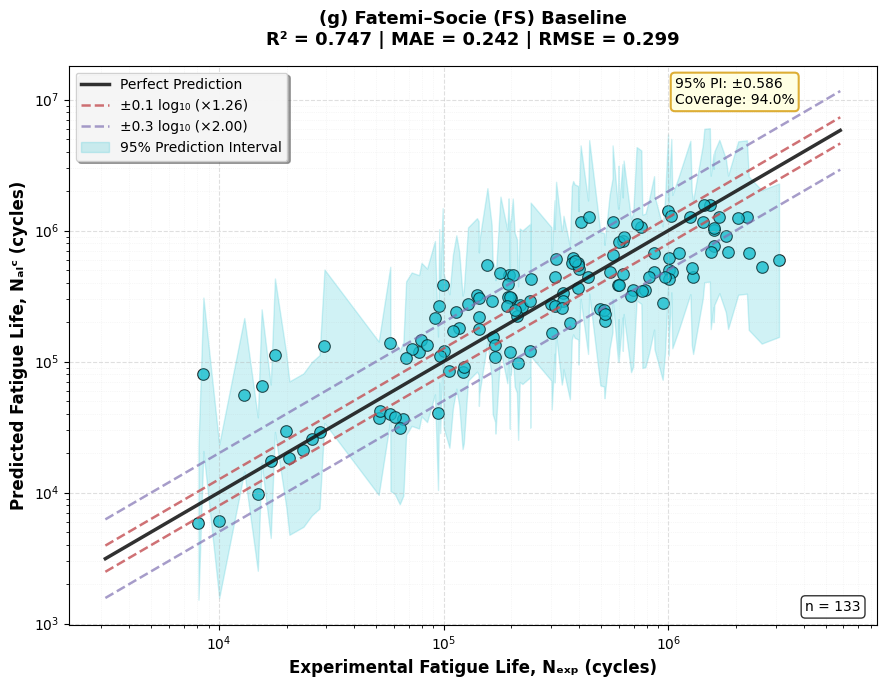

Fatemi–Socie (FS) Baseline metrics with UQ (log10-space):
  R²        = 0.747
  MAE       = 0.242
  RMSE      = 0.299
  95% PI    = ±0.586
  Coverage  = 94.0%
-------------------------------------------------------


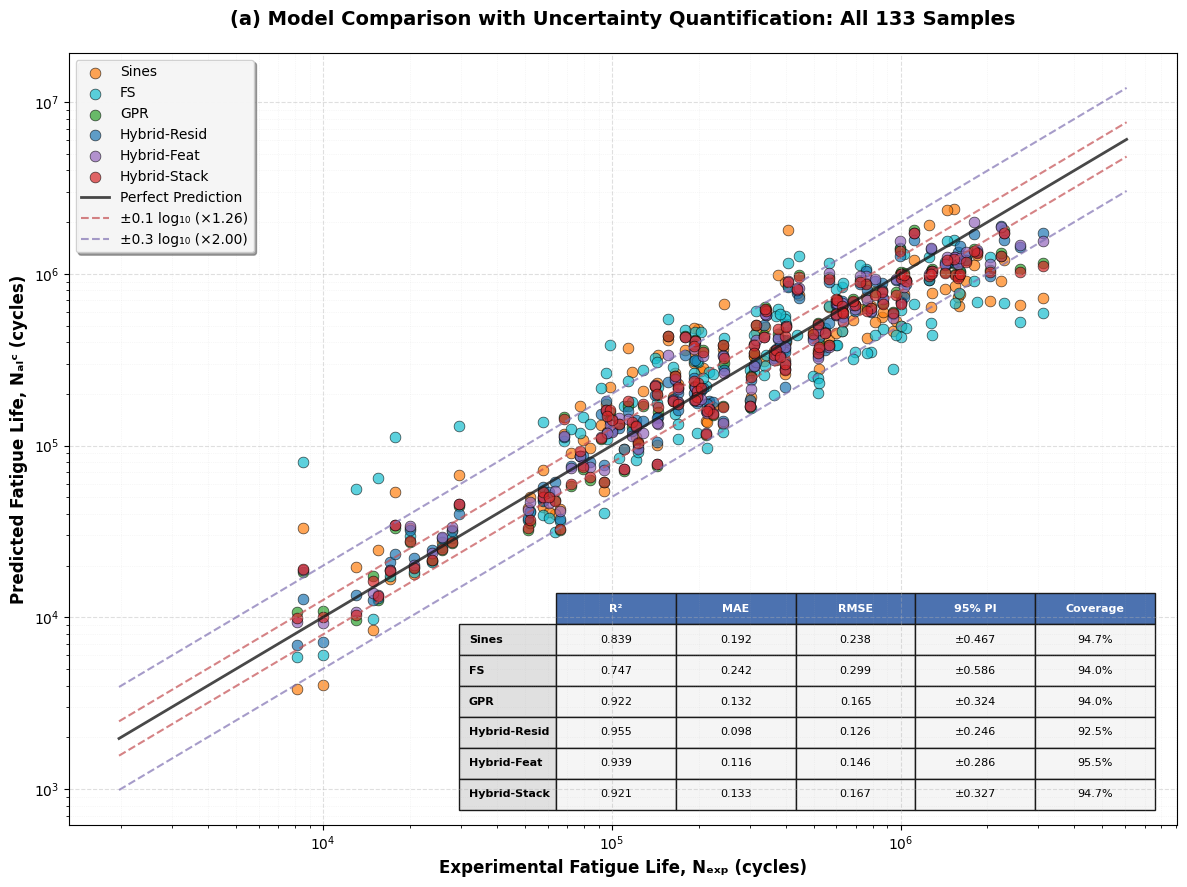

In [34]:
# ============================================================
# FS (Fatemi–Socie) baseline + UQ + plots (same style as yours)
# Assumes your df columns: Sm, Tm, Sa, Ta, Nexp
# y_all = log10(Nexp)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# 1) FS parameter (stress-based, elastic approx)
# -----------------------------
def fs_parameter_from_axial_torsion(
    Sa, Ta, Sm, Tm,
    E=210000.0, nu=0.30,         # MPa (E=210 GPa), Poisson
    sigma_y=355.0,               # MPa (S355 nominal yield; adjust if needed)
    k=0.5,                       # FS material parameter (tunable)
    n_planes=361,
    open_only=True
):
    """
    FS parameter using critical-plane scan in x–y plane for tensor:
      sigma = [[sigma_x, tau_xy, 0],
               [tau_xy,     0,  0],
               [   0,       0,  0]]

    Assumes proportional peak: sigma_x_max = Sm+Sa, tau_max = Tm+Ta.
    Uses elastic approx: (Δγ/2) ≈ τ_a / G.
    """

    Sa = np.asarray(Sa, dtype=float)
    Ta = np.asarray(Ta, dtype=float)
    Sm = np.asarray(Sm, dtype=float)
    Tm = np.asarray(Tm, dtype=float)

    G = E / (2.0 * (1.0 + nu))   # MPa

    theta = np.linspace(0.0, np.pi, int(n_planes), endpoint=True)
    c = np.cos(theta)[None, :]
    s = np.sin(theta)[None, :]
    sin2 = np.sin(2.0 * theta)[None, :]
    c2 = c**2

    def sigma_n(sigma_x, tau_xy):
        return sigma_x * c2 + tau_xy * sin2

    def tau_plane_amp(sigma_x_amp, tau_xy_amp):
        tx = sigma_x_amp * c + tau_xy_amp * s
        ty = tau_xy_amp * c
        t2 = tx**2 + ty**2
        sn = sigma_n(sigma_x_amp, tau_xy_amp)
        return np.sqrt(np.maximum(t2 - sn**2, 0.0))

    # Shear traction amplitude on each plane
    tau_a = tau_plane_amp(Sa[:, None], Ta[:, None])  # (n, n_planes)

    # Max normal stress on each plane at peak (proportional assumption)
    sigma_x_max = (Sm + Sa)[:, None]
    tau_xy_max  = (Tm + Ta)[:, None]
    sigma_n_max = sigma_n(sigma_x_max, tau_xy_max)

    if open_only:
        sigma_n_max = np.maximum(sigma_n_max, 0.0)

    gamma_a = tau_a / G  # Δγ/2 (elastic approx)

    P = gamma_a * (1.0 + k * (sigma_n_max / sigma_y))
    P_fs = np.max(P, axis=1)

    return np.maximum(P_fs, 1e-12)

# Pull stress components from df (same as your notebook)
Sa = df["Sa"].values
Ta = df["Ta"].values
Sm = df["Sm"].values
Tm = df["Tm"].values

# Choose FS parameters (you can tune k later)
k_fs = 0.5
sigma_y_fs = 355.0

P_fs = fs_parameter_from_axial_torsion(Sa, Ta, Sm, Tm, sigma_y=sigma_y_fs, k=k_fs)

# -----------------------------
# 2) Fit Basquin-like mapping: log10(N) = a + b*log10(P_fs)
# -----------------------------
x_fs = np.log10(P_fs).reshape(-1, 1)
fs_reg = LinearRegression().fit(x_fs, y_all)
fs_pred = fs_reg.predict(x_fs)   # predicted log10(N)

print(f"FS fit: log10(N) = {fs_reg.intercept_:.4f} + {fs_reg.coef_[0]:.4f}*log10(P_FS)")

# -----------------------------
# 3) Metrics + UQ (same as your approach)
# -----------------------------
met_fs = get_metrics(y_all, fs_pred)
pi_fs, cov_fs, _ = calculate_prediction_intervals(y_all, fs_pred)

print(f"FS — R²={met_fs[0]:.3f}, MAE={met_fs[1]:.3f}, RMSE={met_fs[2]:.3f}, 95% PI=±{pi_fs:.3f}, Coverage={cov_fs:.1%}")

# -----------------------------
# 4) FS single-model plot (same look as your plot_model)
# -----------------------------
N_true = 10**y_all
N_fs   = 10**fs_pred

plot_model("Fatemi–Socie (FS) Baseline", "g", N_true, N_fs, met_fs, pi_fs, cov_fs, color="tab:cyan")

# -----------------------------
# 5) (Optional) Add FS into your combined comparison plot + table
#    This will work only if these exist: s_pred, g_pred, hyb_resid, hyb_feat, hyb_stack
# -----------------------------
have_others = all(v in globals() for v in ["s_pred", "g_pred", "hyb_resid", "hyb_feat", "hyb_stack"])

if have_others:
    N_sines  = 10**s_pred
    N_gpr    = 10**g_pred
    N_hresid = 10**hyb_resid
    N_hfeat  = 10**hyb_feat
    N_hstack = 10**hyb_stack

    met_sines   = get_metrics(y_all, s_pred)
    met_gpr     = get_metrics(y_all, g_pred)
    met_h_resid = get_metrics(y_all, hyb_resid)
    met_h_feat  = get_metrics(y_all, hyb_feat)
    met_h_stack = get_metrics(y_all, hyb_stack)

    pi_sines, cov_sines, _ = calculate_prediction_intervals(y_all, s_pred)
    pi_gpr, cov_gpr, _ = calculate_prediction_intervals(y_all, g_pred)
    pi_h_resid, cov_h_resid, _ = calculate_prediction_intervals(y_all, hyb_resid)
    pi_h_feat, cov_h_feat, _ = calculate_prediction_intervals(y_all, hyb_feat)
    pi_h_stack, cov_h_stack, _ = calculate_prediction_intervals(y_all, hyb_stack)

    # ----- Combined plot (a) including FS -----
    fig, ax = plt.subplots(figsize=(12, 9))

    scatter_kwargs = dict(alpha=0.7, edgecolors="black", linewidth=0.5, s=60)

    models_data = [
        (N_sines,  "tab:orange", "Sines",        pi_sines,  cov_sines),
        (N_fs,     "tab:cyan",   "FS",           pi_fs,     cov_fs),
        (N_gpr,    "tab:green",  "GPR",          pi_gpr,    cov_gpr),
        (N_hresid, "tab:blue",   "Hybrid-Resid", pi_h_resid,cov_h_resid),
        (N_hfeat,  "tab:purple", "Hybrid-Feat",  pi_h_feat, cov_h_feat),
        (N_hstack, "tab:red",    "Hybrid-Stack", pi_h_stack,cov_h_stack),
    ]

    for N_pred, color, label, pi, cov in models_data:
        ax.scatter(N_true, N_pred, c=color, label=label, **scatter_kwargs)

    all_values = np.concatenate([N_true] + [m[0] for m in models_data])
    min_val, max_val = np.min(all_values), np.max(all_values)
    margin = 0.1
    log_min, log_max = np.log10(min_val), np.log10(max_val)
    lims = [10**(log_min - margin*(log_max-log_min)), 10**(log_max + margin*(log_max-log_min))]

    ax.plot(lims, lims, "k-", lw=2, alpha=0.8, label="Perfect Prediction")

    f01, f03 = 10**0.1, 10**0.3
    ax.plot(lims, [x*f01 for x in lims], "r--", lw=1.5, alpha=0.7, label="±0.1 log₁₀ (×1.26)")
    ax.plot(lims, [x/f01 for x in lims], "r--", lw=1.5, alpha=0.7)
    ax.plot(lims, [x*f03 for x in lims], "m--", lw=1.5, alpha=0.7, label="±0.3 log₁₀ (×2.00)")
    ax.plot(lims, [x/f03 for x in lims], "m--", lw=1.5, alpha=0.7)

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Experimental Fatigue Life, Nₑₓₚ (cycles)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Predicted Fatigue Life, Nₐₗᶜ (cycles)", fontsize=12, fontweight="bold")
    ax.set_title("(a) Model Comparison with Uncertainty Quantification: All 133 Samples",
                 fontsize=14, fontweight="bold", pad=20)

    ax.grid(True, which="major", linestyle="--", alpha=0.4, linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2, linewidth=0.5)
    ax.legend(loc="upper left", framealpha=0.9, fancybox=True, shadow=True)

    # ----- Table including FS -----
    cell_text = [
        [f"{met_sines[0]:.3f}", f"{met_sines[1]:.3f}", f"{met_sines[2]:.3f}", f"±{pi_sines:.3f}", f"{cov_sines:.1%}"],
        [f"{met_fs[0]:.3f}",    f"{met_fs[1]:.3f}",    f"{met_fs[2]:.3f}",    f"±{pi_fs:.3f}",    f"{cov_fs:.1%}"],
        [f"{met_gpr[0]:.3f}",   f"{met_gpr[1]:.3f}",   f"{met_gpr[2]:.3f}",   f"±{pi_gpr:.3f}",   f"{cov_gpr:.1%}"],
        [f"{met_h_resid[0]:.3f}", f"{met_h_resid[1]:.3f}", f"{met_h_resid[2]:.3f}", f"±{pi_h_resid:.3f}", f"{cov_h_resid:.1%}"],
        [f"{met_h_feat[0]:.3f}",  f"{met_h_feat[1]:.3f}",  f"{met_h_feat[2]:.3f}",  f"±{pi_h_feat:.3f}",  f"{cov_h_feat:.1%}"],
        [f"{met_h_stack[0]:.3f}", f"{met_h_stack[1]:.3f}", f"{met_h_stack[2]:.3f}", f"±{pi_h_stack:.3f}", f"{cov_h_stack:.1%}"],
    ]
    rows = ["Sines", "FS", "GPR", "Hybrid-Resid", "Hybrid-Feat", "Hybrid-Stack"]
    cols = ["R²", "MAE", "RMSE", "95% PI", "Coverage"]

    tbl = ax.table(cellText=cell_text, rowLabels=rows, colLabels=cols,
                   loc="lower right", cellLoc="center",
                   bbox=[0.44, 0.02, 0.54, 0.28])

    for key, cell in tbl.get_celld().items():
        cell.set_height(0.07)
        cell.set_fontsize(8)
        if key[0] == 0:
            cell.set_text_props(color="white", weight="bold")
            cell.set_facecolor("#4C72B0")
        elif key[1] < 0:
            cell.set_facecolor("#E0E0E0")
            cell.set_text_props(weight="bold")
        else:
            cell.set_facecolor("#F5F5F5")

    plt.tight_layout()
    plt.show()


[INFO] Figures will be saved to: /content/C:\Users\SURFACE\Desktop\PhD project\3eme anne Doctorant\Article#3\Figures
FS fit: log10(N) = -16.1004 + -8.6302*log10(P_FS)
FS — R²=0.747, MAE=0.242, RMSE=0.299, 95% PI=±0.586, Coverage=94.0%


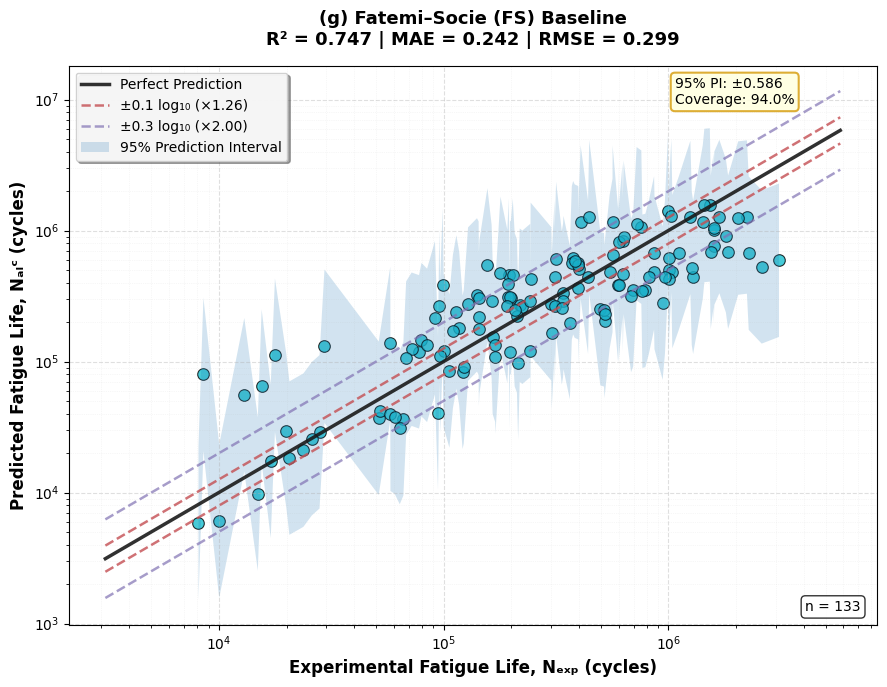

In [35]:
# ============================================================
# FS (Fatemi–Socie) baseline + UQ + PLOTS + HIGH-RES SAVE (+ download if Colab)
# Saves BOTH figures at the end (FS single plot + Combined plot) with journal-ready resolution.
# Target folder (Windows): C:\Users\SURFACE\Desktop\PhD project\3eme anne Doctorant\Article#3\Figures
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

# -----------------------------
# 0) Output folder + journal-style saving defaults
# -----------------------------
# Requested Windows path (use raw string!)
WIN_OUT_DIR = Path(r"C:\Users\SURFACE\Desktop\PhD project\3eme anne Doctorant\Article#3\Figures")

# Safe fallback if running somewhere that can't access that path (e.g., Colab/Linux)
FALLBACK_OUT_DIR = Path("./Figures")

def get_output_dir(preferred: Path, fallback: Path) -> Path:
    try:
        preferred.mkdir(parents=True, exist_ok=True)
        test_file = preferred / "__write_test__.tmp"
        test_file.write_text("ok", encoding="utf-8")
        test_file.unlink()
        return preferred
    except Exception:
        fallback.mkdir(parents=True, exist_ok=True)
        return fallback

OUT_DIR = get_output_dir(WIN_OUT_DIR, FALLBACK_OUT_DIR)
print(f"[INFO] Figures will be saved to: {OUT_DIR.resolve()}")

# Better font embedding for PDF (Elsevier-friendly)
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"]  = 42

# High resolution settings (safe for Elsevier/Results in Engineering)
DPI_TIFF = 600   # strong "high-res" for combo figures (often >=500 dpi recommended)
DPI_PNG  = 600

def save_figure(fig, stem: str):
    """
    Save as (1) TIFF (LZW) high-res and (2) PDF vector.
    Returns saved file paths.
    """
    tiff_path = OUT_DIR / f"{stem}.tif"
    pdf_path  = OUT_DIR / f"{stem}.pdf"
    png_path  = OUT_DIR / f"{stem}.png"

    # TIFF (raster) – high-res + compression
    fig.savefig(
        tiff_path,
        dpi=DPI_TIFF,
        bbox_inches="tight",
        format="tiff",
        pil_kwargs={"compression": "tiff_lzw"}
    )

    # PNG (raster) – sometimes handy for quick checks
    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight",
        format="png"
    )

    # PDF (vector) – best for line art + text
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        format="pdf"
    )

    return tiff_path, png_path, pdf_path

# -----------------------------
# 1) FS parameter (stress-based, elastic approx)
# -----------------------------
def fs_parameter_from_axial_torsion(
    Sa, Ta, Sm, Tm,
    E=210000.0, nu=0.30,         # MPa (E=210 GPa), Poisson
    sigma_y=355.0,               # MPa (S355 nominal yield; adjust if needed)
    k=0.5,                       # FS material parameter (tunable)
    n_planes=361,
    open_only=True
):
    """
    FS parameter using critical-plane scan in x–y plane for tensor:
      sigma = [[sigma_x, tau_xy, 0],
               [tau_xy,     0,  0],
               [   0,       0,  0]]

    Assumes proportional peak: sigma_x_max = Sm+Sa, tau_max = Tm+Ta.
    Uses elastic approx: (Δγ/2) ≈ τ_a / G.
    """

    Sa = np.asarray(Sa, dtype=float)
    Ta = np.asarray(Ta, dtype=float)
    Sm = np.asarray(Sm, dtype=float)
    Tm = np.asarray(Tm, dtype=float)

    G = E / (2.0 * (1.0 + nu))   # MPa

    theta = np.linspace(0.0, np.pi, int(n_planes), endpoint=True)
    c = np.cos(theta)[None, :]
    s = np.sin(theta)[None, :]
    sin2 = np.sin(2.0 * theta)[None, :]
    c2 = c**2

    def sigma_n(sigma_x, tau_xy):
        return sigma_x * c2 + tau_xy * sin2

    def tau_plane_amp(sigma_x_amp, tau_xy_amp):
        tx = sigma_x_amp * c + tau_xy_amp * s
        ty = tau_xy_amp * c
        t2 = tx**2 + ty**2
        sn = sigma_n(sigma_x_amp, tau_xy_amp)
        return np.sqrt(np.maximum(t2 - sn**2, 0.0))

    # Shear traction amplitude on each plane
    tau_a = tau_plane_amp(Sa[:, None], Ta[:, None])  # (n, n_planes)

    # Max normal stress on each plane at peak (proportional assumption)
    sigma_x_max = (Sm + Sa)[:, None]
    tau_xy_max  = (Tm + Ta)[:, None]
    sigma_n_max = sigma_n(sigma_x_max, tau_xy_max)

    if open_only:
        sigma_n_max = np.maximum(sigma_n_max, 0.0)

    gamma_a = tau_a / G  # Δγ/2 (elastic approx)

    P = gamma_a * (1.0 + k * (sigma_n_max / sigma_y))
    P_fs = np.max(P, axis=1)

    return np.maximum(P_fs, 1e-12)

# Pull stress components from df
Sa = df["Sa"].values
Ta = df["Ta"].values
Sm = df["Sm"].values
Tm = df["Tm"].values

# FS parameters (you can tune later)
k_fs = 0.5
sigma_y_fs = 355.0

P_fs = fs_parameter_from_axial_torsion(Sa, Ta, Sm, Tm, sigma_y=sigma_y_fs, k=k_fs)

# -----------------------------
# 2) Fit Basquin-like mapping: log10(N) = a + b*log10(P_fs)
# -----------------------------
x_fs = np.log10(P_fs).reshape(-1, 1)
fs_reg = LinearRegression().fit(x_fs, y_all)
fs_pred = fs_reg.predict(x_fs)

print(f"FS fit: log10(N) = {fs_reg.intercept_:.4f} + {fs_reg.coef_[0]:.4f}*log10(P_FS)")

# -----------------------------
# 3) Metrics + UQ (uses your existing helper functions)
# -----------------------------
met_fs = get_metrics(y_all, fs_pred)
pi_fs, cov_fs, _ = calculate_prediction_intervals(y_all, fs_pred)

print(f"FS — R²={met_fs[0]:.3f}, MAE={met_fs[1]:.3f}, RMSE={met_fs[2]:.3f}, 95% PI=±{pi_fs:.3f}, Coverage={cov_fs:.1%}")

# -----------------------------
# 4) Create FS single-model plot as a FIGURE OBJECT (so we can save it)
#     (Same visual logic as your plot_model)
# -----------------------------
N_true = 10**y_all
N_fs   = 10**fs_pred

fig_fs, ax_fs = plt.subplots(figsize=(9, 7))

# Scatter
ax_fs.scatter(
    N_true, N_fs,
    c="tab:cyan", alpha=0.8,
    edgecolors="black", linewidth=0.8, s=70
)

# Dynamic limits
all_vals = np.concatenate([N_true, N_fs])
min_val, max_val = np.min(all_vals), np.max(all_vals)
margin = 0.1
log_min, log_max = np.log10(min_val), np.log10(max_val)
log_range = log_max - log_min
lims = [10**(log_min - margin*log_range), 10**(log_max + margin*log_range)]

# 1:1 and bands
ax_fs.plot(lims, lims, "k-", lw=2.5, alpha=0.9, label="Perfect Prediction")
f01, f03 = 10**0.1, 10**0.3
ax_fs.plot(lims, [x*f01 for x in lims], "r--", lw=1.8, alpha=0.8, label="±0.1 log₁₀ (×1.26)")
ax_fs.plot(lims, [x/f01 for x in lims], "r--", lw=1.8, alpha=0.8)
ax_fs.plot(lims, [x*f03 for x in lims], "m--", lw=1.8, alpha=0.7, label="±0.3 log₁₀ (×2.00)")
ax_fs.plot(lims, [x/f03 for x in lims], "m--", lw=1.8, alpha=0.7)

# 95% PI band (log10-space PI)
pi_upper = 10**(np.log10(N_fs) + pi_fs)
pi_lower = 10**(np.log10(N_fs) - pi_fs)
sort_idx = np.argsort(N_true)
ax_fs.fill_between(
    N_true[sort_idx],
    pi_lower[sort_idx],
    pi_upper[sort_idx],
    alpha=0.2,
    label="95% Prediction Interval"
)

# Axes labels + title
ax_fs.set_xscale("log")
ax_fs.set_yscale("log")
ax_fs.set_xlabel("Experimental Fatigue Life, Nₑₓₚ (cycles)", fontsize=12, fontweight="bold")
ax_fs.set_ylabel("Predicted Fatigue Life, Nₐₗᶜ (cycles)", fontsize=12, fontweight="bold")

r2, mae, rmse = met_fs
ax_fs.set_title(
    f"(g) Fatemi–Socie (FS) Baseline\nR² = {r2:.3f} | MAE = {mae:.3f} | RMSE = {rmse:.3f}",
    fontsize=13, fontweight="bold", pad=15
)

# Grid + legend + annotation
ax_fs.grid(True, which="major", linestyle="--", alpha=0.4, linewidth=0.8)
ax_fs.grid(True, which="minor", linestyle=":", alpha=0.2, linewidth=0.5)
ax_fs.legend(loc="upper left", framealpha=0.9, fancybox=True, shadow=True)

# Uses your helper
add_uncertainty_annotation(ax_fs, pi_fs, cov_fs, x_pos=0.75, y_pos=0.98)
ax_fs.text(
    0.98, 0.02, f"n = {len(N_true)}",
    transform=ax_fs.transAxes,
    fontsize=10, verticalalignment="bottom", horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Combined comparison plot including FS (figure object kept for saving)
# -----------------------------
fig_combined = None

have_others = all(v in globals() for v in ["s_pred", "g_pred", "hyb_resid", "hyb_feat", "hyb_stack"])

if have_others:
    N_sines  = 10**s_pred
    N_gpr    = 10**g_pred
    N_hresid = 10**hyb_resid
    N_hfeat  = 10**hyb_feat
    N_hstack = 10**hyb_stack

    met_sines   = get_metrics(y_all, s_pred)
    met_gpr     = get_metrics(y_all, g_pred)
    met_h_resid = get_metrics(y_all, hyb_resid)
    met_h_feat  = get_metrics(y_all, hyb_feat)
    met_h_stack = get_metrics(y_all, hyb_stack)

    pi_sines,_


In [41]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# =========================
# 0) CONFIG — UPDATE THIS
# =========================
PATH = "/content/gdrive/My Drive/steel samples/Manuscript#3/FatigueDataS355_cleaned_133.xlsx"

# REQUIRED columns (edit if your file uses different names)
COL_NEXP = "Nexp"
COL_SA   = "Sa"
COL_TA   = "Ta"
COL_SM   = "Sm"
COL_TM   = "Tm"

ALPHA_S = 0.8
TEST_SIZE = 0.20
SEED = 42

# =========================
# 1) HELPERS
# =========================
def mae_rmse(y, yhat):
    y = np.asarray(y).ravel()
    yhat = np.asarray(yhat).ravel()
    mae = float(np.mean(np.abs(y - yhat)))
    rmse = float(np.sqrt(np.mean((y - yhat)**2)))
    return mae, rmse

def interval_table(y_train, y_test, yhat_sines, yhat_gpr, yhat_hybrid):
    y_train = np.asarray(y_train).ravel()
    y_test  = np.asarray(y_test).ravel()

    # bins from TRAIN only (no leakage)
    q1, q2 = np.quantile(y_train, [1/3, 2/3])
    edges  = [-np.inf, q1, q2, np.inf]
    labels = ["Low life", "Mid life", "High life"]

    df = pd.DataFrame({
        "y_test": y_test,
        "Sines": yhat_sines,
        "GPR": yhat_gpr,
        "Hybrid-Residual": yhat_hybrid
    })
    df["interval"] = pd.cut(df["y_test"], bins=edges, labels=labels, include_lowest=True)

    rows = []
    for lab in labels:
        sub = df[df["interval"] == lab]
        n = int(len(sub))
        if n == 0:
            rows.append([lab, 0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])
            continue

        s_mae, s_rmse = mae_rmse(sub["y_test"], sub["Sines"])
        g_mae, g_rmse = mae_rmse(sub["y_test"], sub["GPR"])
        h_mae, h_rmse = mae_rmse(sub["y_test"], sub["Hybrid-Residual"])

        rows.append([lab, n, s_mae, s_rmse, g_mae, g_rmse, h_mae, h_rmse])

    out = pd.DataFrame(rows, columns=[
        "Life interval (by log10(Nexp))", "n (test)",
        "Sines MAE", "Sines RMSE",
        "GPR MAE", "GPR RMSE",
        "Hybrid-Residual MAE", "Hybrid-Residual RMSE"
    ])
    return out, (float(q1), float(q2))

# =========================
# 2) LOAD DATA
# =========================
df = pd.read_excel(PATH)

needed = [COL_NEXP, COL_SA, COL_TA, COL_SM, COL_TM]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in file: {missing}\nAvailable: {list(df.columns)}")

# Target in log10 space
y = np.log10(df[COL_NEXP].astype(float).values)

# Sines descriptor Phi_Sines (proportional axial-torsion)
Sa = df[COL_SA].astype(float).values
Ta = df[COL_TA].astype(float).values
Sm = df[COL_SM].astype(float).values

J2_amp = np.sqrt((Sa**2)/3.0 + (Ta**2))
sigma_Hm = Sm/3.0
phi_sines = J2_amp + ALPHA_S * sigma_Hm

# Inputs for GPR baseline (use stress descriptors as in your paper)
X = df[[COL_SM, COL_TM, COL_SA, COL_TA]].astype(float).values

# =========================
# 3) TRAIN/TEST SPLIT
# =========================
X_train, X_test, y_train, y_test, phi_train, phi_test = train_test_split(
    X, y, phi_sines, test_size=TEST_SIZE, random_state=SEED
)

# =========================
# 4) SINES–BASQUIN (OLS): y = A + B*log10(phi)
# =========================
x_sines_train = np.log10(np.maximum(phi_train, 1e-12))
x_sines_test  = np.log10(np.maximum(phi_test,  1e-12))

X_ols_train = sm.add_constant(x_sines_train)  # [1, log10(phi)]
ols = sm.OLS(y_train, X_ols_train).fit()

A = float(ols.params[0])
B = float(ols.params[1])

yhat_sines = A + B * x_sines_test  # predictions on TEST (log10 space)

# =========================
# 5) BASELINE GPR: y ~ X
# =========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-3, 1e3)) \
         + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))

gpr = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=SEED))
])

gpr.fit(X_train, y_train)
yhat_gpr = gpr.predict(X_test)

# =========================
# 6) HYBRID-RESIDUAL: r = y - y_sines, then y_hat = y_sines + r_hat
# =========================
r_train = y_train - (A + B * x_sines_train)

gpr_res = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=10, random_state=SEED))
])

gpr_res.fit(X_train, r_train)
rhat_test = gpr_res.predict(X_test)

yhat_hybrid_res = yhat_sines + rhat_test

# =========================
# 7) PRINT INTERVAL-WISE TABLE
# =========================
table, (q1, q2) = interval_table(y_train, y_test, yhat_sines, yhat_gpr, yhat_hybrid_res)

print("\nInterval-wise performance (TEST set; log10-space):")
print(table.to_string(index=False))
print(f"\nLife-bin cutoffs (from TRAIN tertiles): q1={q1:.3f}, q2={q2:.3f}")

# Optional: also print global metrics on test
for name, pred in [("Sines", yhat_sines), ("GPR", yhat_gpr), ("Hybrid-Residual", yhat_hybrid_res)]:
    mae, rmse = mae_rmse(y_test, pred)
    print(f"{name:16s}  MAE={mae:.3f}  RMSE={rmse:.3f}")






Interval-wise performance (TEST set; log10-space):
Life interval (by log10(Nexp))  n (test)  Sines MAE  Sines RMSE  GPR MAE  GPR RMSE  Hybrid-Residual MAE  Hybrid-Residual RMSE
                      Low life        14   0.337259    0.380147 0.163344  0.180820             0.174592              0.196791
                      Mid life         4   0.202905    0.212007 0.132483  0.161478             0.143560              0.176700
                     High life         9   0.156365    0.229891 0.155653  0.213371             0.178715              0.227574

Life-bin cutoffs (from TRAIN tertiles): q1=5.283, q2=5.739
Sines             MAE=0.257  RMSE=0.315
GPR               MAE=0.156  RMSE=0.190
Hybrid-Residual   MAE=0.171  RMSE=0.205


In [42]:
table, (q1, q2) = interval_table(y_train, y_test, yhat_sines, yhat_gpr, yhat_hybrid_res)
print(table.to_string(index=False))
print(f"Life-bin cutoffs (from TRAIN tertiles): q1={q1:.3f}, q2={q2:.3f}")


Life interval (by log10(Nexp))  n (test)  Sines MAE  Sines RMSE  GPR MAE  GPR RMSE  Hybrid-Residual MAE  Hybrid-Residual RMSE
                      Low life        14   0.337259    0.380147 0.163344  0.180820             0.174592              0.196791
                      Mid life         4   0.202905    0.212007 0.132483  0.161478             0.143560              0.176700
                     High life         9   0.156365    0.229891 0.155653  0.213371             0.178715              0.227574
Life-bin cutoffs (from TRAIN tertiles): q1=5.283, q2=5.739
